# Introdução Às Redes Neurais 

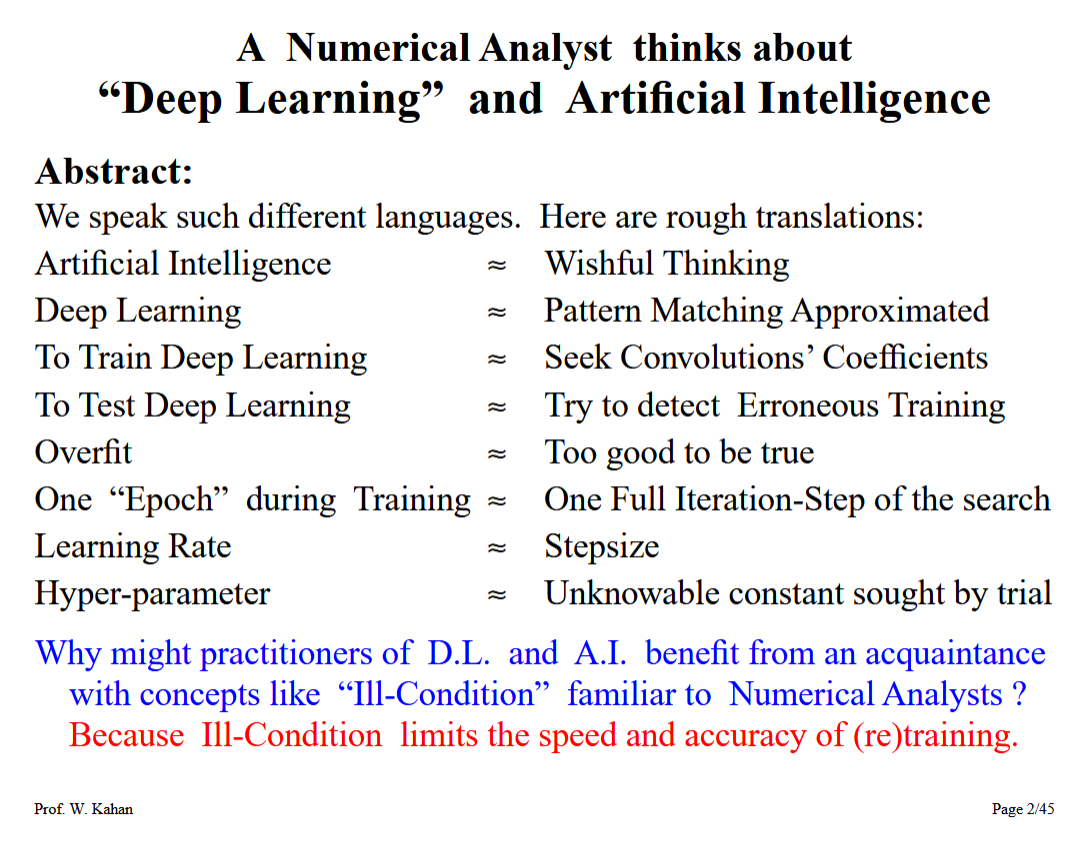

Fonte: Página inicial de "A Numerical Analyst thinks about “Deep Learning” and Artificial Intelligence", prof. W. Kahan, University of California @ Berkeley, 2018.


# Aula Introdutória - Artigo: Perceptrons: The First Neural Network

In [1]:
%%HTML
<a href="https://medium.com/data-science/perceptrons-the-first-neural-network-model-8b3ee4513757">Perceptrons: The First Neural Network Model</a>

### Rede Neural Multicamadas com Retropropagação





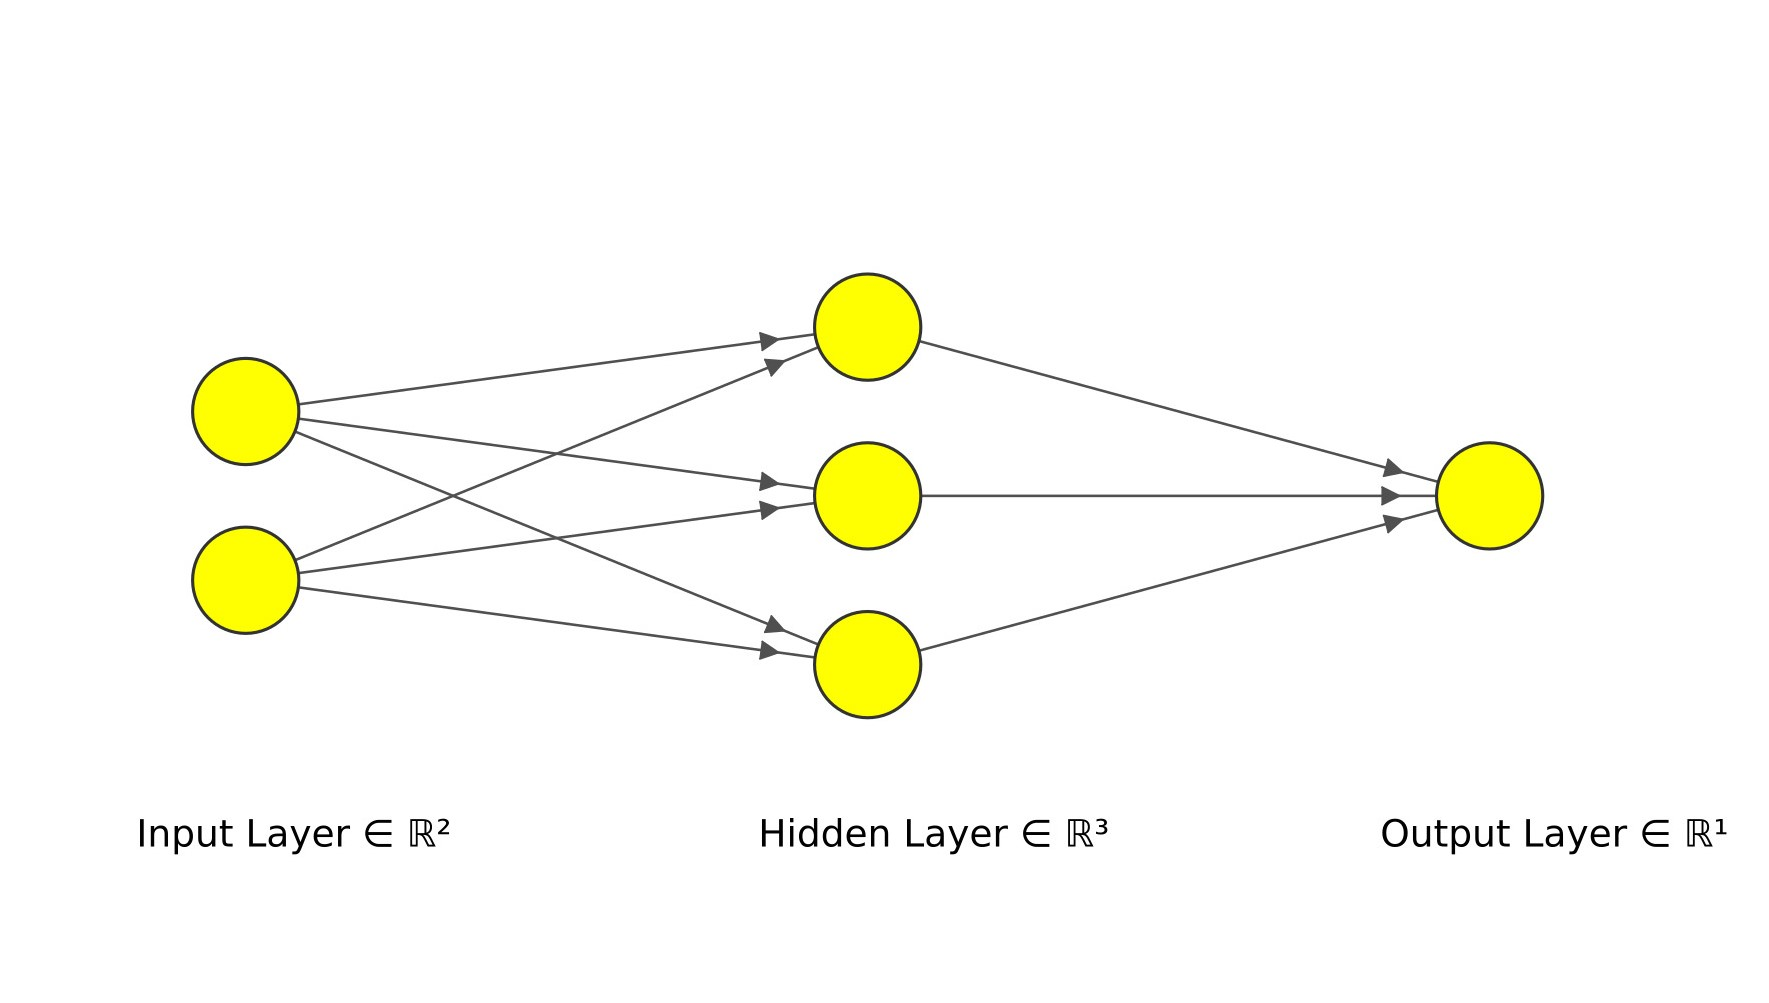

y_preds= [1. 1. 1. 1.]
Epoch 0 loss: 0.252
y_preds= [1. 1. 1. 1.]
Epoch 10 loss: 0.251
y_preds= [1. 1. 1. 1.]
Epoch 20 loss: 0.251
y_preds= [1. 1. 1. 1.]
Epoch 30 loss: 0.250
y_preds= [1. 0. 1. 1.]
Epoch 40 loss: 0.250
y_preds= [1. 0. 1. 1.]
Epoch 50 loss: 0.250
y_preds= [1. 0. 1. 1.]
Epoch 60 loss: 0.249
y_preds= [1. 0. 1. 1.]
Epoch 70 loss: 0.249
y_preds= [1. 0. 1. 1.]
Epoch 80 loss: 0.249
y_preds= [1. 0. 1. 1.]
Epoch 90 loss: 0.248
y_preds= [1. 0. 1. 1.]
Epoch 100 loss: 0.248
y_preds= [1. 0. 1. 1.]
Epoch 110 loss: 0.248
y_preds= [1. 0. 1. 1.]
Epoch 120 loss: 0.247
y_preds= [1. 0. 1. 1.]
Epoch 130 loss: 0.247
y_preds= [1. 0. 1. 1.]
Epoch 140 loss: 0.247
y_preds= [0. 0. 1. 1.]
Epoch 150 loss: 0.246
y_preds= [0. 0. 1. 0.]
Epoch 160 loss: 0.246
y_preds= [0. 0. 1. 0.]
Epoch 170 loss: 0.246
y_preds= [0. 0. 1. 0.]
Epoch 180 loss: 0.245
y_preds= [0. 0. 1. 0.]
Epoch 190 loss: 0.245
y_preds= [0. 0. 1. 0.]
Epoch 200 loss: 0.245
y_preds= [0. 0. 1. 0.]
Epoch 210 loss: 0.244
y_preds= [0. 0. 1. 0.

Text(0, 0.5, 'Loss')

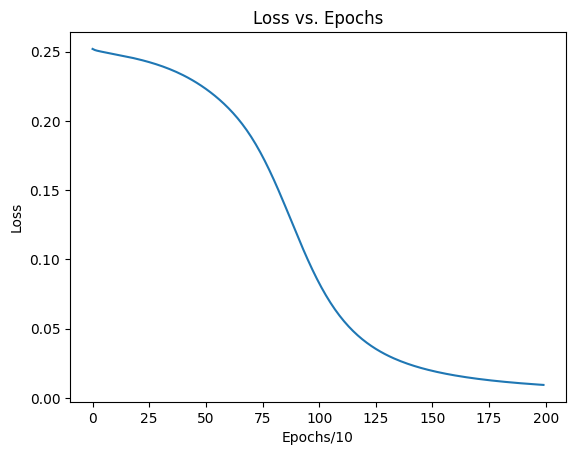

In [2]:
import numpy as np

def activation_function(x):
 # return np.heaviside(x, 1)
 return 1 / (1 + np.exp(-x))



def deriv_activ_function(x):
  fx = activation_function(x)
  return fx * (1 - fx)

def mse_loss(y_true, y_pred):
  return ((y_true - y_pred) ** 2).mean()

class NeuralNetwork:
  
  def __init__(self):
    # Weights
    self.w1 = np.random.normal()
    self.w2 = np.random.normal()
    self.w3 = np.random.normal()
    self.w4 = np.random.normal()
    self.w5 = np.random.normal()
    self.w6 = np.random.normal()   
    self.w7 = np.random.normal()
    self.w8 = np.random.normal()
    self.w9 = np.random.normal()

    # Biases
    self.b1 = np.random.normal()
    self.b2 = np.random.normal()
    self.b3 = np.random.normal()
    self.b4 = np.random.normal()

  def feedforward(self, x):

    h1 = activation_function(self.w1 * x[0] + self.w2 * x[1] + self.b1)
    h2 = activation_function(self.w3 * x[0] + self.w4 * x[1] + self.b2)
    h3 = activation_function(self.w5 * x[0] + self.w6 * x[1] + self.b3)
    o1 = activation_function(self.w7 * h1 + self.w8 * h2 + self.w9*h3+self.b4)
    return o1

  def train(self, data, y_trues,loss):
    
    alpha = 0.1
    epochs = 2000 # number of times to loop through the entire dataset
    iloss=0

    for epoch in range(epochs):
      for x, y_true in zip(data, y_trues):
        # Feedforward 
        sum_h1 = self.w1 * x[0] + self.w2 * x[1] + self.b1
        h1 = activation_function(sum_h1)

        sum_h2 = self.w3 * x[0] + self.w4 * x[1] + self.b2
        h2 = activation_function(sum_h2)

        sum_h3 = self.w5 * x[0] + self.w6 * x[1] + self.b3
        h3 = activation_function(sum_h3)

        sum_o1 = self.w7 * h1 + self.w8 * h2 + self.w9*h3 + self.b4
        o1 = activation_function(sum_o1)
        y_pred = o1

        # --- Calculate partial derivatives.
        d_L_d_ypred = -2 * (y_true - y_pred)

        # Neuron o1
        d_ypred_d_w7 = h1 * deriv_activ_function(sum_o1)
        d_ypred_d_w8 = h2 * deriv_activ_function(sum_o1)
        d_ypred_d_w9 = h3 * deriv_activ_function(sum_o1)
        d_ypred_d_b4 = deriv_activ_function(sum_o1)

        d_ypred_d_h1 = self.w7 * deriv_activ_function(sum_o1)
        d_ypred_d_h2 = self.w8 * deriv_activ_function(sum_o1)
        d_ypred_d_h3 = self.w9 * deriv_activ_function(sum_o1)

        # Neuron h1
        d_h1_d_w1 = x[0] * deriv_activ_function(sum_h1)
        d_h1_d_w2 = x[1] * deriv_activ_function(sum_h1)
        d_h1_d_b1 = deriv_activ_function(sum_h1)

        # Neuron h2
        d_h2_d_w3 = x[0] * deriv_activ_function(sum_h2)
        d_h2_d_w4 = x[1] * deriv_activ_function(sum_h2)
        d_h2_d_b2 = deriv_activ_function(sum_h2)

        # Neuron h3
        d_h3_d_w5 = x[0] * deriv_activ_function(sum_h3)
        d_h3_d_w6 = x[1] * deriv_activ_function(sum_h3)
        d_h3_d_b3 = deriv_activ_function(sum_h3)

        # --- Update weights and biases
        # Neuron h1
        self.w1 -= alpha * d_L_d_ypred * d_ypred_d_h1 * d_h1_d_w1
        self.w2 -= alpha * d_L_d_ypred * d_ypred_d_h1 * d_h1_d_w2
        self.b1 -= alpha * d_L_d_ypred * d_ypred_d_h1 * d_h1_d_b1

        # Neuron h2
        self.w3 -= alpha * d_L_d_ypred * d_ypred_d_h2 * d_h2_d_w3
        self.w4 -= alpha * d_L_d_ypred * d_ypred_d_h2 * d_h2_d_w4
        self.b2 -= alpha * d_L_d_ypred * d_ypred_d_h2 * d_h2_d_b2

        # Neuron h3
        self.w5 -= alpha * d_L_d_ypred * d_ypred_d_h3 * d_h3_d_w5
        self.w6 -= alpha * d_L_d_ypred * d_ypred_d_h3 * d_h3_d_w6
        self.b3 -= alpha * d_L_d_ypred * d_ypred_d_h3 * d_h3_d_b3

        # Neuron o1
        self.w7 -= alpha * d_L_d_ypred * d_ypred_d_w7
        self.w8 -= alpha * d_L_d_ypred * d_ypred_d_w8
        self.w9 -= alpha * d_L_d_ypred * d_ypred_d_w9
        self.b4 -= alpha * d_L_d_ypred * d_ypred_d_b4

      # --- Calculate total loss at the end of each epoch
      if epoch % 10 == 0:
        y_preds = np.apply_along_axis(self.feedforward, 1, data)
        print('y_preds=',np.round(y_preds))
        loss[iloss] = mse_loss(y_trues, y_preds)
        
        print("Epoch %d loss: %.3f" % (epoch, loss[iloss]))
        iloss=iloss+1
        
        

# Data
data = np.array([
  [0, 0], 
  [0,1],  
  [1,0],   
  [1,1], 
])
y_trues = np.array([
  0, 
  1, 
  1,
  0, 
])

# Train the NNetwork

loss=np.zeros(200)
network = NeuralNetwork()
network.train(data, y_trues,loss)
iep=np.arange(200)
import matplotlib.pyplot as plt
plt.title('Loss vs. Epochs')
plt.plot(iep,loss)
plt.xlabel('Epochs/10')
plt.ylabel('Loss')


Referências até aqui:

[1] Michael Collins, Convergence Proof for the Perceptron Algorithm

[2] https://www.geeksforgeeks.org/perceptron-convergence-theorem-in-neural-networks/

[3]Rumelhart, D., Hinton, G. & Williams, R. Learning representations by back-propagating errors. Nature 323, 533–536 (1986). https://doi.org/10.1038/323533a0


# Vetorização

Referências:

[1]  Dr. Andy Thomas  Neural Networks Tutorial – A Pathway to Deep Learning :
http://deeplearning.lipingyang.org/wp-content/uploads/2016/12/Neural-Networks-Tutorial-A-Pathway-to-Deep-Learning-Adventures-in-Machine-Learning.pdf

[2] https://victorzhou.com/blog/intro-to-rnns/#73-gradients

[3] Terence Parr and Jeremy Howard, The Matrix Calculus You Need For Deep Learning, arXiv, 2018.


Os dados de entrada devem ter o formato de matrizes $X[n_i,n_a]$
    e $y[n_o,n_a]$, onde $n_i$ é o número de dados de entrada em cada amostra, $n_a$ é o número de amostras e $n_o$ é o número de neurônios na camada de saída.
    
Assim, como exemplo, uma determinada rede com conexão densa possui $n_i$=2 dados de entrada e $n_a$=4. Considere ainda uma camada oculta com dois neurônios, e um único neurônio na camada de saída, havendo portanto uma saída para cada amostra. Portanto, temos as seguintes matrizes dimensionadas a seguir: $X[2,4],\, y[1,4],\, W^h[2,2],\, W^o[1,2],\, b^h[2,1],\, e\, b^o[1,1]$.
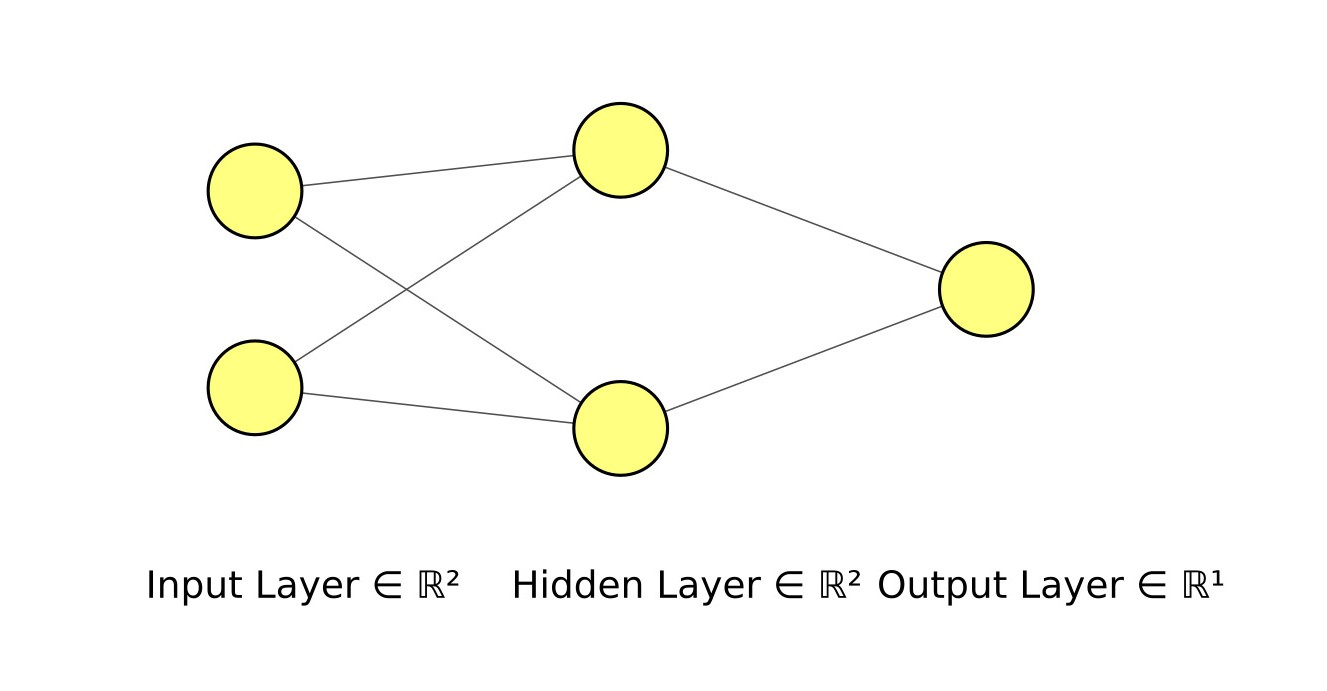

### Assim, na propagação direta (*feedforward*) podemos escrever para cada neurônio da camada intermediária,

$Z^h_{1}=W_{11}^hX_{11}+W_{12}^hX_{21}+b^h_{1}+W_{11}^hX_{12}+W_{12}^hX_{22}+b^h_{1}+ \textellipsis +W_{11}^hX_{14}+W_{12}^hX_{24}+b^h_{1}$

$Z^h_{2}=W_{21}^hX_{11}+ W_{21}X_{21}+b^h_{2}+W_{21}^hX_{12}+W_{22}^hX_{22}+b^h_{2}+ \textellipsis +W_{21}^hX_{14}+W_{22}^hX_{24}+b^h_{2}$. 

Colocando as duas equações em uma única equação matricial,

$Z_{[2,4]}^h=W_{[2,2]}^hX_{[2,4]}+b_{[2,1]}^h$. Na saída da camada escondida, podemos escrever que

$H_{[2,4]}=f_a(Z^h)$, onde $H=\begin{bmatrix}
h_1 \\
h_2
\end{bmatrix}=\begin{bmatrix}
f_a(Z^h_{1}) \\
f_a(Z^h_{2})
\end{bmatrix}$, e $h_1$ e $h_2$ tem dimensões [1,4]. Finalmente, para a camada de saída

$Z_{[1,4]}^o=\begin{bmatrix} W_{11}^o & W_{12}^o \end{bmatrix}\begin{bmatrix}
h_1 \\
h_2
\end{bmatrix}+\begin{bmatrix}
b_o \end{bmatrix}=W_{[1,2]}^oH_{[2,4]}+b_{[1,1]}^o$ e $ y_p=f_a(Z^o)$ com dimensões [1,4].

### Retropropagação (*backpropagation*)

na camada de saída partimos do *array* $\frac{\partial{L}}{\partial{Y_p}}$,

$\frac{\partial{L}}{\partial{Y_p}}_{[1,4]}=\begin{bmatrix} \frac{\partial{L}}{\partial{Y_{p1}}} & \frac{\partial{L}}{\partial{Y_{p2}}} & \frac{\partial{L}}{\partial{Y_{p3}}} & \frac{\partial{L}}{\partial{Y_{p4}}}\end{bmatrix},$

$\frac{\partial{L}}{\partial{W_{11}^o}}=\underbrace{\frac{\partial{L}}{\partial{Y_p}}\frac{\partial{y_p}}{\partial{Z^o}}}_{\frac{\partial{L}}{\partial{Z^o}}}\frac{\partial{Z^o}}{\partial{W_{11}^o}}=\frac{\partial{L}}{\partial{Y_p}}f_a'(Z^o)\frac{\partial(W_{11}^o h_1+W_{12}^o h_2)}{\partial{W_{11}^o}}=\frac{\partial{L}}{\partial{Y_p}}f_a'(Z^o)h_1$

$\frac{\partial{L}}{\partial{W_{12}^o}}=\frac{\partial{L}}{\partial{Y_p}}f_a'(Z^o)h_2$

e

$\left[\frac{\partial{L}}{\partial{W^o}}\right]_{[1,2]}=\left[ \frac{\partial{L}}{\partial{Y_p}}f_a'(Z^o)\right]_{[1,4]}\left[H\right]_{[4,2]}^T$. Note que o produto $\frac{\partial{L}}{\partial{Y_p}}f_a'(Z^o)$ é executado termo a termo sobre as duas matrizes de dimensão [1,4].

Para a camada escondida podemos escrever

$\left[\frac{\partial{L}}{\partial{Z^h}}\right ]_{[2,4]}=\underbrace{\left(\begin{bmatrix} W_{11}^o \\ W_{12}^o\end{bmatrix}_{[2,1]}\begin{bmatrix} \frac{\partial{L}}{\partial{Z_1^o}} & \frac{\partial{L}}{\partial{Z_2^o}}&\frac{\partial{L}}{\partial{Z_3^o}}&\frac{\partial{L}}{\partial{Z_4^o}}\end{bmatrix}_{[1,4]}\right)}_{\frac{\partial L}{\partial H}}*\underbrace{\left[ f_a'(Z^h)\right]_{[2,4]}}_{\frac{\partial H}{\partial Z^h}}$, onde o último produto de matrizes de dimensões  [2,4] também é executado termo a termo. 

Finalmente, 

$\left[ \frac{\partial{L}}{\partial{W^h}} \right]_{[2,2]}=\frac{\partial{L}}{\partial{Z^h}}X^T=\left[\frac{\partial{L}}{\partial{Z^h}}\right ]_{[2,4]}\begin{bmatrix} X_{11}&X_{21}\\ X_{12}&X_{22}\\ X_{13}&X_{23}\\ X_{14}&X_{24}\end{bmatrix}_{[4,2]}$


In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
class NeuralNetwork:
    
    """ Os dados de entrada devem ter o formato de matrizes x[n_input,n_amostras]
    e y[n_output,n_amostras]"""
    
    def __init__(self,hidden_activation, output_activation,loss,
                 n_input, n_hidden, n_output):
        # Armazena o número de neurônios em cada camada
        self.n_input = n_input
        self.n_hidden = n_hidden
        self.n_output = n_output
        
        # Armazena as funções de ativação para cada camada e a função custo
        self.hidden_activation = hidden_activation
        self.output_activation = output_activation
        self.loss=loss
        
        # Inicializa as matrizes de pesos
        np.random.seed(42)
        self.w_h=np.random.randn(n_hidden, n_input) * 0.01
        self.w_o=np.random.randn(n_output, n_hidden) * 0.01
        self.bias_h=np.zeros((n_hidden, 1))
        self.bias_o=np.zeros((n_output, 1))
        
        # Evolução da função custo
        self.loss_history=[]
   
    def activation_function(self,f_activ,x):
        if f_activ=='linear':
            return 1.*x
        if f_activ=='sigmoid':
            return 1 / (1 + np.exp(-x))        
        if f_activ == 'tanh':
            return np.tanh(x)
        if f_activ == 'relu':
            return np.maximum(0,x)         
    
    def deriv_activ_function(self,f_activ,x):
        if f_activ=='linear':
            return 1.
        if f_activ=='sigmoid':
            fx = self.activation_function(f_activ,x)
            return fx * (1 - fx)
        if f_activ == 'tanh':
            fx = self.activation_function(f_activ,x)
            return 1-fx**2
        if f_activ == 'relu':
            return (x>0).astype(np.float64)
    
    def compute_loss(self,y, y_p):

        if self.loss=='logloss':
            #Atenção: Se houver um termo nulo em y_p o cálculo resultará inf.
            eps=1e-15
            y_p=np.clip(y_p,eps,1-eps)
            cost = -(y * np.log(y_p) + (1 - y) * np.log(1 - y_p)).mean()
        if self.loss=='mse':
            cost=((y-y_p)**2).mean()
        return np.squeeze(cost)
    
    def deriv_loss(self,y,y_p):
        m=len(y[0,:])
        if self.loss=='logloss':
            #Atenção: Se houver um termo nulo ou 1 em y_p o cálculo resultará inf.
            eps=1e-15
            y_p=np.clip(y_p,eps,1-eps)
            return (y_p-y)/(y_p*(1-y_p))/m
        if self.loss=='mse':
            return -2*(y-y_p)/m 
    
    def forward_propagation(self,x):
        
        z_h = np.dot(self.w_h, x) + self.bias_h
        output_h = self.activation_function(self.hidden_activation,z_h)
        z_o = np.dot(self.w_o, output_h) + self.bias_o
        y_p = self.activation_function(self.output_activation,z_o)
        
        return z_h,z_o,output_h,y_p
    
    def backward_propagation(self,x, y,z_h, z_o, output_h, y_p):
        
        # Camada de saída
        # ================
        #d_L/d_y_p
        d_y_p=self.deriv_loss(y,y_p)
        #d_L/d_z_o
        dz_o =d_y_p*self.deriv_activ_function(self.output_activation,z_o)
        #d_L/d_w_o
        dw_o = np.dot(dz_o, output_h.T)
        #d_L/d_bias_o
        db_o = np.sum(dz_o, axis=1, keepdims=True)
        
        # Camada interna (hidden)
        # =======================       
        #d_L/d_z_h
        dz_h = np.dot(self.w_o.T, dz_o) * self.deriv_activ_function(self.hidden_activation,z_h)
        #d_L/d_w_h
        dw_h = np.dot(dz_h, x.T)
        #d_L/d_bias_h
        db_h = np.sum(dz_h, axis=1, keepdims=True)
        
        return dw_h,dw_o,db_h,db_o
    
    def train(self,x, y, epochs=1000, learning_rate=0.1,verbose=False):
        
        for i in range(epochs):
            
            # Forward propagation e Custo.
            z_h,z_o,output_h,y_p = self.forward_propagation(x)
            cost = self.compute_loss(y, y_p)
            
            # Recupera o vetor gradiente=[dw_o,db_o,dw_h,db_h]
            dw_h,dw_o,db_h,db_o = self.backward_propagation(x, y,z_h,z_o, output_h, y_p)
            
            # Atualiza os parâmetros com os gradientes computados (DG)           
            self.w_h-=learning_rate*dw_h        
            self.w_o-=learning_rate*dw_o
            self.bias_h-=learning_rate*db_h
            self.bias_o-=learning_rate*db_o

            if i % 10 == 0:
                if verbose:
                    print(f"Epoch {i}: Cost = {cost}")
                self.loss_history.append(cost)        
    
    def predict(self,x):
        _,_,_,y_p= self.forward_propagation(x)
        return y_p

In [5]:
from sklearn.preprocessing import StandardScaler
def plot_decision_boundaries(model, X, y, title="Fronteiras de Decisão da Rede Neural"):
    """
    Plota os dados e as fronteiras de decisão criadas pelo modelo.
    
    Parâmetros:
    - model: rede neural treinada
    - X: dados de entrada
    - y: rótulos (classes) dos dados
    - title: título do gráfico
    """
    # Define os limites do gráfico com base nos dados
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Cria uma grade para visualizar as fronteiras de decisão
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Achata a grade em 2 arrays e concatena as colunas convertendo 
    # em um array onde cada item são as coordenadas 2D dos pontos.
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # Aplicaro modelo para cada ponto na grade
    Z = np.zeros(grid_points.shape[0])
    for i, point in enumerate(grid_points):       
        Z[i] = model.predict(point.reshape(2,1)).item()
    
    # Reformata Z para o formato 2D da grade
    Z = Z.reshape(xx.shape)
    
    # Plota as fronteiras de decisão e os pontos
    plt.figure(figsize=(6,6))
    levels=[-0.5,0.49,0.51,1.9]
    plt.contourf(xx, yy, Z,levels,alpha=0.3, cmap=plt.cm.RdBu)
    plt.contour(xx, yy, Z,levels,linewidths=1, colors='black')  
    
    # Plota os pontos de dados
    colors = ['red', 'blue']
    for i in np.unique(y):
        plt.scatter(X[y==i, 0], X[y==i, 1], 
                    label=f"Classe {i}", 
                    color=colors[int(i)], 
                    edgecolor='white', 
                    s=50)
    
    plt.title(title)
    plt.xlabel('Característica 1 (X)')
    plt.ylabel('Característica 2 (Y)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    



## Problema não linearmente separável

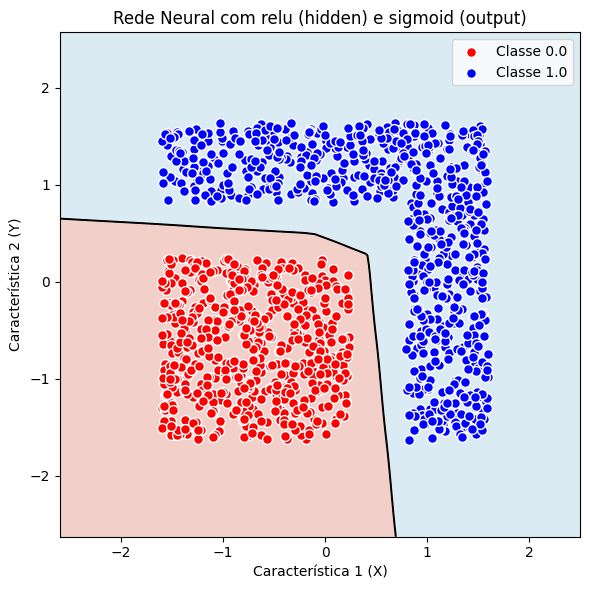

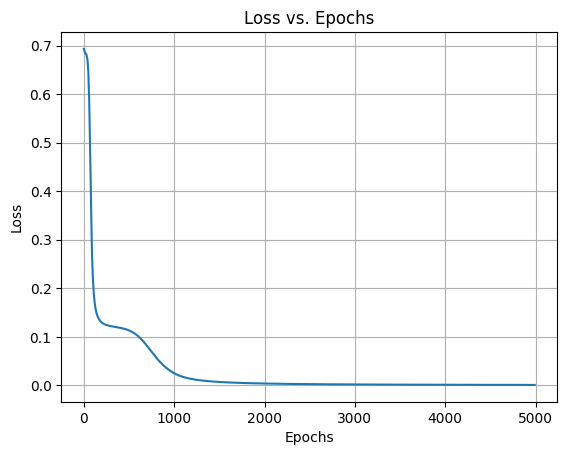

In [6]:
np.random.seed(0)
epochs=1000
n = 1550
Xt1 = np.random.uniform(low=[0, 0], high=[4, 4], size=(n,2))
drop = (Xt1[:, 0] < 3) & (Xt1[:, 1] < 3)# pontos x<3 e y < 3
Xt1 = Xt1[~drop]
yt1= np.ones(len(Xt1))# elimina os pontos selecionados

Xt2 = np.random.uniform(low=[0, 0], high=[4, 4], size=(n,2))
drop = (Xt2[:, 0] > 2.3) | (Xt2[:, 1] > 2.3)

Xt2 = Xt2[~drop]
yt2= np.zeros(len(Xt2))

X4 = np.concatenate([Xt1, Xt2])
y4 = np.concatenate([yt1, yt2])

scaler = StandardScaler()
X4 = scaler.fit_transform(X4)
m=len(X4[:,0])
x=X4.T
y=y4.reshape(1,m)
 

epochs=5000
learning_rate=0.2
n_input=x.shape[0]
n_hidden=16
n_output=1
hidden_activation='relu'
output_activation='sigmoid'
loss='logloss'

model= NeuralNetwork(hidden_activation, output_activation,loss, n_input, n_hidden, n_output)
model.train(x, y,epochs, learning_rate)
    
plot_decision_boundaries(model, X4, y4, 
    f"Rede Neural com {hidden_activation} (hidden) e {output_activation} (output)")   

plt.figure()    
epoch=np.arange(epochs/10)*10
loss_h=model.loss_history
plt.title('Loss vs. Epochs')
plt.plot(epoch,loss_h)
plt.xlabel('Epochs')
plt.grid()
plt.ylabel('Loss')  
plt.show()  

## Regressão Linear

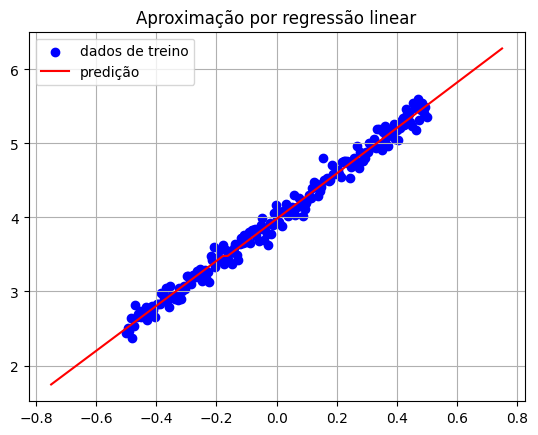

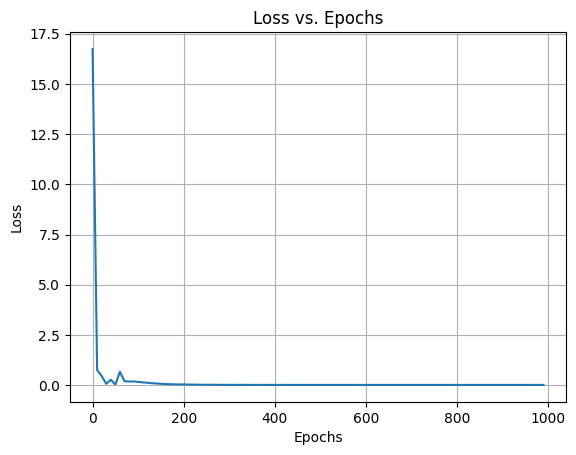

In [7]:
np.random.seed(40)
x=np.linspace(-0.5,0.5,200).reshape(1,200)
y = 4 + 3 * x + 0.5*np.random.randn(200)/5

n_input=x.shape[0]
n_hidden=14
n_output=1
hidden_activation='relu'
output_activation='linear'
loss='mse'
epochs=1000
    
model=NeuralNetwork(hidden_activation,output_activation,loss,n_input,n_hidden,n_output)   
model.train(x,y,epochs,learning_rate=0.41)


X=np.zeros((1,1000))
X[0,:]=np.linspace(-0.75,0.75,1000)
y_p=model.predict(X)
xp=X[0,:]
yp=y_p[0,:]

plt.figure()
title='Aproximação por regressão linear'
plt.scatter(x,y,color='blue',label='dados de treino')
plt.plot(xp,yp,c='r', label='predição')
plt.legend()
plt.grid()
plt.title(title)
plt.show()

plt.figure()
epoch=np.arange(epochs/10)*10
loss_h=model.loss_history
plt.title('Loss vs. Epochs')
plt.plot(epoch,loss_h)
plt.xlabel('Epochs')
plt.grid()
plt.ylabel('Loss')
plt.show()

## Regressão Quadrática

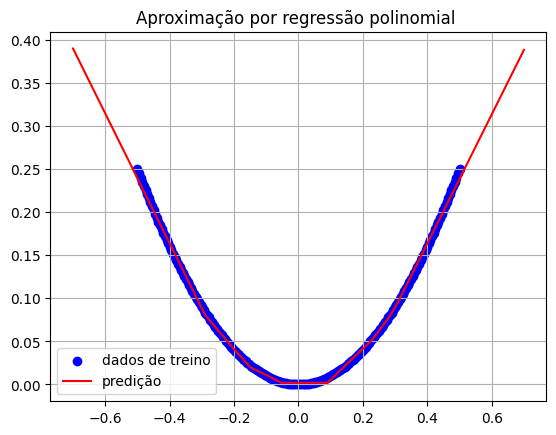

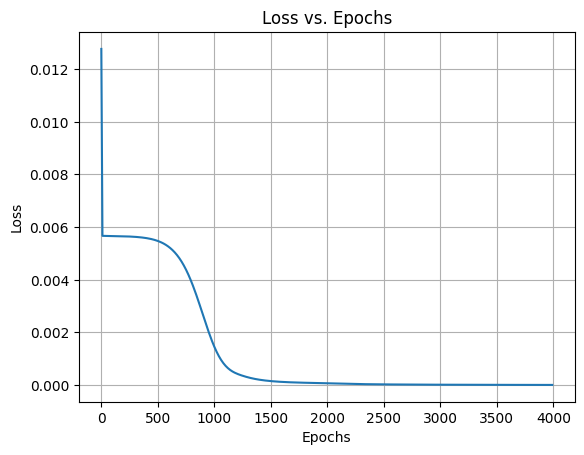

In [8]:
# dados do problema
# =====================
np.random.seed(42)
num_points = 200
x = np.linspace(-0.5,0.5, num_points).reshape(1,num_points)
y = (x)**2 

n_input=x.shape[0]
n_hidden=15
n_output=1
hidden_activation='relu'
output_activation='linear'
loss='mse'
epochs=4000

    
model=NeuralNetwork(hidden_activation,output_activation,loss,n_input,n_hidden,n_output)   
model.train(x,y,epochs,learning_rate=0.4)

x_p=np.linspace(x.min()-0.2,x.max()+0.2,1000)
y_p=model.predict(x_p.reshape(1,1000)).squeeze()

# Distribuição dos pontos & representação linear
#===============================================
fig=plt.figure()
ax = fig.add_subplot(111)
title='Aproximação por regressão polinomial '
plt.scatter(x, y, facecolors='b', edgecolors='b', label='dados de treino')
plt.plot(x_p,y_p,c='r',label='predição')
plt.grid()
plt.legend()
plt.title(title)
plt.show()

fig=plt.figure()
epoch=np.arange(epochs/10)*10
loss_h=model.loss_history
plt.title('Loss vs. Epochs')
plt.plot(epoch,loss_h)
plt.xlabel('Epochs')
plt.grid()
plt.ylabel('Loss')
plt.show()

## Classificação Binária

Laura: 1
Fernando: 0


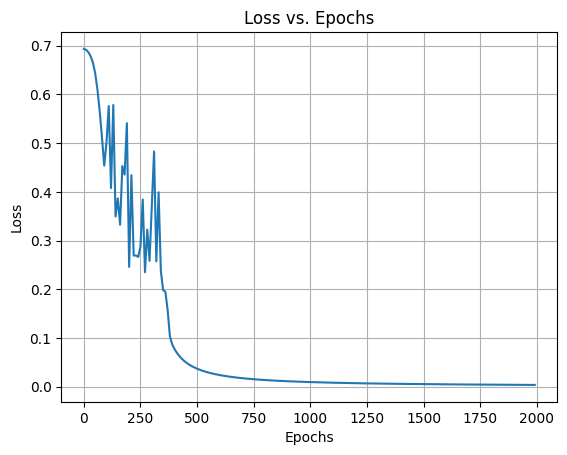

In [9]:
# Examplo:XOR logic gate, não linearmente separável
# Exemplo=1
# X = np.array([[0, 0, 1, 1], [0, 1, 0, 1]])
# Y = np.array([[0, 1, 1, 0]])

#====================================================================

# Exemplo: Pesos e alturas para caracterização de gênero em Kg e cm
Exemplo=2 
X = np.array([
  [-4, -4],  # Larissa
  [9, 14],   # Roberto
  [5, 9],    # Paulo
  [-9, -17], # Sandra
]).reshape(2,4)
Y = np.array([
  1, # Larissa
  0, # Roberto
  0, # Paulo
  1, # Sandra
]).reshape(1,4)

# ======================================================================

# Exemplo: Majority Function
# Exemplo=3
# X = np.array([[0,0,0], [0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]]).T
# Y = np.array([[0,0,0,1,0,1,1,1]])

epochs=2000
model=NeuralNetwork(hidden_activation='tanh', output_activation='sigmoid'
                       , loss='logloss', n_input=X.shape[0], n_hidden=3, n_output=1)
model.train(X, Y, epochs)

# Predictions
if Exemplo==2:
    Laura = np.array([-6, -9]).reshape(2,1) # 58 kilos, 160 cm
    Fernando = np.array([31, -4]).reshape(2,1)  # 70,3 Kilos, 173 cm
    print("Laura:",  np.round(model.predict(Laura).item()).astype(int))
    print("Fernando:",  np.round(model.predict(Fernando).item()).astype(int))
else:
    predictions = np.round(model.predict(X)).astype(int)
    print("Predictions:", predictions)


plt.figure()
epoch=np.arange(epochs/10)*10
loss_h=model.loss_history
plt.title('Loss vs. Epochs')
plt.plot(epoch,loss_h)
plt.xlabel('Epochs')
plt.grid()
plt.ylabel('Loss')
plt.show()

# Método dos Gradientes Descendentes

Referências:

[1] CS168: The Modern Algorithmic Toolbox Lecture #5: Gradient Descent Basics, Tim Roughgarden & Gregory Valiant,April 11, 2016

[2] Ruder, Sebastin, An overview of gradient descent optimization algorithms, arXiv, 2017

[3] Neural Networks for Machine Learning-Lecture 6a Overview of mini-batch gradient descent

[4] Neural Networks for Machine Learning-Lecture 6c The momentum method

[5] Neural Networks for Machine Learning-Lecture 6e rmsprop: Divide the gradient by a running average of its recent magnitude

[6] https://www.geeksforgeeks.org/deep-learning/understanding-gradient-clipping/


Considere o problema de minimização da função de perda/custo abaixo:

$$ \vec{w}=\vec{w}-\eta\vec{\nabla_w}(\vec{w})$$
onde, para um problema de regressão linear,
$$\vec{y}(\vec{w})=\vec{b_0}+\vec{w}.\vec{x}.$$

Então, 

$$J=\sum_i\frac{1}{m}(\vec{y_pî}(\vec{w})-\vec{y^i})^2\rightarrow \frac{dJ}{d\vec{w}}=\frac{2}{m}\sum_i(\vec{y_p^i}-\vec{y^i}).\frac{d\vec{y_p^i}}{d\vec{w}}=\frac{2}{m}\sum_i(\vec{y_p^i}-\vec{y^i}).\vec{x^i}$$

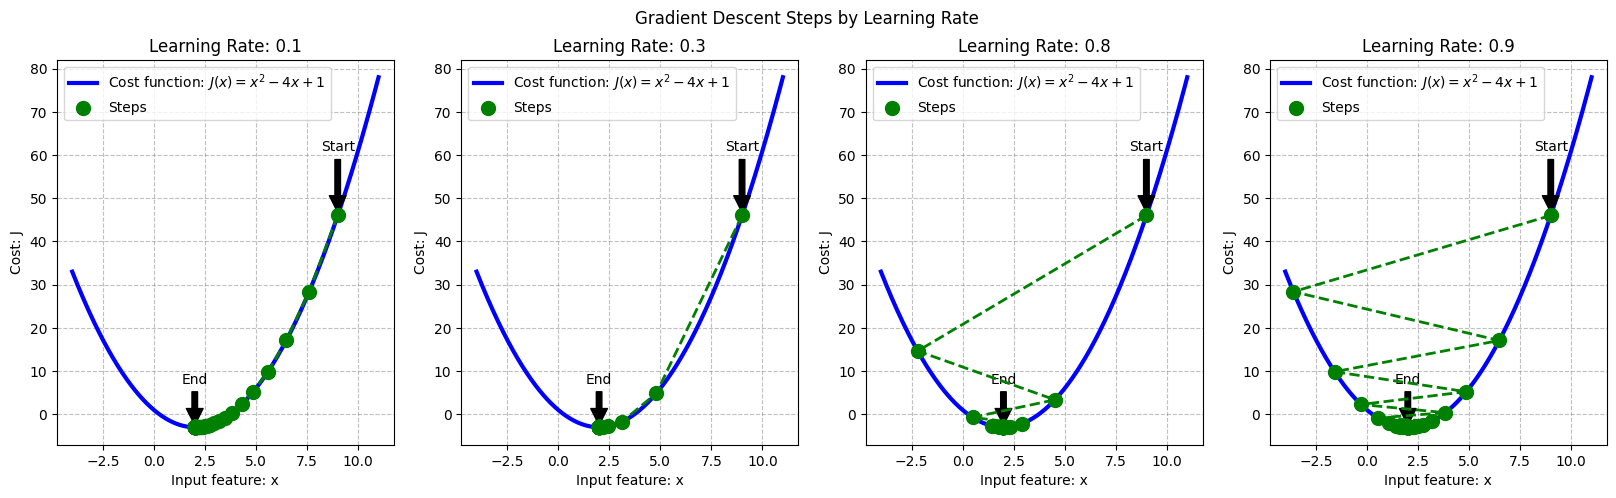

In [6]:
import numpy as np
import matplotlib.pyplot as plt




x_values = np.linspace(-4, 11, 400)
y_values = cost_func(x_values)
initial_x = 9
iterations = 100
tolerance = 1e-15
learning_rates = [0.1, 0.3, 0.8, .9]


def gradient_descent_curve(ax, learning_rate):
    final_x, history = gradient_descent(gradient, initial_x, learning_rate, iterations, tolerance)

    ax.plot(x_values, y_values, label=f'Cost function: $J(x) = x^2 - 4x + 1$', lw=3, color='blue')

    ax.scatter(history, [cost_func(x) for x in history], s=100,color='green', zorder=5, label='Steps')
    ax.plot(history, [cost_func(x) for x in history], 'g--', lw=2, zorder=5)

    ax.annotate('Start', xy=(history[0], cost_func(history[0])), xytext=(history[0], cost_func(history[0]) + 15),
                arrowprops=dict(facecolor='black', shrink=0.05), ha='center')
    ax.annotate('End', xy=(final_x, cost_func(final_x)), xytext=(final_x, cost_func(final_x) + 10),
                arrowprops=dict(facecolor='black', shrink=0.05), ha='center')
    
    ax.set_title(f'Learning Rate: {learning_rate}')
    ax.set_xlabel('Input feature: x')
    ax.set_ylabel('Cost: J')
    ax.grid(True, alpha=0.5, ls='--', color='grey')
    ax.legend()
    
def cost_func(x):
    return x**2 - 4 * x + 1

def gradient(x):
    return 2*x - 4

def gradient_descent(gradient, start, learn_rate, max_iter, tol):
    x = start
    steps = [start] 

    for _ in range(max_iter):
        diff = learn_rate * gradient(x)
        if np.abs(diff) < tol:
            break
        x = x - diff
        steps.append(x)

    return x, steps
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Gradient Descent Steps by Learning Rate')
for ax, lr in zip(axs.flatten(), learning_rates):
    gradient_descent_curve(ax=ax, learning_rate=lr)

# Método dos Gradientes Descendentes Estocástico (SGD)



No Método estocástico, o gradiente é calculado para cada amostra de treinamento (ou um pequeno subconjunto de amostras de treinamento) em vez de para todo o conjunto de dados. Além da taxa de aprendizado (*learning rate*), o tamanho do lote (*bath*) é o comprimento do vetor de pesos relativos ao quais será calculado o gradiente em cada passo. No método dos gradientes descendentes padrão, o *bath size* é o número de dados de entrada. No método estocástico básico este número é menor do que o número de dados de entrada e maior ou igual a um. *Learning rate* e *bath size* são dois Hyperparâmetros que configuram externamente o aprendizado de máquina, influenciando o desempenho e a eficácia.  


In [11]:
import numpy as np

In [12]:
def sgd(X, y, learning_rate=0.1, epochs=1000, batch_size=1,clip=True,momentum=0.9, RMSprop=False,beta=0.9, 
        adam=False,beta1=0.9,beta2=0.999,epsilon=1e-8,verbose=True ):
    m = len(X)
    stopping_threshold=1e-4
    # Inicialização de pesos e velocidades
    w=np.array([[7.9],[-4.9]])
    m_w=np.array([[0],[0]])
    v_w=np.array([[0],[0]])
    s_w=np.array([[0],[0]])
    t=0
    
    
    # Adiciona as bias em X (X_0 = 1)
    X_bias = np.c_[np.ones((m, 1)), X]
    y=y[:,np.newaxis]

    loss_history = [] 
    w_model=np.zeros((epochs,2))
    for epoch in range(epochs):
    
        w_model[epoch,:]=w.T
        
        # embaralha os dados 
        indices = np.random.permutation(m)
        X_shuffled = X_bias[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            # Seleciona um lote (bath) dos dados
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # calcula o gradiente
            gradients = 2 / batch_size * X_batch.T.dot(X_batch.dot(w) - y_batch)
            
            if RMSprop:
               s_w=beta*s_w +((1-beta)*gradients**2).mean()
               # atualiza w
               w -= learning_rate*gradients/(np.sqrt(s_w)+epsilon)
            else:
                if adam:
                    t=t+1
                    m_w=beta1*m_w+(1-beta1)*gradients
                    v_w=beta2*v_w+(1-beta2)*(gradients**2)
                    m_w_hat=m_w/(1-beta1**t)
                    v_w_hat=v_w/(1-beta2**t)
                    w-=learning_rate*m_w_hat/(np.sqrt(v_w_hat)+epsilon)
                else:
                    # Gradient clipping
                    clip_value = 1.0
                    if clip:
                        gradients = np.clip(gradients, -clip_value, clip_value)
                    #Calcula o vetor velocidade para o momento
                    v_w=momentum*v_w+learning_rate*gradients
            
                    # atualiza w
                    w -= v_w
            


        # Custo (Mean Squared Error)
        predictions = X_bias.dot(w)
        loss = np.mean((predictions - y) ** 2)
        

        # loss a cada  10 epochs
        if epoch % 5 == 0:
            if verbose:
                print(f"Epoch {epoch}, Loss: {loss}")
            loss_history.append(loss)
            
    
    
    w_model[epoch,:]=w.T
    
    return w_model, loss_history
    

In [13]:
# geração de dados (pontos randômicos)
X = 2 * np.random.rand(500)  
y = 4 + 3 * X + np.random.randn(X.shape[0]) 



In [14]:
# SGD
w_model, loss_history = sgd(X, y, learning_rate=0.01, epochs=1000, batch_size=1,momentum=0.9,RMSprop=False,adam=True,verbose=False)
w_final=w_model[-1]

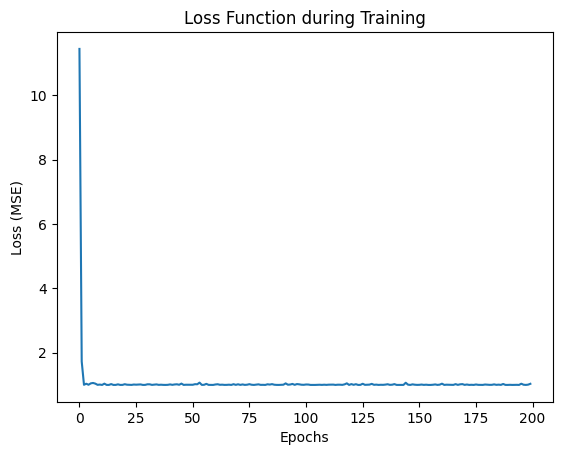

In [15]:
import matplotlib.pyplot as plt

# Plot the cost history
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Loss Function during Training')
plt.show()


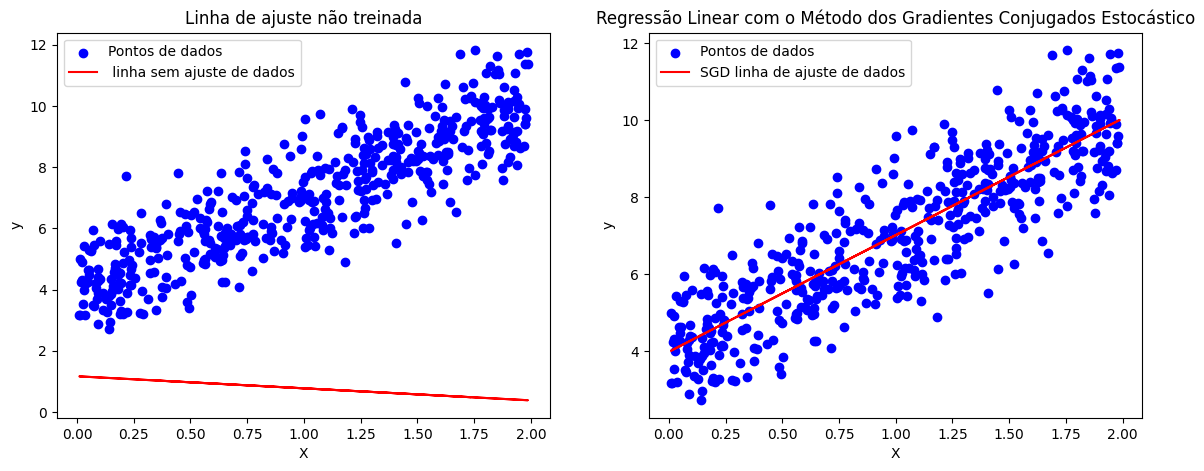

In [16]:
# Plot the data and the regression line
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
w_0 = np.random.randn(2, 1)
plt.scatter(X, y, color='blue', label='Pontos de dados')
plt.plot(X, np.c_[np.ones((X.shape[0], 1)), X].dot(w_0), color='red', label=' linha sem ajuste de dados')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linha de ajuste não treinada')
plt.legend()
plt.subplot(1,2,2)
plt.scatter(X, y, color='blue', label='Pontos de dados')
plt.plot(X, np.c_[np.ones((X.shape[0], 1)), X].dot(w_final), color='red', label='SGD linha de ajuste de dados')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Regressão Linear com o Método dos Gradientes Conjugados Estocástico')
plt.legend()
plt.show()


In [17]:
# Cáculo das perdas (loss)
# ===
def mse_loss(y_true, y_pred):
  return ((y_true - y_pred) ** 2).mean()
# ===

# retorna o mapa de perdas
# ===
def get_loss(x,y):
    w=np.zeros(101)
    b=np.zeros(101)
    
#   mapa das perdas em um gráfico bidimensional de pesos e bias na faixa (-5,8)
    losses = [[0.0] * 101 for _ in range(101)]
    for iw in range(101):
      for ib in range(101):
        w[iw] = -5.0 + 13.0 * iw / 100.0
        b[ib] = -5.0 + 13.0 * ib / 100.0
    
        ywb = x * w[iw] + b[ib]
        losses[iw][ib] = mse_loss(y,ywb)
    return losses,w,b

# Gráfico de curvas de nível com convergência dos pesos e bias via SGD
def isolinhas(x,y):
    losses,w,b=get_loss(x,y)
    levels=np.sort(np.array(loss_history))
    
    plt.figure()
    title='Convergência do Método dos Gradientes Descendentes'
    cp=plt.contour(w,b, losses,levels,colors='black', linestyles='dashed', linewidths=1)
    plt.clabel(cp, inline=1, fontsize=10)
    plt.contourf(w, b, losses,levels,alpha=0.5)
    plt.scatter(w_model[:,0],w_model[:,1],c='r',marker='+')
    plt.plot(w_model[:,0],w_model[:,1],c='r')
    plt.xlabel('w')
    plt.ylabel('b')
    plt.title(title)
    plt.show()
def trace():
# traçado da reta de ajuste dos dados do problema
#===
    plt.figure()
    title='aproximação Linear dos pontos do problema'
    plt.scatter(x, y, facecolors='b', edgecolors='b')
    plt.plot(
      [x.min(), x.max()],
      [w_final[0] * x.min() + w_final[1], w_final[0] * x.max() + w_final[1]],
      c='r')
    plt.title(title)

*Gradient Clipping*  é o processo que ajuda a manter a estabilidade numérica, impedindo que os gradientes cresçam demais. Ao treinar uma rede neural, os gradientes da função de perda são calculados por meio de retropropagação. No entanto, se esses gradientes se tornarem muito grandes, as atualizações dos pesos do modelo também podem se tornar excessivamente grandes, levando à instabilidade numérica. Isso pode resultar na produção de valores NaN (Not a Number - Não é um Número) ou erros de *overflow* o que pode ser problemático. Esse problema é frequentemente chamado de "explosão de gradiente" e pode ser resolvido truncando o gradiente em um valor desejado.

In [18]:
import numpy as np

# dados do problema
# ===
np.random.seed(20240215)
n = 50
x = np.array(np.random.randn(n))
y = np.array(0.775 * x**2 + 1.0 * x +0.5+ 0.3 * np.random.randn(n))

In [19]:
# Optimização dos pesos e bias - sgd sem *gradient clipping*
# ===

w_model, loss_history = sgd(x, y, learning_rate=0.1, epochs=100, batch_size=10,clip=False,
                            momentum=0.0,RMSprop=False,adam=False,verbose=False)
w_final=w_model[-1]

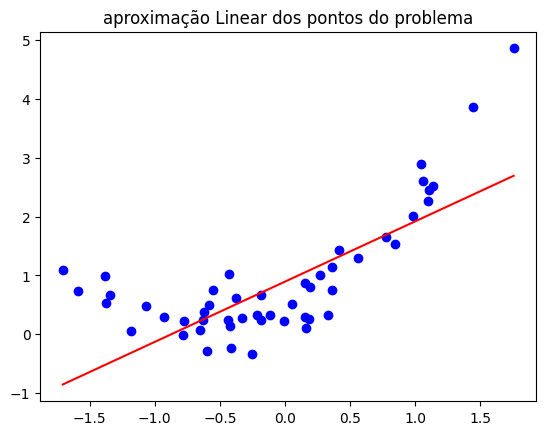

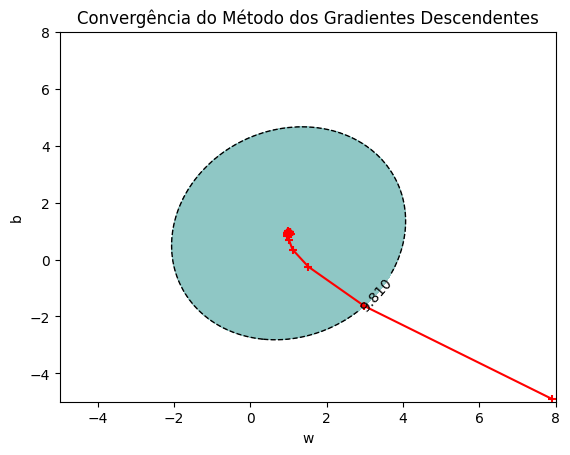

In [20]:
trace()
isolinhas(x,y)

In [21]:
# Optimização dos pesos e bias - sgd com *gradient clipping*
# ===

w_model, loss_history = sgd(x, y, learning_rate=0.1, epochs=100, batch_size=10,
                            momentum=0.0,RMSprop=False,adam=False,verbose=False)
w_final=w_model[-1]

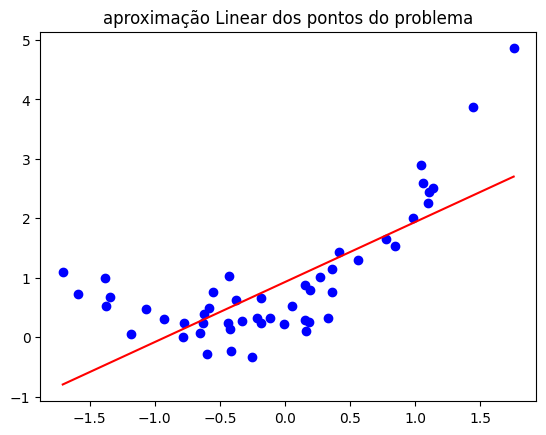

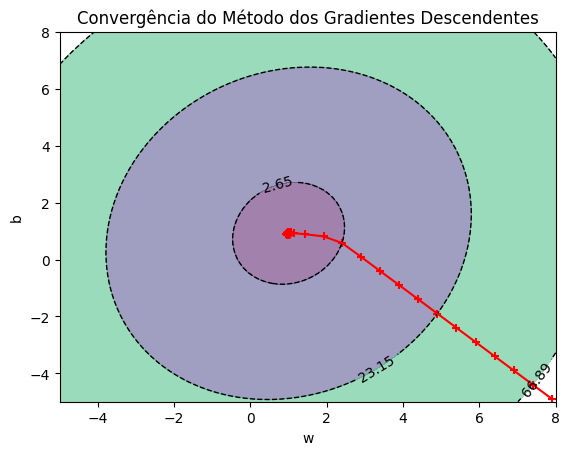

In [22]:
trace()
isolinhas(x,y)

## SGD com *momentum*

$$ v_W =\text{momentum} *v_W+\alpha \nabla_WJ(W)$$
$$ W=W-v_W$$

Características do SGD com momentum:

    Acumula a média móvel dos gradientes anteriores
    Auxilia a atravessar por pequenas variações locais
    Pode acelerar a convergência
    Favorece as dimensões onde o gradiente aponta na mesma direção e reduz a atualização nas dimensões onde os gradientes mudam de direção, levando a menor oscilação.



In [23]:
# Optimização dos pesos e bias - sgd com momentum
# ===

w_model, loss_history = sgd(x, y, learning_rate=0.01, epochs=50, batch_size=1,
                            momentum=0.9,RMSprop=False,adam=False,verbose=False)
w_final=w_model[-1]

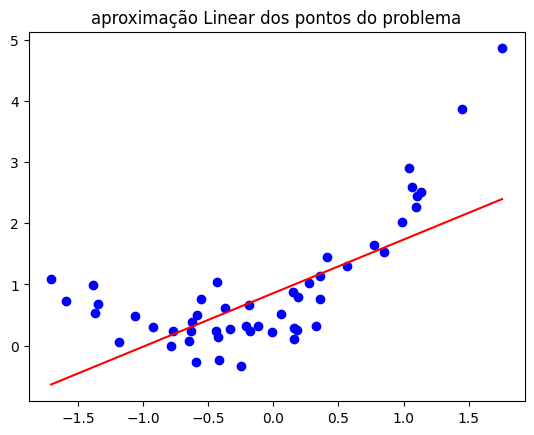

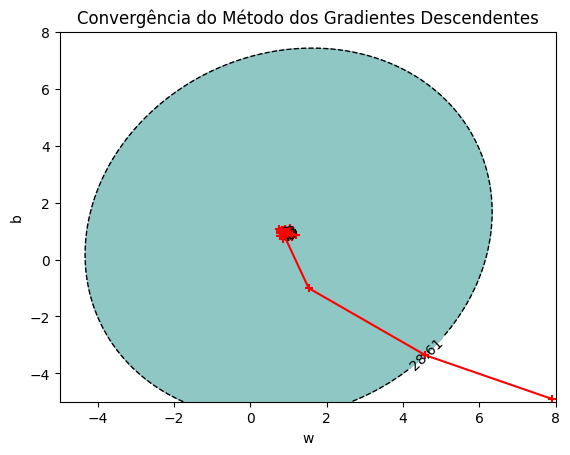

In [24]:
trace()
isolinhas(x,y)

## SGD com RMSprop (RMS propagation)

$$E(grad^2)=\beta E(grad^2)+(1-\beta)(\frac{\partial J}{\partial w})^2$$

$$W(t+1)=w(t)-\eta\frac{1}{\sqrt{E(grad^2)+\epsilon}}\frac{\partial J}{\partial w}$$

onde $E(grad^2)$ é o valor RMS dos gradientes.

Essencialmente, o que as equações acima fazem é:

* Adaptar a taxa de aprendizado para cada parâmetro, o que é crucial, pois parâmetros diferentes podem exigir taxas de aprendizado diferentes.
* Lidar com o problema do "gradiente evanescente", comum em redes neurais, onde os gradientes se tornam muito pequenos devido à retropropagação. Esse efeito é mitigado pela normalização dos gradientes.
* Balancear o tamanho do passo:

Para parâmetros com gradientes grandes (atualizados com frequência), a soma dos gradientes ao quadrado no denominador será grande, reduzindo a taxa de aprendizado efetiva.
Para parâmetros com gradientes pequenos (atualizados com pouca frequência), o denominador será menor, aumentando a taxa de aprendizado efetiva.


In [25]:
# Optimização dos pesos e bias - MSEprop
# ===

w_model, loss_history = sgd(x, y, learning_rate=0.01, epochs=50, batch_size=1,
                            momentum=0.0,RMSprop=True,adam=False,verbose=False)
w_final=w_model[-1]

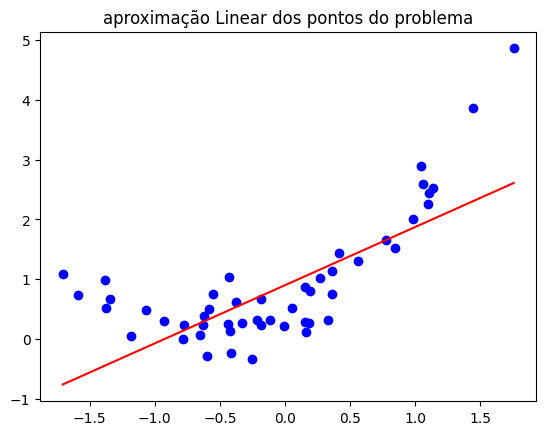

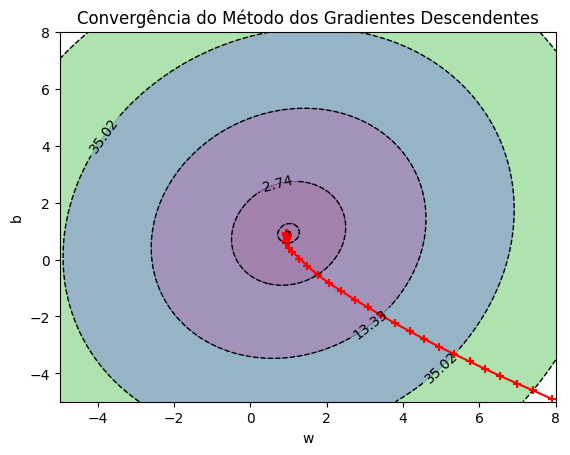

In [26]:
trace()
isolinhas(x,y)

## SGD com Adam(adaptive Moment Estimation)

$$m_t=\beta_1 m_{t-1}+(1-\beta_1)\frac{\partial J}{\partial w}$$
$$v_t=\beta_2 v_{t-1}+(1-\beta_2)(\frac{\partial J}{\partial w})^2$$

$m_t$ e $v_t$ são os valores médios (estimativa) do primeiro e segundo momento dos gradientes. Como esses vetores são inicializados vom valores nulos, eles apresentam um viés em direção à zero, principalmente nos passos iniciais, e portanto uma correção é realizada nas estimativas:
$$\hat{m_t}=\frac{m_t}{1-\beta_1^t}$$
$$\hat{v_t}=\frac{v_t}{1-\beta_2^t}$$

e daí

$$w(t+1)=w(t)-\eta \frac{1}{\sqrt{\hat{v_t}}+\epsilon}\hat{m_t}$$

1. O primeiro vetor de momento (m):

* É uma estimativa da média (primeiro momento) dos gradientes.
* Calculado como uma média exponencialmente decrescente dos gradientes anteriores.
* Ajuda a estimar a direção do gradiente.

2. O segundo vetor de momento (v):

* É uma estimativa da variância não centrada (segundo momento) dos gradientes.
* Também calculado como uma média exponencialmente decrescente, mas de gradientes ao quadrado.
* Ajuda a adaptar a taxa de aprendizado para cada parâmetro.

O primeiro momento atua como momentum, acumulando gradientes passados ​​para dar à otimização um senso de direção e velocidade. Isso ajuda o Adam a se mover mais rápido em direções consistentes e amortece oscilações em cenários de gradientes com ruído.

O segundo momento, como no RMSprop, adapta a taxa de aprendizado para cada parâmetro. Ele normaliza efetivamente as atualizações dos parâmetros, desacelerando o aprendizado para parâmetros com gradientes grandes e acelerando-o para aqueles com gradientes pequenos. Isso permite que o Adam manipule parâmetros em diferentes escalas de forma eficaz.

In [27]:
# Optimização dos pesos e bias - sgd - adam
# ===

w_model, loss_history = sgd(x, y, learning_rate=0.01, epochs=50, batch_size=1,
                            momentum=0.0,RMSprop=False,adam=True,verbose=False)
w_final=w_model[-1]

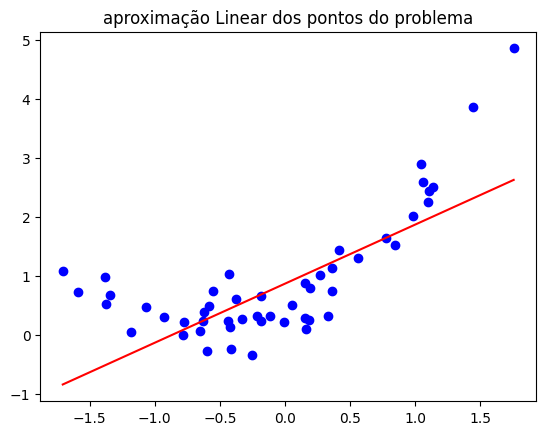

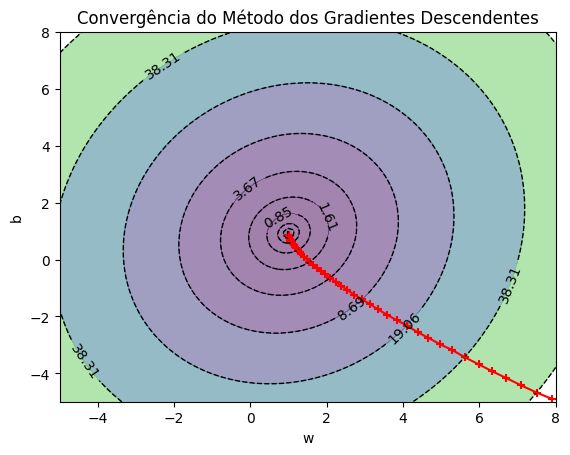

In [28]:
trace()
isolinhas(x,y)

### Comparação dos diferentes métodos

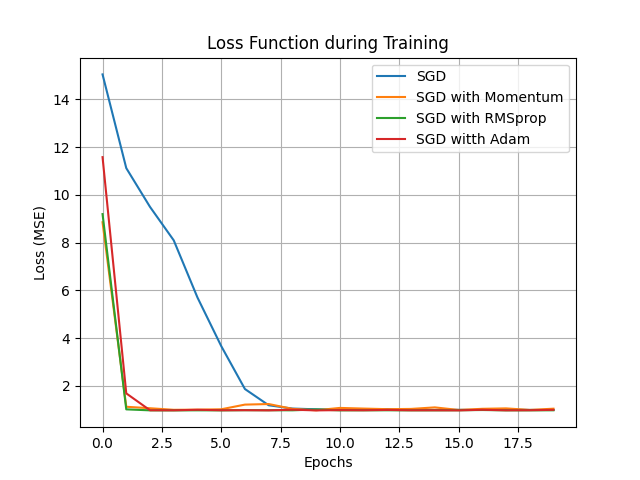

# Problemas de Regressão

Existem duas categorias principais de aprendizado supervisionado:

* Classificação
* Regressão

**Classificação**

A classificação lida com a previsão de variáveis pertencentes à categorias que representam classes ou rótulos discretos. Por exemplo, classificar e-mails como spam ou não spam, ou prever se um paciente tem alto risco de doença cardíaca. Os algoritmos de classificação aprendem a mapear os recursos de entrada para uma das classes predefinidas. Os exemplos que temos lidados até aqui pertencem a esta categoria. Em alguns casos, precisamos conhecer as probabilidades de uma varíavel pertencer à uma categoria ou não. Usa-se então a função *sigmoid*, ou *softmax* quando são várias categorias (ver o exemplo com a classificação de gênro segundo pesos e alturas).

**Regressão**

A regressão, por outro lado, lida com a previsão de variáveis-alvo contínuas, que representam valores numéricos. Por exemplo, prever o preço de uma casa com base em seu tamanho, localização e comodidades, ou prever as vendas de um produto. Os algoritmos de regressão aprendem a mapear os recursos de entrada para um valor numérico contínuo.

    Regressão Linear :A regressão linear é um tipo de algoritmo  supervisionado que aprende com conjuntos de dados rotulados e mapeia os pontos de dados com funções lineares otimizadas, que podem ser usadas para previsão em novos conjuntos de dados. Ela calcula a relação linear entre a variável dependente e uma ou mais características independentes, ajustando uma equação linear com dados observados. Ela prevê as variáveis de saída contínuas com base na variável de entrada independente.
    Por exemplo, se quisermos prever o preço de um imóvel, consideramos vários fatores, como idade do imóvel, distância da estrada principal, localização, área e número de cômodos. A regressão linear usa todos esses parâmetros para prever o preço do imóvel, pois considera uma relação linear entre todas essas características e o preço do imóvel.

    Regressão Polinomial: A regressão polinomial é uma ferramenta poderosa para suavização de dados que pode ajudá -lo a fazer previsões, identificar tendências e muito mais.Envolve ajustar uma equação polinomial a um conjunto de pontos de dados, que podem ser usados para fazer previsões ou analisar tendências. É usada quando a relação entre as variáveis não é linear e os pontos de dados seguem uma tendência curvilínea. Por exemplo, uma curva em forma de U, ou uma relação cúbica.

Exemplo: Neste exemplo a força calculada sobre o peso ligado à uma mola é calculada como $F=mg$ e para cada peso (o qual cresce em intervalos de 50 g) é medida a distensão da mola $\Delta x$. Os valores são inseridos em um algoritmo de regressão linear ( neste caso, uma calculadora HP prime) e o ajuste é realizado.  

<table>
    <tr>
      <td>
      <img src='.\Mola1.png'width=400>
      </td>
      <td>
      <img src='.\Mola2.png'width=400>
      </td>
      <td>
      <img src='.\Mola3.png'width=400>
      </td>
     </tr>
</table>

## Exemplos com Keras/Tensorflow

### a) Regressão Linear

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import backend

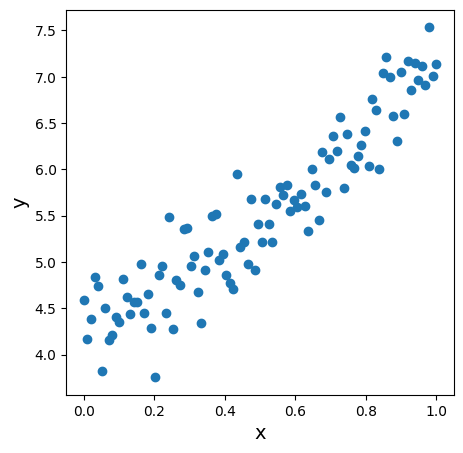

In [3]:
np.random.seed(0)
num_points = 100
X1 = np.linspace(0,1, num_points)
y1 = 4 + 3 * X1 + np.random.randn(num_points)/3

fig = plt.figure(figsize=(5, 5))
plt.scatter(X1, y1)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.show()

### Uma Camada e Um Neurônio

In [4]:
backend.clear_session()
np.random.seed(0)
random.seed(0)
tf.random.set_seed(0)
model1 = Sequential()
model1.add(Dense(1, activation='linear', input_shape=(1,)))
model1.compile(optimizer='adam', loss='mse', metrics=['mse'])
model1.summary()

C:\Users\Avell\Desktop\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
history1 = model1.fit(X1, y1, epochs=1000, verbose=0,
                      batch_size=X1.shape[0])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


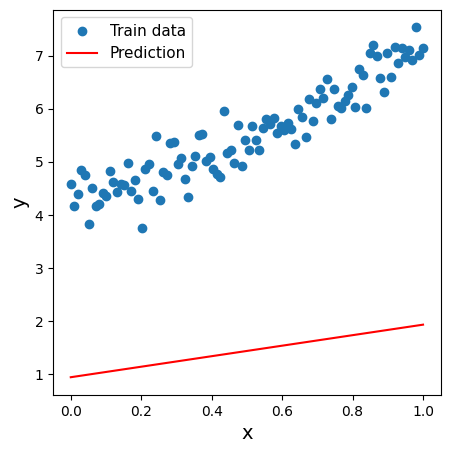

In [6]:
X1_test = np.linspace(0,1, 1000)
yhat1 = model1.predict(X1_test)

fig = plt.figure(figsize=(5, 5))
plt.scatter(X1, y1, label="Train data")
plt.plot(X1_test, yhat1, color="red", label="Prediction")
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend(loc="best", fontsize=11)
plt.show()

### Rede com Múltiplas camadas

In [7]:
backend.clear_session()
np.random.seed(15)
random.seed(15)
tf.random.set_seed(15)

input_layer = Input(shape=(1,))
x = Dense(50, activation='linear')(input_layer)
output_layer = Dense(1, activation='linear')(x)
model2 = Model(inputs=input_layer, outputs=output_layer)

model2.compile(optimizer='adam', loss='mse', metrics=['mse'])
model2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 1)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50)                  │             100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
history2 = model2.fit(X1, y1, epochs=500, verbose=0,
                      batch_size=X1.shape[0])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


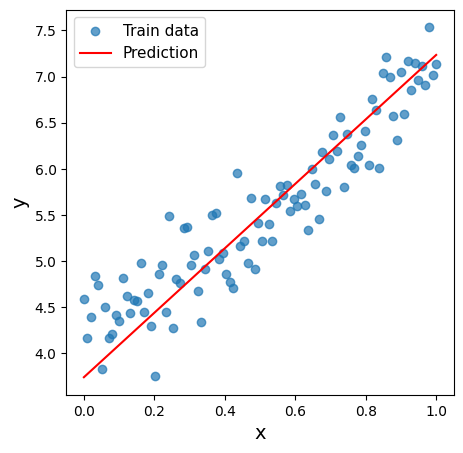

In [9]:
X1_test = np.linspace(0,1, 1000)
yhat1 = model2.predict(X1_test)

fig = plt.figure(figsize=(5, 5))
plt.scatter(X1, y1, label="Train data", alpha=0.7)
plt.plot(X1_test, yhat1, color="red", label="Prediction")
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend(loc="best", fontsize=11)
plt.show()

### b) Recursão Quadrática (Não Linear)

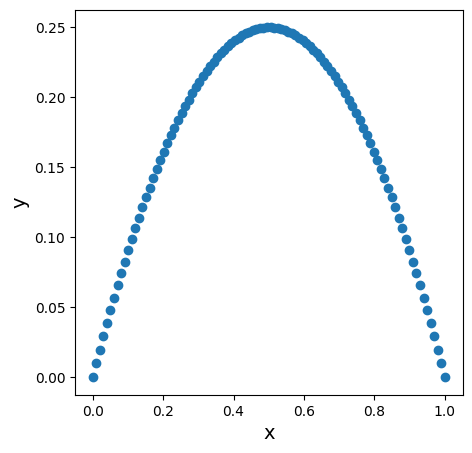

In [10]:
np.random.seed(0)
num_points = 100
X2 = np.linspace(0,1, num_points)
y2 = -(X2-0.5)**2 + 0.25

fig = plt.figure(figsize=(5, 5))
plt.scatter(X2, y2)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.show()

### Uma camada e um neurônio

In [11]:
backend.clear_session()
np.random.seed(0)
random.seed(0)
tf.random.set_seed(0)

model3 = Sequential()
model3.add(Dense(1, activation='relu', input_shape=(1,)))
model3.compile(optimizer='adam', loss='mse', metrics=['mse'])

In [12]:
history3 = model3.fit(X2, y2, epochs=500, verbose=0,
                      batch_size=X2.shape[0])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


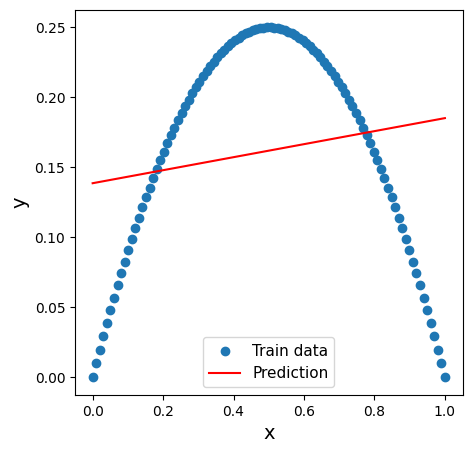

In [13]:
X2_test = np.linspace(0,1, 1000)
yhat2 = model3.predict(X2_test)

fig = plt.figure(figsize=(5, 5))
plt.scatter(X2, y2, label="Train data")
plt.plot(X2_test, yhat2, color="red", label="Prediction")
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend(loc="best", fontsize=11)
plt.show()

### Rede com Múltiplas camadas

In [14]:
backend.clear_session()
np.random.seed(15)
random.seed(15)
tf.random.set_seed(15)

input_layer = Input(shape=(1,))
x = Dense(100, activation='relu')(input_layer)
output_layer = Dense(1, activation='linear')(x)
model4 = Model(inputs=input_layer, outputs=output_layer)

model4.compile(optimizer='adam', loss='mse', metrics=['mse'])
model4.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 1)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history4 = model4.fit(X2, y2, epochs=1500, verbose=0,
                      batch_size=X2.shape[0])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


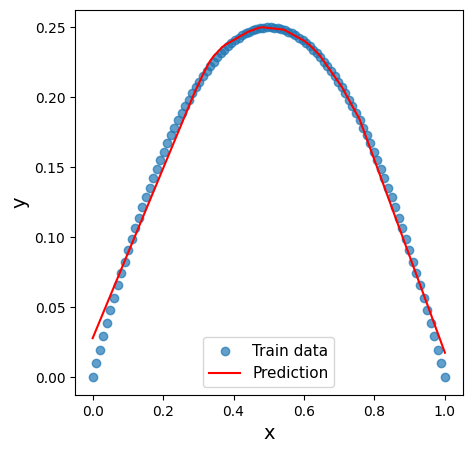

In [43]:
X2_test = np.linspace(0,1, 1000)
yhat2 = model4.predict(X2_test)

fig = plt.figure(figsize=(5, 5))
plt.scatter(X2, y2, label="Train data", alpha=0.7)
plt.plot(X2_test, yhat2, color="red", label="Prediction")
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend(loc="best", fontsize=11)
plt.show()

## Regressão Logística


A Regressão Logística é um dos algoritmos de aprendizado de máquina mais comuns. Ela pode ser usada para prever a probabilidade de ocorrência de um evento, como se um e-mail recebido é spam ou não, ou se um tumor é maligno ou não, com base em um determinado conjunto de dados rotulados.

Devido à sua simplicidade, a regressão logística é frequentemente usada como base para a avaliação de outros modelos mais complexos.
 O nome "Logística" vem da utilização da função *sigmoid* para converter a combinação linear de um conjunto de dados em probabilidades, e não apenas classificar os dados em categorias. O método é classificado como regressão pelo fato que sua saída é um valor contínuo entre 0 e 1, embora seja normalmente usado como um classificador binário, escolhendo um valor limite (geralmente 0,5) e classificando entradas com probabilidade maior que o limite como classe positiva, e aquelas abaixo do limite como classe negativa. Pelos motivos acima a função *sigmoid* é também conhecida como **Função Logística**.

 As funções *Sigmoid* e *SoftMax* atuam sobre uma variável $ -\infty \le x \le \infty$ transformando-as em um número $ 0 \le p(x) \le 1$ que representa a probabilidade de $x$ pertencer à uma certa classe ou categoria. 
 * Sigmoid: Usada para classificação binária, e seu resultado representa a probabilidade de $x$ pertencer a uma classe específica, enaquanto que a probabilidade de percencimento à uma segunda classe é dada por $1-p(x)$.
 * SoftMax : usada para problemas de múltiplas classes, e é uma extensão da função *Sigmoid*. A função é vetorizada, significando que a entrada  **x** é um vetor com o mesmo número de termos que as classes ou categorias do problema, a as sáidas são as probabilidades de cada elemento de **x** pertencer à uma dada categoria. 


* $P(y=k/X=x)$ é a probabilidade de $y$ pertencer à categoria k se $X$ tem o valor x. Então podemos escrever

  $$ X \in \mathbb{R} \rightarrow Sigmoid/SoftMax \rightarrow P(y=k/X=x) \in [0,1]$$

* Em estatística, probabilidade e odds (ou chances) são duas formas diferentes de expressar a chance de um evento ocorrer.

* A probabilidade $P(A)$, ou a probabilidade de um evento $A$ ocorrer é dada por:

  $$ P(A)=\frac{\text{Número de casos favoráveis}}{\text{Número total de casos possíveis}},$$ onde $P(A) \in [0,1] $. Como exemplos, a probabilidade de obter cara em um lance de moeda é $\frac{1}{2}=0,5$, ou seja, é um caso favorável em duas possibilidades,  enquanto a probabilidade de um lance de dado resultar no número 6 é $\frac{1}{6}$.

* As odds (chances)  são simplesmente a razão entre a probabilidade de um evento ocorrer e a probabilidade de ele não ocorrer, ou seja:

  $$ odds(A)=\frac{P(A)}{1-P(A)}$$

  onde se, por exemplo, $P(A)=1$, então $odds(A)=\infty$, e daí $odds(A) \in [0,\infty)$. Nos exemplos anteriores, se A é um lance de moeda resultando em cara, então $odds(A)=1$, e se A é o lance de um dado resultando no número 6, então $odds(A)=\frac{\frac{1}{6}}{1-\frac{1}{6}}=\frac{1}{5}$. Ainda, se dissermos que as chances de um determinado corredor chegar em primeiro em uma corrida são $\frac{3}{8}$, então isso significa que em 11 corridas o corredor vence 3 e perde 8.



**A regressão logística é uma extensão da regressão linear**. No problema de regressão linear os pesos $w_i$ são encontrados tal que 
$$z=w_0+w_1x_1+w_2 x_2+\textellipsis +w_mx_m\;\in\;(-\infty,\infty)$$
Por sua vez  a função logística ou *Sigmoid*  mapeia o intervalo $(-\infty,\infty)$ no intervalo $[0,1]$: Vamos escrever $z=logit(P(x))$, onde

$$ logit(P(x))=Ln\left(\frac{P(x)}{1-P(x)}\right)$$


Assim,
    $$z=Ln\left(\frac{P(x)}{1-P(x)}\right) \rightarrow e^z = \frac{P(x)}{1-P(x)},$$

onde como definido acima $z=\omega_0+\omega_1x_1 +\textellipsis + \omega_mx_m$ é a soma ponderada das entradas ao último neurônio. 

Resolvendo para $P(x)$ temos

$$P(x)(1+e^z)=e^z\rightarrow P(x)=\frac{e^z}{1+e^z}=\frac{1}{1+e^{-z}}.$$


Por outro lado, a função *Softmax* tem como entrada um vetor cuja dimensão é o número de categorias do problema de classificação,  ou seja, 
$$\bf{h}=\begin{bmatrix}h1\\h2\\\vdots\\h_k\end{bmatrix}$$
onde $h_i$ é a saída do i-ésimo neurônio da camada anterior. Como anteriormente, $h_i \in (-\infty,\infty)$ e precisamos de um vetor onde cada elemento é uma probabilidade tal que $P_i \in [0,1]$. Além disso, as probabilidades tem que ter sua soma igual a unidade, ou seja, o vetor de saída deve ser uma distribuição de probabilidades sobres as classes possíveis. Estendendo o procedimento adotado na função Logística ao vetor $\bf(h)$, teremos
$$ \bf{h}=\begin{bmatrix}logit(P(y=\text{classe 1}|x)\\logit(P(y=\text{classe 2}|x)\\\vdots\\logit(P(y=\text{classe k}|x))\end{bmatrix}$$

Entretanto, a função *Sigmoid* não pode ser aplicada aqui porque são obtidas apenas probabilidades isoladas patra cada elemento de $\bf{h}$, não uma distribuição de probabilidade sobre todas as classes. Como exemplo, suponha-se que o vetor $\bf{h}$ seja formado pelos valores $\{ 3.,1.75,-2.,0.5\}$. A aplicação da função *Sigmoid* resultará nos valores $\{0.95,0.85,0.12,0.62\}$, cuja soma é aproximadamente 2.55, ou seja, não é uma distribuição de probabilidades. Para converter  $\bf{h}$ em uma correta distribuição de probabilidade, podemos aplicar a função exponencial para cada termo do vetor de forma que $e^{h_i} = e^{ln(odds(P(h_i)))}= odds(P(h_i))\in [0,\infty)$. Esta operação resulta em  uma estimativa das probabilidades, mas para termos uma distribuição, ou seja, para que a soma de todos os elementos seja igual a 1, normalizamos (dividimos)  cada $e^{h_i}$ pela somatória de todos os termos, ou seja, 

$$SoftMax=\frac{e^{h_i}}{\sum_j e^{h_j} }$$

Repetindo agora o exemplo anterior, obtemos os valores $\{0.725,0.21,0.005,0.06\}$ cuja soma é igual a 1. Temos então uma distribuição de probabilidades.

* **Função MSE x *logloss***

  A regressão logística se caracteriza pelo uso de funções *Sigmoid* para comprimir a saída na faixa entre zero e um, e assim resultar em uma função de probabilidade, e no uso da função *logloss* no cálculo do erro ao invés do mínimo erro quadrático (MSE). A função *Logloss* é 

 $$f=-yln(p)-(1-y)ln(1-p)$$

e a função custo é

$$ J(w)=-\frac{1}{n}\sum_{i=1}^{n}(y(ln(\hat{y_i})+(1-y)ln(1-\hat{y_i})) $$

 Agora, vamos ver como a função logarítmica acima funciona nos dois casos de uso da regressão logística, ou seja, quando o valor de saída real é 1 ou 0.
Como dito acima, em geral  a saída do modelo de regressão logística é a probabilidade de a amostra de entrada ser positiva (indicada por 1). Se um modelo de regressão logística for treinado para classificar um e-mail como spam e não spam, onde o e-mail sendo spam (=positivo) é indicado como 1 e não spam (=negativo) como 0, então a saída do modelo *p* é a probabilidade de o e-mail ser spam (=positivo). Se quisermos a probabilidade de o e-mail não ser spam (=negativo), ela pode ser representada como *1-p*.

 Se, por exemplo, o valor verdadeiro é $y=1$ e duas saídas são $p_1=0,4$ e $p_2=0,6$ é esperado que na avaliação $p_1$ sofra uma penalidade maior que $p_2$, pois $p_2 > 0,5$. Substituindo na expressão da função *logloss* temos:

  $ -ln(0,4)=0,92$ enquanto que $-ln(0,6)=0,51$, ou seja , a penalidade sobre a probabilidade mais baixa ("mais errada") é maior. 

  Caso contrário, se o valor verdadeiro é $y=0$, com as mesmas saídas $p_1$ e $p_2$, então, $-ln(1-0,4)=-ln(0,6)=0,51$, enquanto $-ln(1-0,6)=-ln(0,4)=0,92$, ou seja, $p_2$ é mais penalizada. Além disso, podemos perceber que em caso de disparate total na resposta, ou seja, $y=1$ e $p=0$, $J(w)=-yln(0)\rightarrow \infty$ enquanto que o a função custo MSE tem sua resposta limitada em 1. 

 Outro fator importante na escolha de uma função custo adequada é a convexidade da mesma em função dos pesos $w_i$. A convexidade de uma função depende da sua derivada segunda, ou seja, para uma função convexa a derivada segunda deve ser não negativa em todo domínio da função. Isto pode ser mostrado como segue:

 sabemos que se uma função $f(x)$ é convexa, então para três pontos quaisquer $x_1\;,x_c\;\text{e}\;x_2,\;x1<x_c<x_2$, podemos escrever

 $$f(x_c)\le\frac{f(x_1)+f(x_2)}{2}.$$

 No intervalo entre $x_c$ e $x_1$ existe um ponto $x_{c1}$ tal que (teorema do valor intermediário):

 $$ f(x_c)-f(x_1)=f'(x_{c1})(x_c-x_1).$$

 O mesmo vale para o intervalo entre os pontos $x_c$ e $x_2$, ou seja, existe um ponto $x_{c2}$ entre eles tal que

 $$ f(x_2)-f(x_c)=f'(x_{c2})(x_2-x_c).$$

 Subtraindo estas duas expressões temos, 

 $$2f(x_c)-f(x_1)-f(x_2)=f'(x_{c1})(x_c-x_1)-f'(c_{c2})(x_2-x_c),$$

 e usando novamente o teorema do valor intermediário para a derivada segunda em um ponto $x_{c3}$ entre $x_{c1}$ e $x_{c2}$ resulta em

 $$f'(x_{c2})-f'(x_{c1})=f^{"}(x_{c3})(x_{c2}-x_{c1}).$$

 Façamos agora a suposição que $f^{"}(x_{c3})\ge 0$. Então $f'(x_{c2})-f'(x_{c1}) \ge 0$, implicando $2f(c)-f(x_1)-f(x_2) \le 0$. Portanto, $f(x_c)\le\frac{f(x_1)+f(x_2)}{2}$.
 
 No caso da função *Logloss* atuando no neurônio de saída, a sua derivada em função de $\hat{y}$ é inicialmente calculada como (considerando  o número de características *n=1*)

 $$\frac{\partial J(\hat{y})}{\partial\hat{y}}=-\frac{y}{\hat{y}}+\frac{1-y}{a-\hat{y}}=\frac{-y(1-\hat{y})+\hat{y}(1-y)}{\hat{y}(1-\hat{y})}=\frac{\hat{y}-y}{\hat{y}(1-\hat{y})}$$

 onde o denominador do último termo é, como já foi visto, a derivada das função *Sigmoid* com respeito à $x$, e portanto a derivada com respeito à *w* é 
 
 $$\frac{\partial }{\partial w}\left(\frac{1}{1+e^{-wx}}\right)=x\frac{e^{-wx}}{\left(1+e^{-wx}\right)^2}=x\hat{y}(1-\hat{y}).$$

 Usando as duas últimas derivadas parciais para obter $\frac{\partial J(w)}{\partial w}$ , temos, 

 $$\frac{\partial J(w)}{\partial w}=\frac{\partial J(\hat{y})}{\partial \hat{y}}\frac{\partial \hat{y}(w)}{\partial w}=\frac{\hat{y}-y}{\hat{y}(1-\hat{y})} x\hat{y}(1-\hat{y})=x(\hat{y}-y)=\frac{x}{1+e^{-wx}}-xy,$$ 

e para *n >1* características,

$$\frac{\partial {J(w)}}{\partial w_j}=\frac{1}{n}\sum_{i=1}^{n} [(p_i-y_i) x_{ij}].$$
 A derivada segunda da função *Logloss* em função dos pesos *w* é, calculada diretamente das expressões anteriores
 $$ \frac{\partial^2J}{\partial w^2}=\frac{\partial x(\hat{y}-y)}{\partial w}=x\frac{\partial \hat{y}}{\partial w}=x^2\hat{y}(1-\hat{y})=\frac{x^2e^{-wx}}{(1+e^{-wx})^2}.$$

Portanto $ \frac{\partial^2J}{\partial w^2} \ge 0$, pois $\infty \ge \; e^{-wx}\;\ge 0$ para $x \in (-\infty,\infty)$, e assim a função *Logloss* associada com a função de ativação *sigmoid* é convexa.

Por outro lado, a função custo MSE é $J(w)=(y-\hat{y})^2$, e assim,
$$\frac{\partial J}{\partial w}=\frac{\partial  }{\partial \hat{y}}\frac{\partial \hat{y}}{\partial w}=-2(y-\hat{y})\hat{y}(1-\hat{y})x=-2(y\hat{y}-y\hat{y}^2-\hat{y}^2+\hat{y}^3)x=g(w)$$
a derivada segunda pode finalmente ser calculada como
$$\frac{\partial^2 J}{\partial w^2}=\frac{\partial g}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial w}=-2(y-2y\hat{y}-2\hat{y}+3\hat{y}^2)\hat{y}(1-\hat{y})x^2,$$

$$ \frac{d^2f}{dw^2}=-2(3\hat{y}^2-2\hat{y}(y+1)+y)\hat{y}(1-\hat{y})x^2.$$

 $x^2\ge0$ e $0\le\hat{y}(1-\hat{y})\le\frac{1}{4}$ (O máximo ocorre quando $y_p=\frac{1}{2}$), portanto a convexidade da função MSE dependerá do primeiro termo entre parênteses. Note que em um problema de classificação, $y=1$ ou $y=0$. Daí, quando $y=0$, temos que $-[3\hat{y}^2-2\hat{y}(y+1)+y]=-[3\hat{y}^2-2\hat{y}]=-3\hat{y}(\hat{y}-\frac{2}{3})< 0 $ quando $\hat{y}\;\in\;(\frac{2}{3},1]$. Por outro lado, quando $y=1$, temos $-[3\hat{y}^2-2\hat{y}(y+1)+y]=-[3\hat{y}^2-4\hat{y}+1]=-[3(\hat{y}-\frac{1}{3})(\hat{y}-1)] < 0$ quando $\hat{y}\;\in\;[0,\frac{1}{3})$. Portanto, podemos concluir que a função MSE não será convexa em algumas faixas de valores de $\hat{y}$, podendo dificultar a convergência no algorítmo do Método dos gradientes descendentes.

Outra dificuldade com o MSE é o possível erro de cancelamento e arredondamento na operação $(y-\hat{y})^2$ para valores próximos das duas variáveis.

Para verifcação desta análise usaremos o conjunto de dados Íris (licença BSD). O conjunto de dados original contém 150 amostras de flores Íris que pertencem a uma de três espécies, Íris setosa, Íris versicolor ou Íris virginica. Para classificação binária apenas os dois primeiros tipos (setosa e versicolor) serão usados, e também apenas as duas primeiras características de cada flor (largura e comprimento da sépala). Para a contrução do modelo será usado apenas um perceptron, no qual a otimização dos pesos será realizada pelo método dos gradientes descendentes. É necessário portanto que as duas categorias sejam linearmente separáveis. 

In [44]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

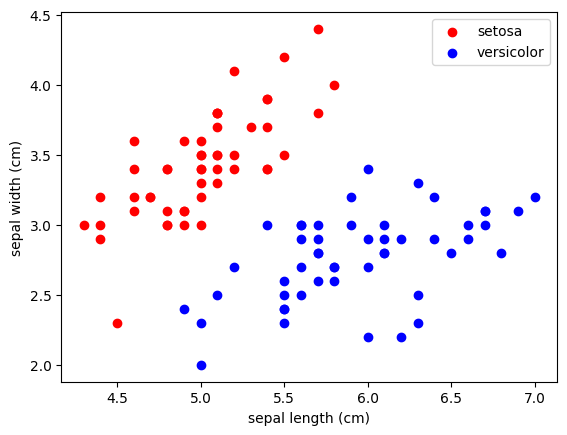

In [45]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:, :2]  # somente as duas primeiras características (comprimento e largura)
y = iris.target       # 0=setosa,1=versivolor e 2=virginica

# seleciona flores setosa e versicolor
X = X[(y == 0) | (y == 1)] # apenas dados cuja classe seja setosa ou versicolor
y = y[(y == 0) | (y == 1)] # apenas os rótulos dessas duas classes

def plot_data(X, y):
    # Plota os pontos de dados
    plt.scatter(X[y==0, 0], X[y==0, 1],c='red',label='setosa')
    plt.scatter(X[y==1, 0], X[y==1, 1],c='blue',label='versicolor')
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.legend() 

plot_data(X,y)

Como pode ser visto na figura acima o conjunto de dados é linearmente separável, portanto a regressão logística deve ser capaz de encontrar o limite entre as duas classes.

In [46]:
# Adiciona uma coluna para as *bias*
n = X.shape[0] 
X_with_bias = np.hstack((np.ones((n, 1)), X))

# separa os dados em conjunto de treino e conjunto de teste

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_with_bias, y, random_state=0)

* Implementa o Modelo:

In [47]:
def sigmoid(z):
    # z pode ser um escalar ou um vetor
    z = np.array(z)
    return 1 / (1 + np.exp(-z))

def cost_function(X, y, w):
    # Custo
    p = sigmoid(X @ w)    
    J = -(1/n) * (y @ np.log(p) + (1-y) @ np.log(1-p)) 

    # Gradiente    
    grad = (1/n) * X.T @ (p - y)  
    return J, grad


In [48]:
def model_sgd(X, y, alpha=0.01, max_iter=5000, tol=0.0001):
     """  
    X, y: dados de treino        
    alpha: taxa de aprendizado
    max_iter: máximo numero de iterações sobre o conjunto de dados
    tol: critério de parada
    """
     w = np.random.rand(X.shape[1])
     cost, grad = cost_function(X, y, w)
     
     for i in range(max_iter):
        w = w - alpha * grad
        new_cost, grad = cost_function(X, y, w)        
        if np.abs(new_cost-cost) < tol:
            print(f'Convergiu após {i} interações')
            return w, new_cost
        cost = new_cost

     print('Maximo número of interações atingido')
     return w, cost

* Otimização do modelo

In [49]:
w_ot, cost = model_sgd(X_train, y_train)

print('w_otim:', w_ot)
print('Custo com  w_otim:', cost)

Convergiu após 1323 interações
w_otim: [ 0.26031859  0.80769812 -1.48135735]
Custo com  w_otim: 0.2838184055040824


* Linha de Fronteira

A linha de fronteira é definida pelos pontos para os quais a previsão do nosso modelo é exatamente 0,5, ou seja,

$$p=sigmoid(\bf{w}^T\bf{x})=0,5\rightarrow \frac{1}{1+e^{-w^Tx}}=0,5\rightarrow 1+e^{-w^Tx}=2 \rightarrow e^{-wTx}=1$$
e então $\bf{w^Tx}=0$. Daí,$ \bf{w^Tx}$=$w_0+w_1 x_1+w_2 x_2=0$, ou ainda

$$ x_2=-\frac{1}{w_2}\left(w_1x_1+w_0\right)$$  

In [50]:
def plot_decision_boundary(X, y, w):
   
    plot_data(X, y)

    line_x = np.array(plt.gca().get_xlim()) # retorna os limites no eixo x; line_x=[x_min,x_max]
    line_y = -1 / w[2] * (w[1] * line_x + w[0]) 
    plt.plot(line_x, line_y, c='k', ls='--')

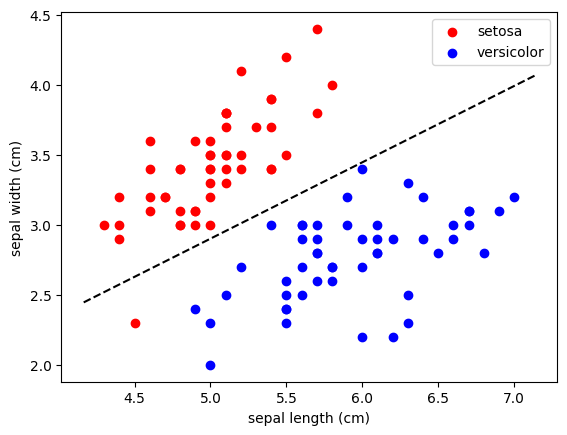

In [51]:
plot_decision_boundary(X, y, w_ot)

* Predições com o Modelo
  
 A função  predict_prob() calcula as previsões do modelo com base no cálculo da função sigmoide de $x^Tw$.

In [52]:
def predict_prob(X, w):
    """ retorna a probabilidades que as amostras em X petençam a classe versicolor 
    """
    p = sigmoid(X @ w)
    return p

In [53]:
predict_prob([[1, 6, 2]], w_ot) # amostra localizada em (6,2) 

array([0.8950873])

Esta amostra tem 89,5% de chance de ser uma flor versicolor.

In [54]:
predict_prob([[1, 5.5, 3]], w_ot) #amostra localizada em (5.5,3)

array([0.56428872])

Desta vez a probabilidade é bem menor (apenas 56,4%), pois esta amostra está próxima da fronteira entre as classes.

In [55]:
predict_prob([[1, 5.5, 4]], w_ot) #amostra localizada em (5.5,4)

array([0.22744915])

Probabilidade de 22,7% de ser uma versicolor, ou 77,3 % de ser uma setosa.


* Acurácia do Modelo
* 
A função predict() abaixo determina diretamente a classe a qual percence a amostra, retornando 1 para versicolor, ou 0 em caso contrário. A acurácia do modelo pode ser assim determinada com a função evaluate_model(), onde  é calculada como:

  $$ \text{Acurácia}=\frac{\text{ Previsões corretas}}{\text{Total de previsões}}$$

In [56]:
def predict(X, w):
    """ predição da classe a qual pertence a amostra"""
    p = sigmoid(X @ w)
    y_pred = (p >= 0.5).astype(int)
    return y_pred
    
def evaluate_model(X, y, w):
    y_pred = predict(X, w)
    accuracy = np.mean(y == y_pred)
    return accuracy

In [57]:
train_accuracy = evaluate_model(X_train, y_train, w_ot)
print(f'Train accuracy: {train_accuracy * 100:.3f}%')

Train accuracy: 98.667%


In [58]:
test_accuracy = evaluate_model(X_test, y_test, w_ot)
print(f'Test accuracy: {test_accuracy * 100:.3f}%')

Test accuracy: 100.000%


* Teste com maior número de épocas e menor tolerância

In [59]:
w_ot, cost = model_sgd(X_train, y_train,max_iter=3000000, tol=0.000000001)

print('w_otim:', w_ot)
print('Custo com  w_otim:', cost)

Maximo número of interações atingido
w_otim: [-30.01911016  13.42284157 -13.63500506]
Custo com  w_otim: 0.0077888830618650096


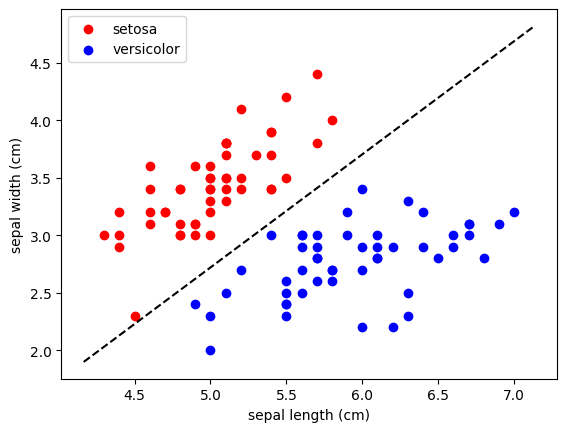

In [60]:
plot_decision_boundary(X, y, w_ot)

In [61]:
predict_prob([[1, 6, 2]], w_ot)

array([1.])

In [62]:
predict_prob([[1, 5.5, 3]], w_ot)

array([0.9479207])

In [63]:
predict_prob([[1, 5.5, 3.8]], w_ot)

array([0.00033318])

In [64]:
train_accuracy = evaluate_model(X_train, y_train, w_ot)
print(f'Train accuracy: {train_accuracy * 100:.3f}%')

Train accuracy: 100.000%


In [65]:
test_accuracy = evaluate_model(X_test, y_test, w_ot)
print(f'Test accuracy: {test_accuracy * 100:.3f}%')

Test accuracy: 100.000%


# Redes Neurais Convolucionais

São basicamente redes neurais que utilizam camadas convolucionais baseadas na operação matemática da convolução. As camadas convolucionais consistem em um conjunto de filtros, que podem ser consideradas como matrizes bidimensionais de números.

Podemos usar uma imagem de entrada e um filtro   para produzir uma imagem de saída convoluindo o filtro com a imagem de entrada. A operação de convolução entre duas funções $f(t)$ e $g(t)$ é a integral 
$$f(t)*g(t)= \int_{-\infty}^{\infty} f(t-\tau)g(\tau)d\tau$$

Isso consiste em:

* Sobrepor o filtro sobre a imagem em algum local.
* Realizar a multiplicação elemento a elemento entre os valores no filtro e seus valores correspondentes na imagem.
* Somar todos os produtos elemento a elemento. Essa soma é o valor de saída para o pixel de destino na imagem de saída.
Repetir para todos os locais.

Considere uma imagem consistindo de 16 *pixels* em uma estrutura matricial 4x4, onde cada número da matriz corresponde à intensidade do *pixel*, a ser convoluída  com um filtro representado por uma matriz de dimenõses 3 X 3. Durante o processo o filtro irá se sobrepor aos elementos na sub-matriz 3x3 no canto superior esquerdo, gerando o primeiro *pixel* na imagem convoluída. Depois o filtro desloca-se um nível para direita, e um novo *pixel* é gerado. O processo é repetido depois do filtro ser deslocado 1 nível avaixo sobre a imagem original, resultanto em mais dois *pixels*. Este processo resultando em uma matriz 2 X 2é mostrado na figura abaixo:

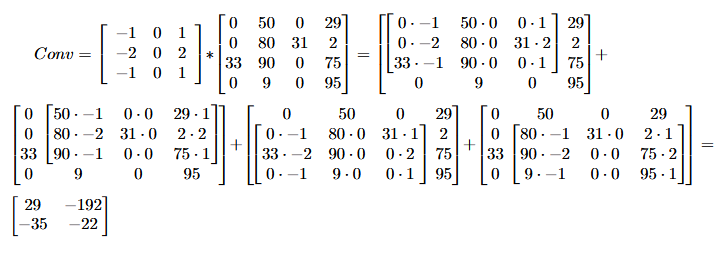

*Stride*  é a distância que o filtro percorre em cada passo ao longo de uma direção. No exemplo acima usamos *stride*=1. 

O filtro mostrado no exemplo é conhecido como filtro de Sobel, e é apropriado para identificar linhas verticais em uma imagem. A transposição de um filtro de Sobel resulta em um filtro de Sobel horizontal.

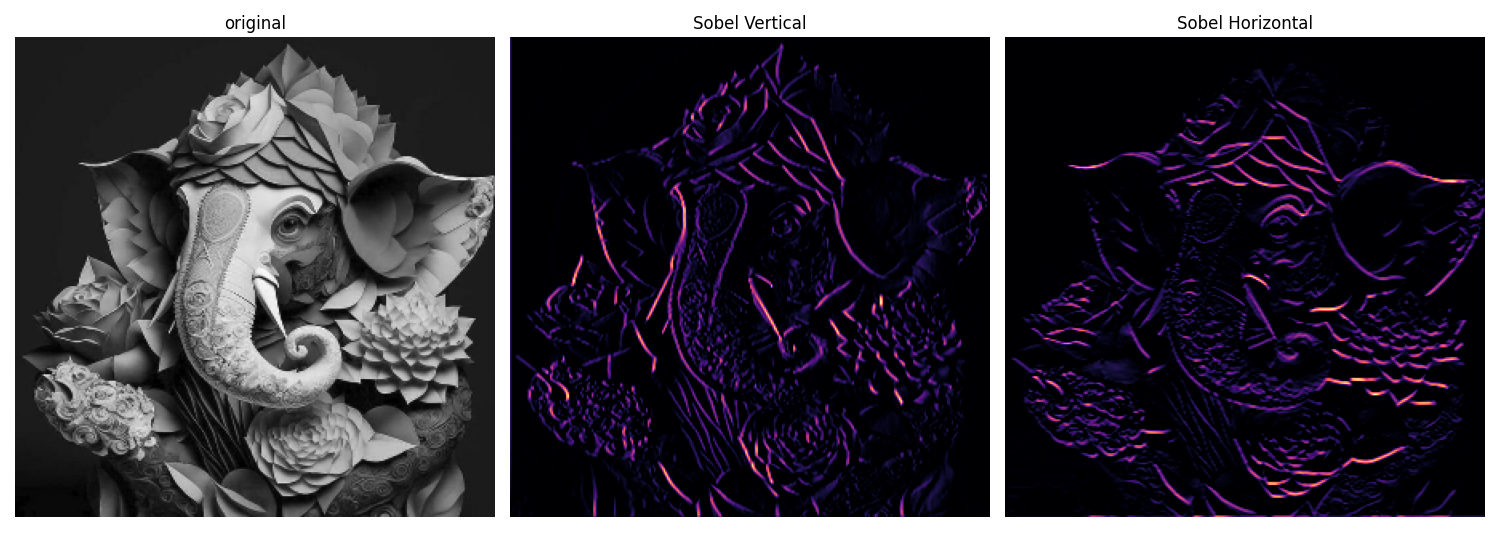

## *Padding*

Como vimos, convoluindo uma imagem 4x4 com um filtro 3x3 resulta em uma imagem de saída de dimensão 2x2. Entretanto, usando *padding* a imagem de saída pode ter a mesma dimensão que a imagem original. Para isto, zeros são adicionados em torno da imagem de forma que o filtro pode ser sobreposto nela em mais lugares. Esta técnica é chamada de "**same Padding**". Caso *padding* não seja usado, algumas vezes será chamado de "**Valid Padding**". Veja na figura abaixo que com a técnica *same-Padding* e *stride*=1 teremos 4 convoluções por linha, e 4 por coluna, resultando em uma matriz 4 X 4. 

$$Conv=\begin{bmatrix}-1&0&1\\-2&0&2\\-1&0&1\end{bmatrix} * \begin{bmatrix} 0&0&0&0&0&0\\0&0&50&0&29&0\\0&0&80&31&2&0\\0&33&90&0&75&0\\0&0&9&0&95&0\\0&0&0&0&0&0&\end{bmatrix}=\begin{bmatrix} 180&31&-120&-31\\300&29&-192&-62\\269&-35&-22&-31\\108&-33&157&0\end{bmatrix}$$

## Camadas Convolutivas

As redes convolucionais  incluem camadas de convolução que usam um conjunto de filtros para transformar imagens de entrada em imagens de saída. O parâmetro principal de uma camada de convolução é o número de filtros que ela possui.

Se uma rede usa uma pequena camada de convolução com 8 filtros na camada inicial,  então se, por exemplo, a imagem de entrada tiver resolução de 28x28 *pixels*, eles serão transformados em um volume de saída de 26x26x8 (se *valid padding* está sendo usado), como ilustrado na figura abaixo:

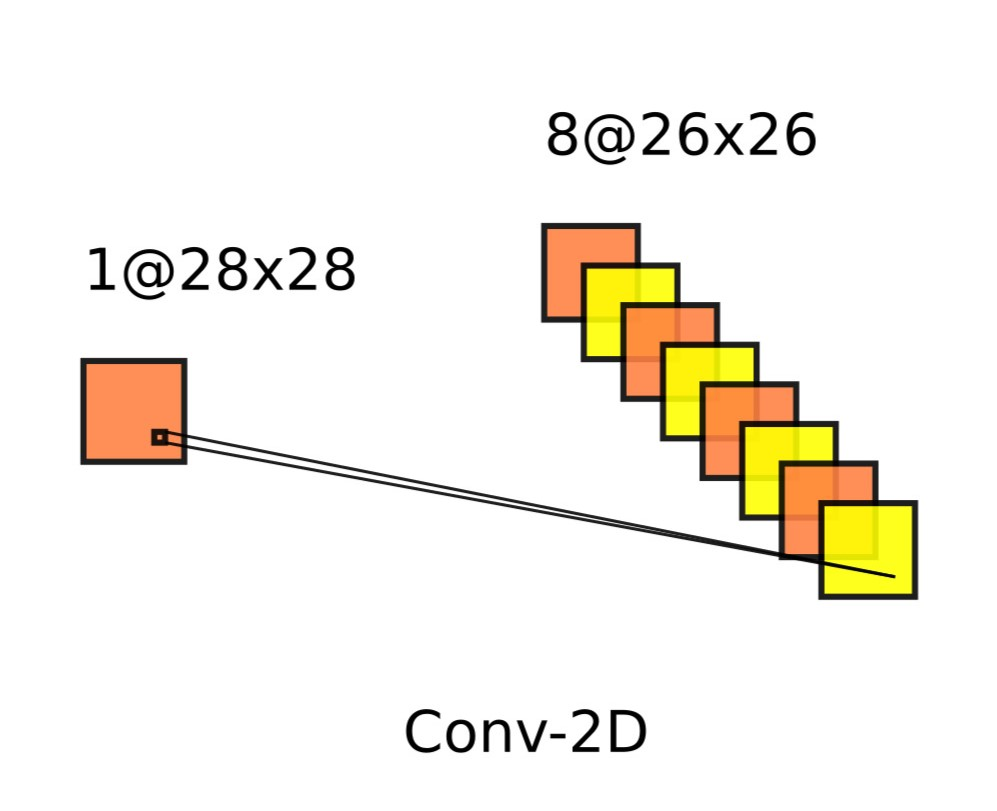

Cada um dos 8 filtros na camada de convolução produz uma saída de 26x26, os quais empilhados formam um volume de 26x26x8. Considerando que os 8 filtros tem dimensão3×3, então o número de pesos será igual à 8 X 9 = 72 ! Isto é muito menos do que se fosse uma camada completamente conectada. 

In [66]:
# ==============================
# Exemplo de Função de convolução
# ==============================

def convolve2d(image, kernel, padding=0, stride=1):
    # Na convolução o filtro pode ser invertido antes de atravessar a imagem, como acontece na integral de convolução. 
    #kernel = np.flipud(np.fliplr(kernel))  # Rotação 180°
    x_k, y_k = kernel.shape
    x_i, y_i = image.shape

    if padding > 0:
        image_padded = np.pad(image, pad_width=padding, mode='constant')
    else:
        image_padded = image
    #determina a dimensão da imagem de saída com base nos valores de padding e stride
    x_o = ((x_i + 2 * padding - x_k) // stride) + 1
    y_o = ((y_i + 2 * padding - y_k) // stride) + 1
    output = np.zeros((x_o, y_o))

    for i in range(0, x_o):
        for j in range(0, y_o):
            region = image_padded[i*stride:i*stride+x_k, j*stride:j*stride+y_k]
            output[i, j] = np.sum(region * kernel)

    return output

In [67]:
import numpy as np

# Imagem de entrada (4x4)
image = np.array([
    [0, 50, 0, 29],
    [0,80, 31, 2],
    [33, 90, 0, 75],
    [0, 9, 0, 95]
])

# Filtro (3x3)
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# Passo 1: Convolução
conv_out = convolve2d(image, kernel, padding=1)
print("\nSaída da Convolução:")
print(conv_out)


Saída da Convolução:
[[ 180.   31. -120.  -31.]
 [ 300.   29. -192.  -62.]
 [ 269.  -35.  -22.  -31.]
 [ 108.  -33.  157.    0.]]


## *Pooling*

Pixels vizinhos em imagens tendem a ter valores semelhantes, portanto, as camadas de convolução normalmente também produzem valores semelhantes para pixels vizinhos nas saídas. Como resultado, grande parte da informação contida na saída de uma camada de convolução é redundante. Por exemplo, se usarmos um filtro de detecção de bordas e encontrarmos uma borda forte em um determinado local, é provável que também encontremos bordas relativamente fortes em locais deslocados de um pixel em relação ao original. No entanto, todas essas bordas se referem a mesma , nâo constituem informação adicional.

Uma camada de *pooling* é um tipo de camada de rede que reduz a resolução e agrega informações dispersas. Sua função principal é remover informações redundantes, reduzindo assim a quantidade de computação e memória necessárias, o que torna o modelo mais robusto à pequenas variações na entrada. Assim as camadas de *pooling* reduzem o tamanho da entrada fornecida agrupando os seus valores. Este agrupamento geralmente é feito por uma operação simples como máximo, mínimo ou média. Quando usamos o máximo, o nome utilizado para esta técnica é *max Pooling*.

Como funciona o *Max Pooling*:

1) Varredura: O *Max Pooling* move uma pequena janela (geralmente 2x2 ou 3x3) sobre o mapa de características de entrada.

2) Seleção: Em cada janela, o *Max Pooling* seleciona o valor máximo. É como escolher a informação mais importante naquela área.

3) Redução de resolução: Após selecionar os valores máximos de todas essas janelas, o *Max Pooling* reduz o tamanho do mapa de características. A imagem fica menor, mas os detalhes essenciais permanecem intactos.

Assim, para realizar o *max pooling*, percorre-se a imagem de entrada em blocos 2x2 (se o tamanho do bloco = 2) e coloca-se o valor máximo na imagem de saída no pixel correspondente.
O *pooling* divide a largura e a altura da entrada pelo tamanho do bloco. Para a rede 28x28, colocaremos uma camada de *max pooling* com um tamanho de bloco  2 logo após a camada de convolução inicial. A camada de *pooling* transformará uma entrada de 26x26x8 em uma saída de 13x13x8:

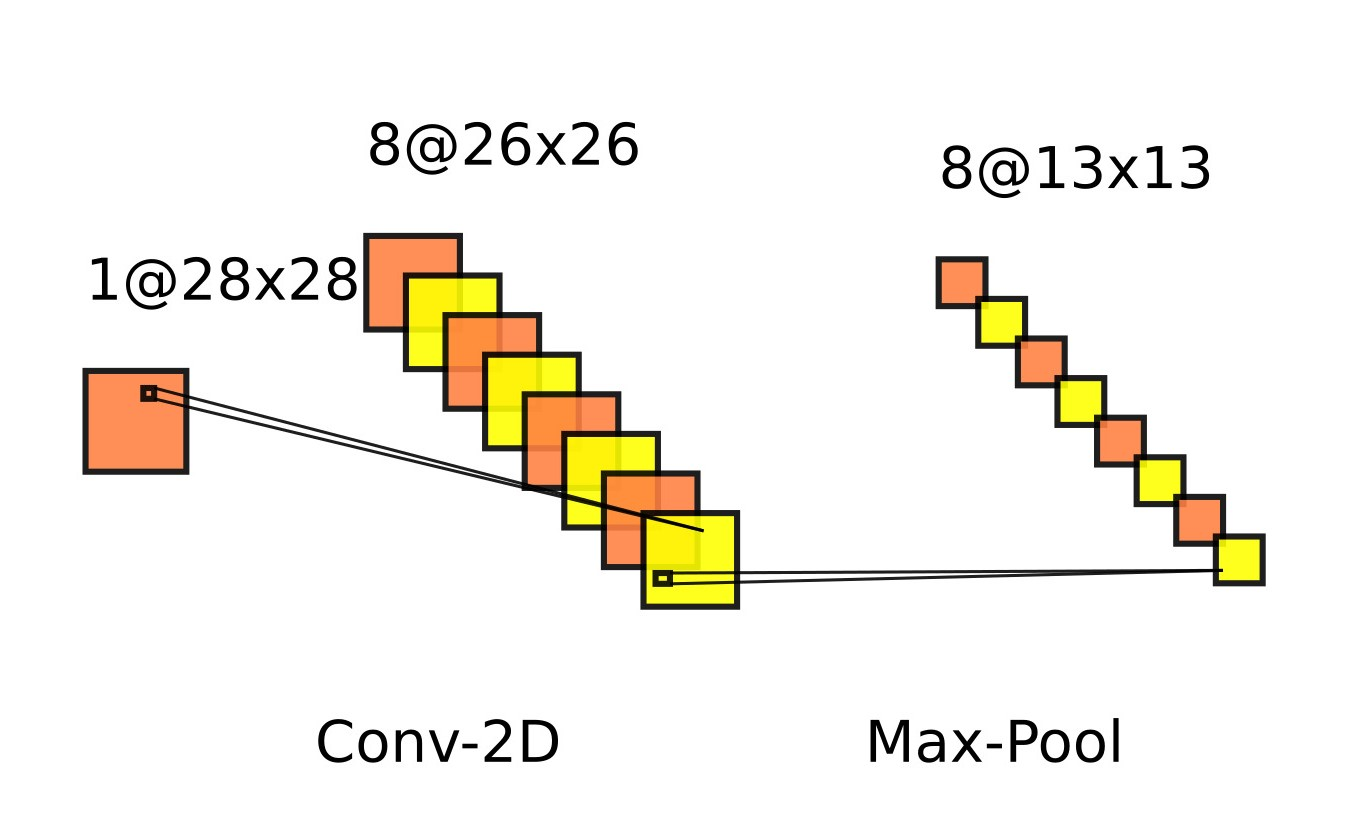

In [68]:
# =======================================
# Max Pooling
# =======================================
def max_pooling(feature_map, size=2, stride=1):
    x_f, y_f = feature_map.shape
    x_o = ((x_f - size) // stride) + 1
    y_o = ((y_f - size) // stride) + 1
    pooled = np.zeros((x_o, y_o))

    for i in range(x_o):
        for j in range(y_o):
            region = feature_map[i*stride:i*stride+size, j*stride:j*stride+size]
            pooled[i, j] = np.max(region)

    return pooled

In [69]:
pool_out = max_pooling(conv_out, size=2, stride=1)
print("\nSaída do Max Pooling:")
print(pool_out)


Saída do Max Pooling:
[[300.  31. -31.]
 [300.  29. -22.]
 [269. 157. 157.]]


**Exemplo de aplicação em reconhecimento de imagens**: a base de dados do MNIST (*Modified National Institute of Standards and Technology database*) é um grande banco de dados de dígitos manuscritos, comumente usado para treinar vários sistemas de processamento de imagens. É o equivalente ao "Olá, Mundo!" (*Hello World*) da visão computacional, onde para uma dada imagem o problema consiste em classificá-la como um dígito específico corretamente.

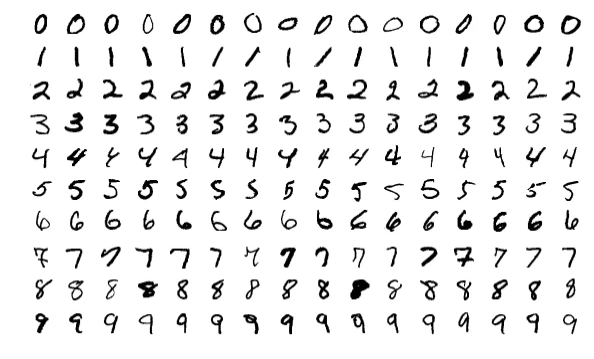

Cada imagem no conjunto de dados MNIST tem 28x28 *pixels* e contém um dígito centralizado em tons de cinza. Os 10 dígitos correspondem a 10 categorias, por tanto uma camada *Softmax* será utilizada nesta aplicação como uma camada de saída com 10 elementos, na qual a função *Softmax* é a função custo (*Lost*). Após a aplicação da transformação *Softmax*, o dígito representado pelo nó com maior probabilidade será a saída da rede.

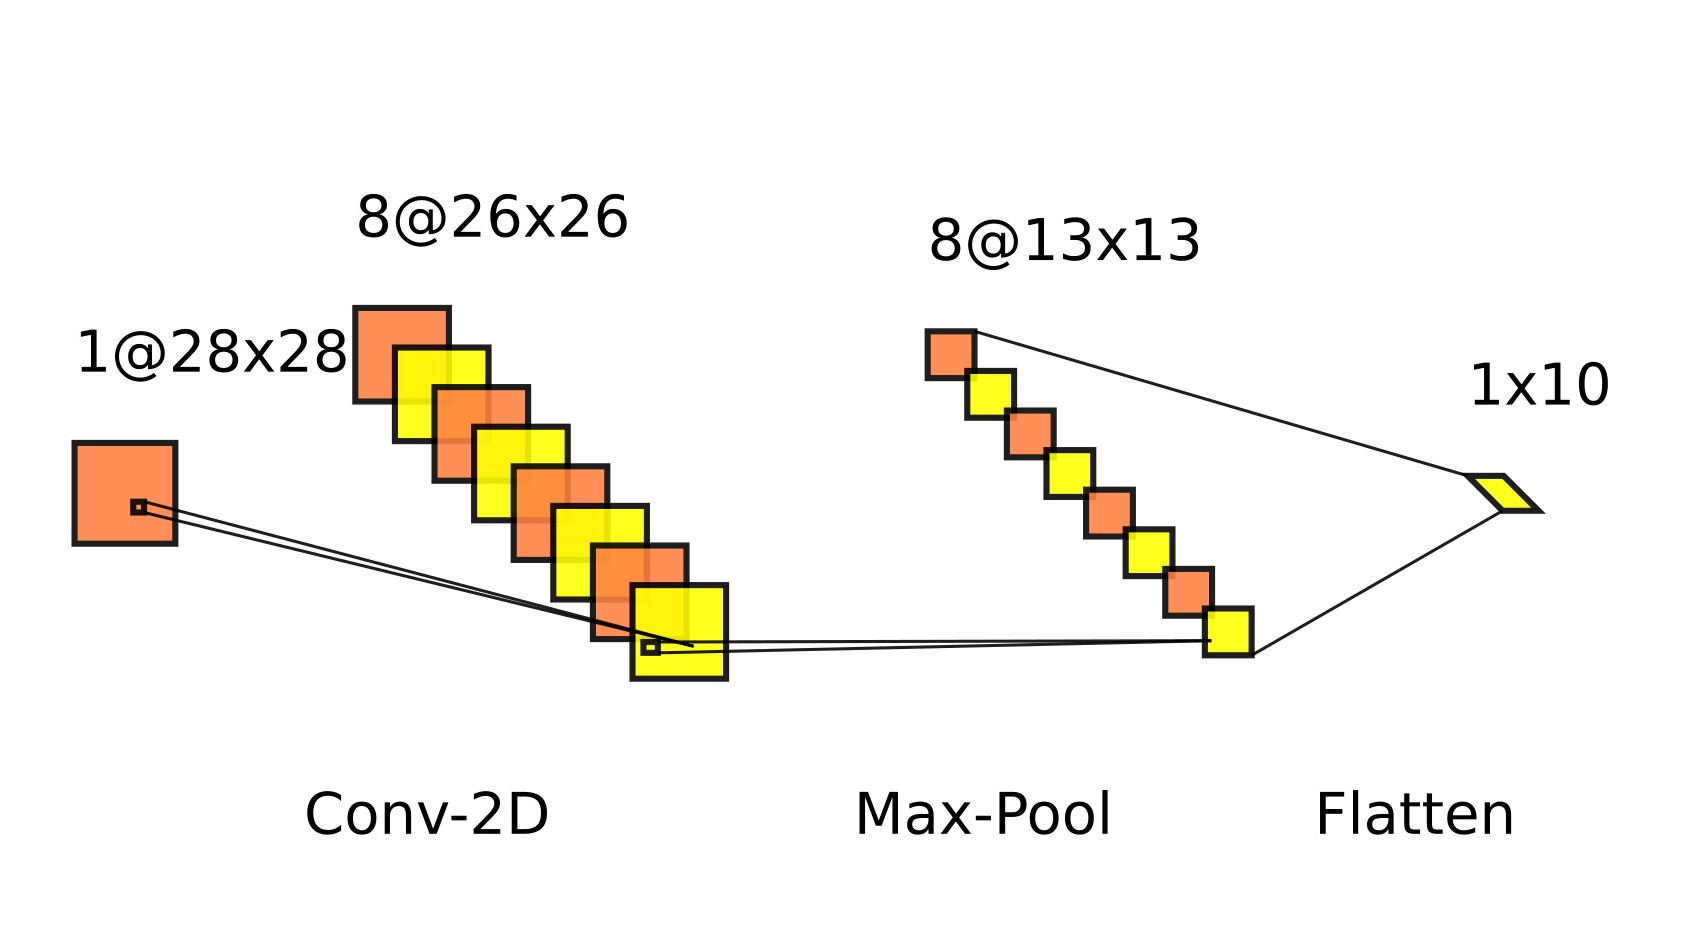

Antes de continuarmos, precisamos estudar algun detalhes sobre a função *Softmax*: 

O objetivo da rede é a classificação de imagens em categorias. A camada final é uma camada padrão para classificação multiclasse totalmente conectada usando a função *Softmax* como ativação. Cada nó na camada será conectado a todas as entradas (saídas da camada de *pooling*). Com a aplicação da função *Softmax*, o dígito representado pelo nó com probabilidade mais alta será a saída da rede. 

$$\hat{y}_c=\frac{e^{z_c}}{\sum_i e^{z_i}}=\frac{e^{z_c}}{S}=e^{z_c}S^{-1}$$

  onde $S=\sum_i e^{z_i}$.

Seja $k\ne c$. A derivada da saída em relação a $z_k$ é

  $$\frac{\partial \hat{y}_c}{\partial z_k} =\frac{\partial \hat{y}_c}{\partial S}\frac{\partial S}{\partial z_k}=-e^{z_c}S^{-2}\frac{\partial S}{\partial z_k}=-\frac{e^{z_c}e^{z_k}}{S^2}$$

  Agora, se $k=c$, a derivada é

  $$\frac{\partial \hat{y}_c}{\partial z_c}=\frac{\partial\left(e^{z_c}S^{-1}\right)}{\partial z_c}=\frac{e^{z_c}}{S}+e^{z_c}\frac{\partial S^{-1}}{\partial z_c}=\frac{e^{z_c}}{S}-\frac{e^{z_c}e^{z_c}}{S^2}=\frac{e^{z_c}(S-e^{z_c})}{S^2}.$$

  portanto,
  
  $$\frac{\partial \hat{y}}{\partial z}=\begin{cases}-\frac{e^{z_c}e^{z_k}}{S^2},& k \ne c \\
\frac{e^{z_c}(S-e^{h_c})}{S^2},& k=c \end{cases}$$

  

## Treinamento

O treinamento de uma rede neural normalmente consiste em duas fases:

* Uma fase *feedforward*, onde a entrada é passada completamente pela rede. Na saída de *Softmax* o elemento com maior probabilidade é comparado com o label correto, testando a acurácia.
* Uma fase de *backpropagation*, onde os gradientes são retropropagados e os pesos são atualizados.

Durante a fase de avanço, cada camada armazenará em cache quaisquer dados (como entradas, valores intermediários, etc.) necessários para a fase de retropropagação. Isso significa que qualquer fase de retropropagação deve ser precedida por uma fase de avanço correspondente. Na saída da camada de *pooling* os dados são "achatados" na forma de um *array* unidimensional (em *numpy* usa-se a função *flatten()*), e então encaminhados para o cálculo das probabilidades pela camada *Softmax*. 


Durante a fase de retropropagação, na camada de saída é calculado um gradiente da perda em relação às suas saídas ($\frac{\partial L}{\partial \hat{y}_c}​$) e  o gradiente de perda em relação às suas entradas ($\frac{\partial L}{\partial h}​​$). A função de perdas é a função denominada como *Cross-Entropy Loss*, a qual considera o o grau de certeza uma dada previsão é simplesmente definida como
$$L=-\ln(p_c)$$

onde *c* é a classe correta (no nosso caso, o dígito correto), $p_c=\hat{y}_c$ é a probabilidade prevista para a classe *c* e $\ln$ é o logaritmo natural. Note que para $\hat{y}_c=1$, $L=0$, enquanto que para um valor como $\hat{y}_c=0.4$, $L=0.9$. Portanto, quanto menor o valor da perda melhor a probabilidade de ser a saída correta. 

* Feedforward

    out=conv.feedforward(image)

    out=pool.feedforward(out)

    out=softmax.feedforward(out)

* Cálculo dos gradientes

    ......
  
    ......

* backpropagation
  
    gradient=softmax.backprop(gradient)
  
    gradient=pool.backprop(gradient)
  
    gradient=conv.backprop(gradient)

No início do treino, cada imagem é testada com seu verdadeiro *label*, se a base de dados é **MNIST**, o verdadeiro dígito. Isso significa que apenas um dos 10 elementos do *array* corresponderá ao ao dígito $y_c$. Portanto o gradiente inicial é

$$\frac{\partial L}{\partial \hat{y}_i}=\begin{cases}0,& i \ne c \\
-\frac{1}{p_i},& i=c \end{cases}$$

ou seja, o vetor de gradientes será um vetor nulo com $-\frac{1}{p_c}$ ná posição do *label* correto, semelhante à um vetor *one-hot*. 

Na camada de saída, para cada neurônio $z=w*h_{in}+b$, portanto, os gradientes são:

  $$\frac{\partial z}{\partial w}=h_{in};$$
  $$\frac{\partial z}{\partial b}=1;$$
  $$\frac{\partial z}{\partial h_{in}}=\omega,$$

  e finalmente,

  $$\frac{\partial L}{\partial \omega}=\frac{\partial L}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial z}\frac{\partial z}{\partial \omega}$$
  $$\frac{\partial L}{\partial b}=\frac{\partial L}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial z}\frac{\partial z}{\partial b}$$
  $$\frac{\partial L}{\partial h_{in}}=\frac{\partial L}{\partial\hat{y} }\frac{\partial \hat{y}}{\partial z}\frac{\partial z}{\partial h_{in}}$$

  * *Pooling*

Uma camada *Max Pooling*  não pode ser treinada porque na verdade não tem nenhum peso, mas ainda é necessário implementar um método *backprop()* para que ela calcule gradientes.
Durante o *feedforward*, a camada *pooling* recebe um volume de entrada e reduz pela metade suas dimensões de largura e altura, escolhendo os valores máximos ( para *maxpooling*) em blocos 2x2. Na retropropagação a largura e a altura do gradiente de perda são dobradas, atribuindo cada valor de gradiente ao local onde o valor máximo original estava em seu bloco 2x2 correspondente. Todos os outros valores são mantidos nulos. O motivo é que um pixel de entrada que não é o valor máximo em seu bloco 2x2 não tem efeito na perda, porque alterar ligeiramente esse valor não altera a saída.

* Camada *Conv*

Já calculamos $\frac{\partial L}{\partial \hat{y}}​$ para a camada de convolução, então precisamos apenas de $\frac{\partial \hat{y}}{\partial filter}$. ​Assim, precisamos saber como a alteração do peso de um filtro afeta a saída da camada de convolução. Vamos considerar um exemplo no qual uma imagem 3x3 convoluída por um filtro 3x3 contendo inicialmente apenas zeros. 

Se o peso no centro do filtro for alterado para 1, o resultado é o aumento do resultado da  convolução  pelo valor do pixel na imagem original. O mesmo se dará pelo aumento dos pesos em qualquer outro local no filtro. 

Assim, podemos escrever

$$\hat{y}(i,j)=imagem*filtro=\sum_{k=0}^3 \sum_{l=0} ^3 imagem(i+k,j+l)\times filtro(k,l)\rightarrow \frac{\partial \hat{y}(i,j)}{\partial filtro(k,l)}=imagem(i+k,j+l)$$ 
 e portanto

 $$\frac{\partial L}{\partial filtro(k,l)}=\sum_i\sum_j\frac{\partial L}{{\partial \hat{y}(i,j)}} \times \frac{\partial \hat{y} (i,j)}{\partial filtro(k,l)}$$



In [70]:
class Conv3x3:
  # ...

  def backprop(self, d_L_d_out, learn_rate):
    
    d_L_d_filters = np.zeros(self.filters.shape)

    for im_region, i, j in self.iterate_regions(self.last_input):
      for f in range(self.num_filters):
        d_L_d_filters[f] += d_L_d_out[i, j, f] * im_region

    # Update filters
    self.filters -= learn_rate * d_L_d_filters
    return None

## Implementação com Keras

Uma rede CNN é implementada abaixo com a biblioteca Keras, com a base de dados MNIST. Cada imagem tem pixels com valores inteiros de 0 a 255 (8 bits), portanto os dados de treino e teste serão normalizados de forma a terem seus valores no intervalo [0,1]. Além disso, reduzindo 0,5 do intervalo resulta em um novo intervalo centrado em zero, [-0.5,0.5]. Centrar os dados facilita o aprendizado com gradientes mais estáveis e funciona melhor com as funções de ativação. Faremos um primeiro teste com a configuração padrão de uma camada convolucional 2D, uma camada *MaxPooling* e uma camada densa de 10 elementos/categorias. Também são usados 8 filtros 3 X 3. 

In [1]:
import numpy as np
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from keras.utils import to_categorical

(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()


# Normalização das imagens.
train_images = (train_images / 255) - 0.5 # normalização e centragem
test_images = (test_images / 255) - 0.5   ## normalização e centragem

# Acrescenta uma dimensâo às imagens.
train_images = np.expand_dims(train_images, axis=3)
test_images = np.expand_dims(test_images, axis=3)

num_filters = 8
filter_size = 3
pool_size = 2
input_shape=(28, 28, 1)

# Build the model.
model = Sequential([
  keras.Input(shape=input_shape),
  Conv2D(num_filters, filter_size, activation = 'relu',use_bias=False),
  MaxPooling2D(pool_size=pool_size),
  Flatten(),
  Dense(10, activation='softmax'),
])

model.summary()

# Compila o modelo.
model.compile(
  'adam',
  loss='categorical_crossentropy',
  metrics=['accuracy'],
)

# treina o modelo.
model.fit(
  train_images,
  to_categorical(train_labels),
  epochs=15,
  validation_data=(test_images, to_categorical(test_labels)),
)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Avell\Desktop\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Avell\Desktop\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\traitlets\config\application.py", line 1080, in launch_instance
    app.start()
  File "C:\Users\Avell\Desktop\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\ipykernel\kernelapp.py", 

AttributeError: _ARRAY_API not found

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 8)           │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1352)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │          13,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,602 (53.13 KB)

 Trainable params: 13,602 (53.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8516 - loss: 0.5734 - val_accuracy: 0.9676 - val_loss: 0.1179
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9691 - loss: 0.1082 - val_accuracy: 0.9740 - val_loss: 0.0844
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9778 - loss: 0.0788 - val_accuracy: 0.9773 - val_loss: 0.0712
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9824 - loss: 0.0621 - val_accuracy: 0.9781 - val_loss: 0.0698
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9836 - loss: 0.0556 - val_accuracy: 0.9798 - val_loss: 0.0623
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9847 - loss: 0.0499 - val_accuracy: 0.9806 - val_loss: 0.0633
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9856 - loss: 0.0484 - val_accuracy: 0.9787 - val_loss: 0.0685
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9868 - loss: 0.0437 - 

In [72]:
score = model.evaluate(test_images, to_categorical(test_labels), verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])


Test loss: 0.07834874093532562
Test accuracy: 0.9789000153541565


Para um total de 13602 parâmetros a rede atingiu uma acurácia de aproximadamente 98%. O aumento do número de épocas não muda consideravelmente este resultado.  Portanto, podemos testar uma segunda configuração com uma camada de convolução de 32 filtros na sequência da camada de entrada, seguida pela camada *Maxpooling*, por uma nova camada de convolução, desta vez com 64 filtros, *MaxPooling*, *Flatten* e finalmente a camada densa de 10 categorias. 

In [73]:
from keras.layers import Dropout
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        Conv2D(32, kernel_size=(3, 3), activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, kernel_size=(3, 3), activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dropout(0.5),
        Dense(10, activation="softmax"),
    ]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │          16,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
batch_size = 128
epochs = 15

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(train_images, to_categorical(train_labels), batch_size=batch_size, epochs=epochs, validation_split=0.1,verbose=1)

score = model.evaluate(test_images, to_categorical(test_labels), verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])


Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7548 - loss: 0.8070 - val_accuracy: 0.9773 - val_loss: 0.0815
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9636 - loss: 0.1184 - val_accuracy: 0.9838 - val_loss: 0.0611
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9745 - loss: 0.0848 - val_accuracy: 0.9863 - val_loss: 0.0506
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9788 - loss: 0.0690 - val_accuracy: 0.9883 - val_loss: 0.0450
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9811 - loss: 0.0604 - val_accuracy: 0.9905 - val_loss: 0.0382
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9823 - loss: 0.0539 - val_accuracy: 0.9902 - val_loss: 0.0394
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9842 - loss: 0.0493 - val_accuracy: 0.9905 - val_loss: 0.0377
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9854 - loss: 0.0469 - val_accu

Desta vez, com 34826 parâmetros atingiu-se 99% de acurácia.  Agora vamos fazer uma comparação das redes anteriores com uma rede padrão, para fazer a mesma identificação. Usaremos duas camadas ocultas, de 50 e 25 neurõnios, densamente conectados.

In [75]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten

(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()
# Normalização das imagens.
train_images = (train_images / 255) - 0.5 # normalização e centragem
test_images = (test_images / 255) - 0.5   ## normalização e centragem


model = Sequential(
    [   Input((28,28)), 
        Flatten(),
        Dense(50, activation="relu", name="layer1"),
        Dense(25, activation="relu", name="layer2"),
        Dense(10, activation="softmax"),
    ]
)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

model.fit(x=train_images, y=train_labels, epochs=15, validation_split=0.2)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer1 (Dense)                       │ (None, 50)                  │          39,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer2 (Dense)                       │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,785 (159.32 KB)

 Trainable params: 40,785 (159.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7674 - loss: 0.7572 - val_accuracy: 0.9212 - val_loss: 0.2604
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9191 - loss: 0.2652 - val_accuracy: 0.9404 - val_loss: 0.2055
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9383 - loss: 0.2053 - val_accuracy: 0.9497 - val_loss: 0.1769
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9479 - loss: 0.1701 - val_accuracy: 0.9548 - val_loss: 0.1630
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9545 - loss: 0.1495 - val_accuracy: 0.9562 - val_loss: 0.1526
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9605 - loss: 0.1322 - val_accuracy: 0.9575 - val_loss: 0.1489
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9643 - loss: 0.1187 - val_accuracy: 0.9588 - val_loss: 0.1471
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9665 - loss: 0.1097 - 

In [76]:
score = model.evaluate(test_images, test_labels, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.13387438654899597
Test accuracy: 0.9645000100135803


Como pode ser visto nos resultados, a rede "padrão" com um número de pesos maior do que 2 vezes o número de pesos usados pela CNN atingiu aproximadamente a mesma acurácia. Além disso, o número de pesos é consideravelmente maior do que a CNN que obteve 99% de acurácia.

### Referências
[1] https://victorzhou.com/blog/intro-to-cnns-part-1/

[2] https://www.geeksforgeeks.org/building-a-convolutional-neural-network-using-pytorch/

[3] https://keras.io/examples/vision/mnist_convnet/

[4]https://medium.com/@techwithjulles/convolutional-neural-networks-cnns-for-time-series-data-experimenting-with-different-e2dcd9fc76ba

[5] Serkan Kiranyaz,Onur Avci, Osama Abdeljaber, Turker Ince, Moncef Gabbouj, Daniel J. Inman: 1D convolutional neural networks and applications: A survey , Mechanical Systems and Signal Processing, 2021.

[6] https://keras.io/api/layers/convolution_layers/convolution2d/

[6] Matheus Bona, Aplicação de Redes Neurais Artificiais na Localização de Faltas em Linhas de Transmissão, Dissertação de Mestrado, Furb, setembro, 2021.


# Redes Neurais Recorrentes (RNN)

Normalmente, quando trabalhamos com redes neurais, recebemos um vetor de entrada de tamanho fixo,  que é processado por algumas camadas ocultas, produzindo um vetor de saída de tamanho fixo como é o caso das Redes Densas padrão ou das CNN que estudamos. Enquanto as Redes Neurais "padrão" recebem uma única entrada e produzem um único rótulo para essa estrada, existem tarefas em que o modelo produz uma sequência de saídas, como em geração de texto ou tradução, e o número de entradas pode não ser fixo, além de estarem fortemente correlacionadas. CNNs processam bem entradas correlacionadas, como imagens, por exemplo, mas o número de entradas (o número de *pixels* representando a imagem) é fixado. As Redes Neurais Recorrentes permitem operar sobre sequências de entrada, saída ou ambas simultaneamente.

Os tipos de RNN podem ser:
* uma entrada, uma saída. Este é o tipo mais simples de Redes Recorrentes e é usado para tarefas de classificação binária no qual não há uma natureza sequencial nos dados de entrada.
* Uma antrada, Múltiplas saídas. neste tipo de RNN, a rede processa uma única entrada para produzir múltiplas saídas ao longo do tempo. Isso é útil em tarefas onde uma entrada desencadeia uma sequência de previsões (saídas). Por exemplo, na criação de legendas para imagens, uma única imagem pode ser usada como entrada para gerar uma sequência de palavras como legenda.
* Muitas Entradas, Uma saída. Esse tipo é útil quando o contexto geral da sequência de entrada é necessário para fazer uma única previsão. Na análise de sentimentos, o modelo recebe uma sequência de palavras (como uma frase) e produz uma única saída, como positiva, negativa ou neutra.
* Muitas Entradas, Muitas Saídas. Esta rede Processa uma sequência de entradas e gera uma sequência de saídas. Na tarefa de tradução de idiomas, uma sequência de palavras em um idioma é fornecida como entrada e uma sequência correspondente em outro idioma é gerada como saída.
* 
  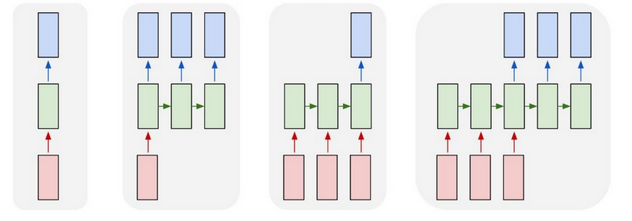
  
  Fonte: CS231n: Deep Learning for Computer Vision em https://cs231n.github.io/rnn/
  
  Comparativamente às Redes Convolucionais (CNNs), estas últimas são insuficientes para lidar com tarefas que possuem entradas e saídas com comprimentos de sequência variáveis. No exemplo de legendagem de vídeos, as entradas têm um número variável de quadros (por exemplo, vídeos de 10 minutos e 10 horas de duração) e as saídas são legendas de comprimento variável. As redes convolucionais só podem receber entradas com tamanho fixo de largura e altura e não conseguem generalizar para entradas com tamanhos diferentes. Para solucionar esse problema, são utilizadas as Redes Neurais Recorrentes (RNNs).

  Basicamente, uma RNN é uma caixa preta, que possui um "estado interno" o qual é atualizado à medida que uma sequência é processada. A cada passo de tempo, a rede pode ser considerada como uma rede *feedforward* padrão , ou seja, densamente conectada, mas com uma conexão adicional vinda do estado oculto anterior. Desta forma, esta rede modifica seu estado em função suas entradas e dos estados anteriores.

  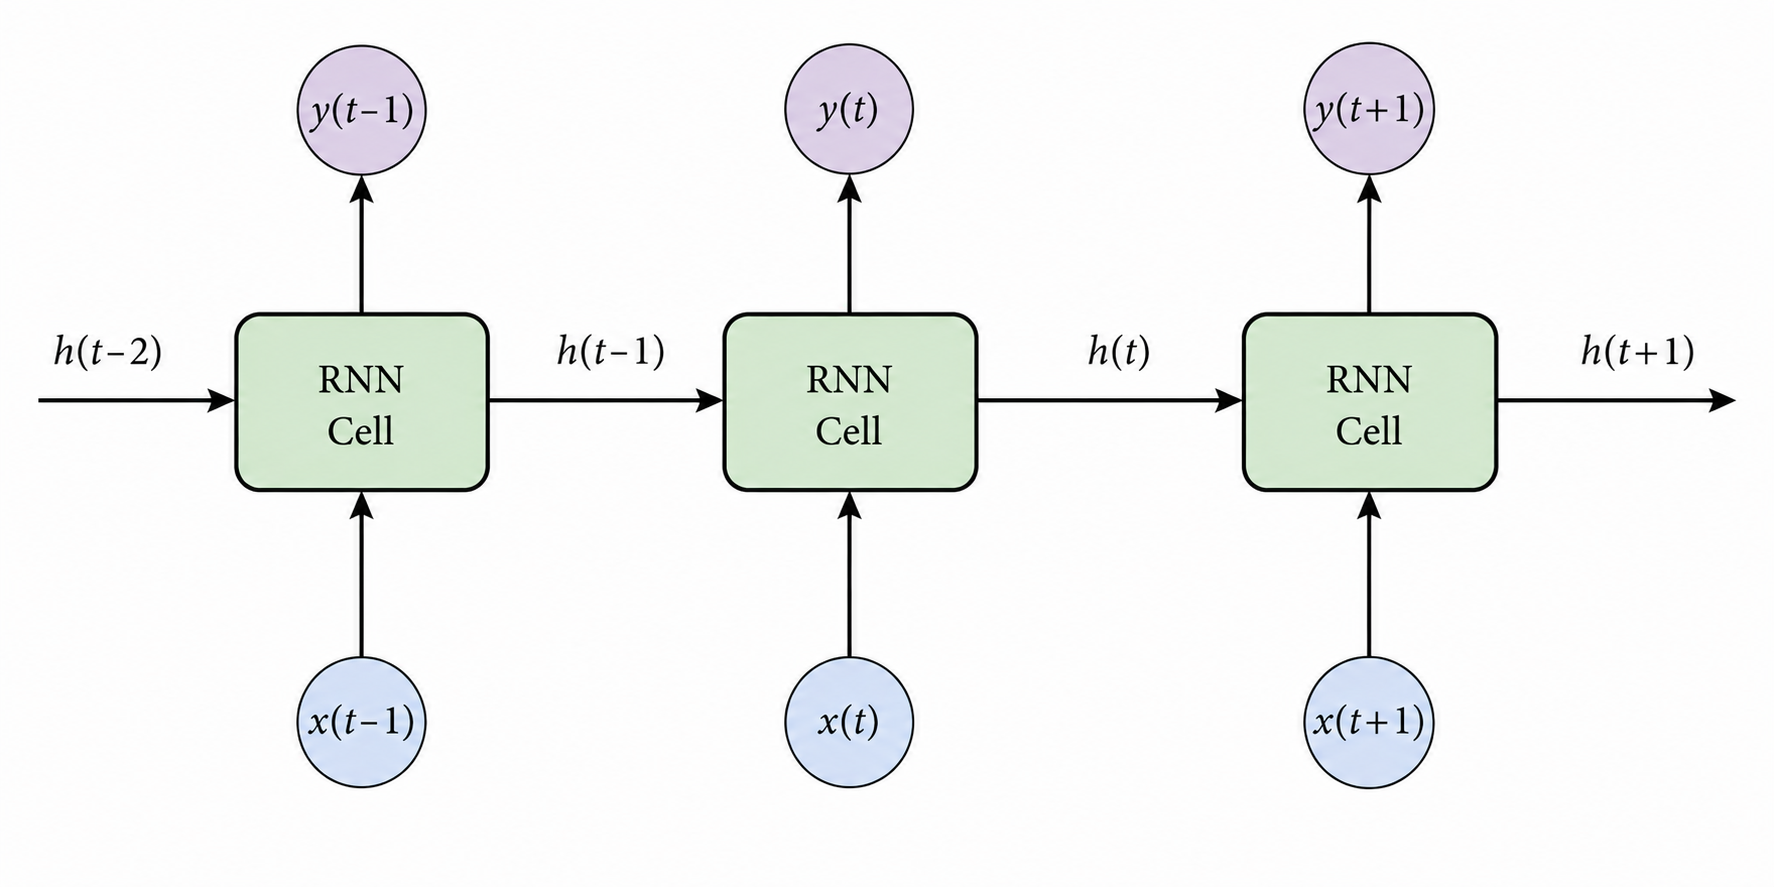
  Fonte: Gerado com ChatGPT.


 O aprendizado é realizado com a  retropropagação no tempo (BPTT), um processo  no qual os erros são propagados ao longo dos intervalos de tempo para ajustar os pesos da rede, aprimorando a capacidade da RNN de aprender dependências em dados sequenciais. Ao ajustarmos os pesos da RNN, ela apresentará comportamentos diferentes em termos de como seu estado evolui conforme recebe essas entradas. É importante frisar que o conjunto de pesos é o mesmo para todos os instantes de tempo e estados associados. 

As RNNs compartilham semelhanças nas estruturas de entrada e saída com outras arquiteturas de redes neurais, mas diferem significativamente na forma como a informação flui da entrada para a saída. Ao contrário das redes neurais profundas tradicionais, onde cada camada densa possui matrizes de pesos distintas, as RNNs utilizam pesos compartilhados ao longo do tempo, permitindo que elas retenham informações sobre as sequências.

Em RNNs, o estado interno $h_t$ é o estado no tempo corrente e é calculado para cada entrada $x_t$, retendo dependências sequenciais. 
            

A cada passo de tempo, as RNNs processam unidades com uma função de ativação fixa. O estado oculto interno atua como memória, retendo informações de passos de tempo anteriores. Essa memória permite que a rede armazene conhecimento passado e se adapte com base em novas entradas.

$$h_t=f_a(w_{hh}h_{t-1}+w_{xh}x_t)$$
onde $f_a$ é a função de ativação, normalmente *tanh*, $w_{hh}$ e $w_{xh}$ são matrizes de pesos e $h_{t-1}$ é o estado anterior..

$$\hat{y}=f_o(z)=f_o(w_{hy}h_n+b_y)$$

onde $h_n$ é o estado final fluindo para a saída da rede e $f_o$ é a função de ativação na saída.

Os pesos são atualizados usando uma técnica conhecida como **Retropropagação Pelo Tempo (BPTT)**. A função de Perdas $L$ depende do estado final e dos anteriores, formando uma cadeia de dependência sequencial na qual $h_n$ depende de $h_{n-1}$, que depende de $h_{n-2}$ e  desta forma até  $h_0$.  Assim,  na BPTT, os gradientes são calculados através de cada passo no tempo. Inicialmente, usando  diferenciação por partes, são calculados os gradientes para o estado final $h_n$:

$$\frac{\partial L}{\partial w_{hy}}=\frac{\partial L}{\partial z}\frac{\partial z}{\partial w_{hy}}$$

Logo, 
$$\frac{\partial z}{\partial w_{hy}}=h_n,$$

$$\frac{\partial L}{\partial w_{hy}}=\frac{\partial L}{\partial z}h_n.$$

Além disso, $\frac{\partial z}{\partial b_y}=1$, e $\frac{\partial L}{\partial b_y}=\frac{\partial L}{\partial z}$.

Precisamos agora da derivada de *L* relativa à $\hat{y}$: Para simplificar a dedução desta derivada, consideraremos duas saídas, $\hat{y}_c$ e $\hat{y}_n$. Supondo que a função de ativação  na saída é a função *Softmax*, temos:
$$\hat{y}_c=p_c=\frac{e^{z_c}}{e^{z_c}+e^{z_n}}=\frac{e^{z_c}}{sum},$$

e supondo ainda que a funçao de perdas utilizada é *cross-entropy* , $L=-ln(p_c)$,  
$$L=-ln(e^{z_c})+ln(sum)=-z_c+ln(sum)\rightarrow \frac{\partial L}{\partial z_c}=-1+\frac{\partial \;ln(sum)}{\partial z_c}=-1+\frac{1}{sum}e^{z_c}=\frac{e^{z_c}}{e^{z_c}+e^{z_n}}-1=p_c-1$$

Por outro lado, 
$$\frac{\partial L}{\partial z_n}=\frac{\partial\;ln(sum)}{\partial z_n}=\frac{1}{sum}e^{z_n}=p_n.$$

Portanto, temos como resultado que:

 $$\frac{\partial L}{\partial z_i}=\begin{cases}p_i,& i \ne c \\
p_i-1,& i=c \end{cases}.$$

Na sequência, determinamos os gradientes $w_{hh},w_{xh}\;\text{e}\;b_h$ e para tanto teremos que fazer a retropropagação através de todos os passos de tempo, ou seja BPTT. 

Assim,
$$\frac{\partial L}{\partial w_{xh}}=\frac{\partial L}{\partial z}\sum_t^{t_n} \frac{\partial z}{\partial h_t}\frac{\partial h_t}{\partial w_{xh}},$$

onde $t_n$ é o instante final correspondendo ao último estado oculto. Em um tempo dado *t*, precisamos calcular $\frac{\partial h_t}{\partial w_{xh}}$:

$$h_t=tanh(w_{xh}x_t+w_{hh}h_{t-1}+b_h).$$

Mas a derivada da tangente hiperbólica é $\frac{\partial \,tanh(x)}{\partial x}=1-tanh^2(x)$. Portanto, seguindo a regra da cadeia, temos que

$$\frac{\partial h_t}{\partial w_{xh}}=\frac{\partial h_t}{\partial z}\frac{\partial z}{\partial w_{xh}}=(1-tanh^2(z))x_t=(1-h_t^2)x_t,$$

onde $z=w_{xh}x_t+w_{hh}h_{t-1}+b_h$.

Da mesma forma, 

$$\frac{\partial h_t}{\partial w_{hh}}=(1-h_t^2)h_{t-1},\;\text{e}$$
$$\frac{\partial h_t}{\partial b_h}=(1-h_t^2).$$

Finalmente, precisamos calcular $\frac{\partial z}{\partial h_t}$, e isso será feito de forma recursiva. Inicialmente, para o último estado oculto temos 
$$\frac{\partial z}{\partial h_{t_n}}=w_{hy},$$
 e assim, retropropagando para os estados anteriores (levando em consideração que o estado $h_t$ contribui para o estado futuro $h_{t+1}$), 
$$\frac{\partial z}{\partial h_t}=\frac{\partial z}{\partial h_{t+1}}\frac{\partial h_{t+1}}{\partial h_t}=\frac{\partial z}{\partial h_{t+1}}(1-h_t^2)w_{hh}.$$





Como primeiro exemplo uma RNN bastante simples é implementada apenas usando *numpy* e é usada para identificação de sentimentos positivo/negativo expressos em sequências de palavras.
O primeiro passo é a construção de uma base de dados e *labels* para treino e teste da rede:

In [77]:
from tqdm import tqdm
import numpy as np

##### Data #####
train_X = ['bom', 'bem', 'ruim', 'feliz', 'triste', 'não bom', 'não ruim',
       'não feliz', 'não triste', 'muito bom', 'muito ruim',
       'muito feliz', 'muito triste', 'eu estou feliz', 'isto é bom',
       'eu estou ruim', 'isto é ruim', 'eu estou triste', 'isto é triste',
       'eu não estou feliz', 'isto não é bom', 'eu não estou ruim',
       'isto não é triste', 'eu estou muito feliz', 'isto é muito bom',
       'eu estou muito ruim', 'isto é muito triste', 'isto é muito feliz',
       'eu estou bem não ruim', 'isto é bom não ruim',
       'eu estou ruim não bem', 'eu estou bem e feliz',
       'isto não é bom e não é feliz', 'eu não estou nada bem',
       'eu não estou nada ruim', 'eu não estou nada feliz',
       'isto não é nada triste', 'isto não é nada feliz',
       'eu estou bem agora', 'eu estou ruim agora',
       'isto está ruim agora', 'eu estou triste agora',
       'eu estava bem antes', 'eu estava feliz antes',
       'eu estava ruim antes', 'eu estava triste antes',
       'eu estou muito ruim agora', 'isto está muito bom agora',
       'isto está muito triste agora', 'isto estava ruim antes',
       'isto estava muito bom antes', 'isto estava muito ruim antes',
       'isto estava muito feliz antes', 'isto estava muito triste antes',
       'eu estava bem e não ruim antes',
       'eu não estava bem e não estava feliz antes',
       'eu não estou nada ruim ou triste agora',
       'eu não estou nada bem ou feliz agora',
       'isto não estava feliz e nem bom antes',
       'isto não é feliz',
       ]
train_y = [1, 1,0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 
           1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 
           1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,0]

test_X = [
    'isto é feliz',
    'eu estou bem',
    'eu não estou bem',
    'isto não é ruim',
    'eu não estou triste',
    'eu estou muito bem',
    'isto é muito ruim',
    'eu estou muito triste',
    'isto é ruim não bom',
    'isto é bom e feliz',
    'eu não estou bem e não estou feliz',
    'eu não estou nada triste',
    'isto não é nada bom',
    'isto não é nada ruim',
    'isto está bom agora',
    'isto está triste agora',
    'isto está muito ruim agora',
    'isto estava bom antes',
    'eu não estava feliz e não estava bem antes'
]
test_y = [1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0]

Em seguida, o conjunto de treino é tranformado em um conjunto de palavras únicas constituindo o vocabulário que será usado como entrada da rede. Além disso, o dicionário *word_to_index* atribui à cada palavra do vocabulário um índice numérico inteiro:

In [78]:
vocab = set([q for text in train_X for q in text.split()])
vocab_size = len(vocab)

word_to_index = {w:i for i, w in enumerate(vocab)}
print(word_to_index)

{'antes': 0, 'triste': 1, 'nada': 2, 'muito': 3, 'isto': 4, 'é': 5, 'bom': 6, 'está': 7, 'ou': 8, 'eu': 9, 'estou': 10, 'ruim': 11, 'e': 12, 'bem': 13, 'nem': 14, 'agora': 15, 'feliz': 16, 'estava': 17, 'não': 18}


A função *oneHotEncode ()* codifica cada palavra em uma sequência de entrada como vetor  nulo de tamanho igual ao vocabulário, mas com "1" na posição ocupada pela palavra específica. 

In [79]:
def oneHotEncode(text):
    inputs = []
    for q in text.split():
        vector = np.zeros((1, vocab_size))
        vector[0][word_to_index[q]] = 1
        inputs += [vector]

    return inputs

In [80]:
print(oneHotEncode('isto é feliz'))

[array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]]), array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]]), array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0.]])]


A inicialização de Xavier é uma técnica usada para inicializar os pesos de uma rede neural, mitigando o problema do desaparecimento e/ou explosão de gradientes que podem dificultar o treinamento de redes neurais profundas.

In [81]:
def initWeights(input_size, output_size):
    return np.random.uniform(-1, 1, (input_size, output_size)) * np.sqrt(6 / (input_size + output_size))

Finalmente, as rotinas seguintes implementam a função de ativação, sua derivada e a função *Softmax*. Isto conclui a fase de pré-processamento.

In [82]:
def activation_function(input, derivative = False):
    if derivative:
        return 1 - (input ** 2)
    
    return np.tanh(input)

def softmax(input):
    return np.exp(input) / np.sum(np.exp(input))

A classe RNN implementa as equações vistas anteriormente nas fases de avanço e retropropagação. Esta rede terá 19 entradas (o comprimento de cada *one hot vector*), uma camada oculta com dimensão de 64 neurônios) e duas saídas (positivo e negativo). São 64x19=1216  pesos de entrada/camada oculta, 64x64=4096 pesos camada oculta/camada oculta, 64 *bias* da camada oculta, 2x64=128 pesos na camada oculta/saída e duas *bias * de saída, totalizando 50506 pesos treináveis.

In [83]:
class RNN:
    def __init__(self, input_size, hidden_size, output_size, num_epochs, learning_rate):
        # Hyperparameters
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        
        # Network
        self.wxh = initWeights(input_size, hidden_size)
        self.whh = initWeights(hidden_size, hidden_size)
        self.why = initWeights(hidden_size, output_size)

        self.bh = np.zeros((1, hidden_size))
        self.by = np.zeros((1, output_size))

    # Forward Propogation
    def forward(self, inputs):
        self.hidden_states = [np.zeros_like(self.bh)]

        for input in inputs:
            out=np.dot(input, self.wxh)+np.dot(self.hidden_states[-1], self.whh)
            + self.bh
            self.hidden_states += [activation_function(out)]
        return np.dot(self.hidden_states[-1], self.why) + self.by

    # Backward Propogation
    def backward(self, dL_dy, input):
        d_by= dL_dy
        d_why = np.dot(self.hidden_states[-1].T, dL_dy)

        d_bh = np.zeros_like(self.bh)
        d_whh= np.zeros_like(self.whh)
        d_wxh = np.zeros_like(self.wxh)
        
       #dL_dhidden_state for the last hidden state:
        d_hidden_state = np.dot(dL_dy, self.why.T)
        
        #Backpropagation Through Time         
        for t in reversed(range(len(input))):
            
            # dL_dh(t)=dL_dh(t+1)*dh(t+1)_dh(t)
            d_hidden_state *= activation_function(self.hidden_states[t + 1], 
                                                  derivative = True)

            d_bh += d_hidden_state

            d_whh += np.dot(self.hidden_states[t].T, d_hidden_state)

            d_wxh += np.dot(input[t].T, d_hidden_state)

            d_hidden_state = np.dot(d_hidden_state, self.whh)

        for d_ in (d_by, d_wxh, d_bh, d_whh, d_wxh):
            np.clip(d_, -1, 1, out = d_)

        self.by -= self.learning_rate * d_by
        self.why -= self.learning_rate * d_why
        self.bh -= self.learning_rate * d_bh
        self.whh -= self.learning_rate * d_whh
        self.wxh -= self.learning_rate * d_wxh

    # Train
    def train(self, inputs, labels):
        for _ in tqdm(range(self.num_epochs)):
            for input, label in zip(inputs, labels):
                input = oneHotEncode(input)

                prediction = self.forward(input)

                dL_dy = softmax(prediction)

                dL_dy[0][label] -= 1

                self.backward(dL_dy, input)

    # Test
    def test(self, inputs, labels):
        accuracy = 0
        for input, label in zip(inputs, labels):
            print("\n"+input)

            input = oneHotEncode(input)
            prediction =softmax( self.forward(input))

            print(['Negativo', 'Positivo'][np.argmax(prediction)], end = '\n')
            if np.argmax(prediction) == label:
                accuracy += 1

        print(f'Accuracy: {round(accuracy * 100 / len(inputs), 2)}%')

In [84]:
rnn = RNN(input_size = vocab_size, hidden_size = 64, output_size = 2, learning_rate = 0.001, num_epochs = 3000)

In [85]:
rnn.train(train_X, train_y)

100%|█████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:25<00:00, 117.09it/s]


In [86]:
rnn.test(test_X, test_y)


isto é feliz
Positivo

eu estou bem
Positivo

eu não estou bem
Positivo

isto não é ruim
Positivo

eu não estou triste
Positivo

eu estou muito bem
Positivo

isto é muito ruim
Negativo

eu estou muito triste
Negativo

isto é ruim não bom
Negativo

isto é bom e feliz
Positivo

eu não estou bem e não estou feliz
Negativo

eu não estou nada triste
Positivo

isto não é nada bom
Negativo

isto não é nada ruim
Positivo

isto está bom agora
Positivo

isto está triste agora
Negativo

isto está muito ruim agora
Negativo

isto estava bom antes
Positivo

eu não estava feliz e não estava bem antes
Positivo
Accuracy: 89.47%


Vamos agora analisar os mesmos dados com uma rede recorrente implementada em Tensorflow/Keras. Inicialmente o pre-processamento repete o da implementação anterior:

In [87]:
vocab = set([q for text in train_X for q in text.split()])
vocab_size = len(vocab)

word_to_index = {w:i for i, w in enumerate(vocab)}
# transforma texto em índices
def text_to_sequence(text):
    return [word_to_index[word] for word in text.split()]

X_train_seq = [text_to_sequence(text) for text in train_X]
X_test_seq  = [text_to_sequence(text) for text in test_X]
max_len = max(len(seq) for seq in X_train_seq)

Importação de bibliotecas:

In [88]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense,Input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

pad_sequences() preenche as sequências com *strings* nulas de formas que todas sequências tenham a mesma extensâo.

to_categorical() codifica as sequências em um conjunto de vetores *one hot*.

In [89]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

X_train_oh = to_categorical(X_train_pad, num_classes=vocab_size)
X_test_oh  = to_categorical(X_test_pad, num_classes=vocab_size)

Configurando o modelo RNN:

In [90]:
model = Sequential([
    Input((max_len,vocab_size)),
    SimpleRNN(64,activation='tanh'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           5,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

Treino:

In [91]:
y_train = np.array(train_y)
y_test  = np.array(test_y)

history = model.fit(
    X_train_oh,
    y_train,
    epochs=100,
    batch_size=4,
    validation_data=(X_test_oh, y_test),verbose=0
)

loss, acc = model.evaluate(X_test_oh, y_test)

print("\nAccuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.0123

Accuracy: 1.0


Validação:

In [92]:
accuracy = 0
for input, label in zip(test_X, y_test):
    
    print(input)

    seq = text_to_sequence(input)
    seq = pad_sequences([seq], maxlen=max_len, padding='post')
    seq = to_categorical(seq, num_classes=vocab_size)

    prediction = model.predict(seq,verbose='False')
    if prediction > 0.5:
        print("positivo")
        pred=1
    else:
        print("negativo")
        pred=0
    if pred == label:
        accuracy += 1

print(f'\nAccuracy: {round(accuracy * 100 / len(test_X), 2)}%')

isto é feliz
positivo
eu estou bem
positivo
eu não estou bem
negativo
isto não é ruim
positivo
eu não estou triste
positivo
eu estou muito bem
positivo
isto é muito ruim
negativo
eu estou muito triste
negativo
isto é ruim não bom
negativo
isto é bom e feliz
positivo
eu não estou bem e não estou feliz
negativo
eu não estou nada triste
positivo
isto não é nada bom
negativo
isto não é nada ruim
positivo
isto está bom agora
positivo
isto está triste agora
negativo
isto está muito ruim agora
negativo
isto estava bom antes
positivo
eu não estava feliz e não estava bem antes
negativo

Accuracy: 100.0%


Redes Neurais Recorrentes também são utilizada na geração de textos. A rede implementada em *numpy* acima é alterada para um exemplo básico deste tipo, no qual a rede é treinada com uma sequência de palavras, e aprende e emitir os caracteres treinados na ordem correta. Para que a rede mantenha a memória entre as sequências de caracteres durante o treinamento, o *hidden state* não deve ser reiniciado em cada chamada da função *forward()*. 

In [93]:
import numpy as np
from tqdm import tqdm

data = "These are the voyages of the starship Enterprise Its five year mission "\
        "To explore strange new worlds"\

chars = sorted(list(set(data)))
char_to_index = {char: i for i, char in enumerate(chars)}
index_to_char = {i: char for i, char in enumerate(chars)}
chars_size=len(chars)

seq_length = 3
sequences = []
labels = []

for i in range(len(data) - seq_length):
    seq = data[i:i + seq_length]
    label = data[i + seq_length]
    sequences.append([char_to_index[char] for char in seq])
    labels.append(char_to_index[label])

X = np.array(sequences)
y = np.array(labels)


##### Helper Functions #####
def oneHotEncode(text):
    inputs = []
    for q in text:
        vector = np.zeros((1, chars_size))
        vector[0][q] = 1
        inputs += [vector]

    return inputs

np.random.seed(0)
# Xavier Normalized Initialization
def initWeights(input_size, output_size):
    return np.random.uniform(-1, 1, (input_size, output_size)) * np.sqrt(6 / (input_size + output_size))

##### Activation Functions #####
def activation_function(input, derivative = False):
    if derivative:
        return 1 - (input ** 2)
    
    return np.tanh(input)

def softmax(input):
    exp = np.exp(input - np.max(input))
    return exp / np.sum(exp)

##### Recurrent Neural Network Class #####
class RNN:
    def __init__(self, input_size, hidden_size, output_size, num_epochs, learning_rate):
        # Hyperparameters
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        
        # Network
        self.wxh = initWeights(input_size, hidden_size)
        self.whh = initWeights(hidden_size, hidden_size)
        self.why = initWeights(hidden_size, output_size)

        self.bh = np.zeros((1, hidden_size))
        self.by = np.zeros((1, output_size))

    # Forward Propagation
    def forward(self, inputs):
        for input in inputs:
            out=(np.dot(input, self.wxh)+np.dot(self.hidden_states[-1], self.whh)
            + self.bh)
            self.hidden_states += [activation_function(out)]
        return np.dot(self.hidden_states[-1], self.why) + self.by

    # Backward Propagation
    def backward(self, dL_dy, input):
        d_by= dL_dy
        
        d_why = np.dot(self.hidden_states[-1].T, dL_dy)

        d_bh = np.zeros_like(self.bh)
        d_whh= np.zeros_like(self.whh)
        d_wxh = np.zeros_like(self.wxh)
        
        #dL_dhidden_state for the last hidden state:
        d_hidden_state = np.dot(dL_dy, self.why.T)
        
        #Backpropagation Through Time         
        for t in reversed(range(len(input))):
            
            # dL_dh(t)=dL_dh(t+1)*dh(t+1)_dh(t)
            d_hidden_state *= activation_function(self.hidden_states[t + 1], 
                                                  derivative = True)

            d_bh += d_hidden_state

            d_whh += np.dot(self.hidden_states[t].T, d_hidden_state)

            d_wxh += np.dot(input[t].T, d_hidden_state)

            d_hidden_state = np.dot(d_hidden_state, self.whh.T)

        for d_ in (d_by, d_why, d_bh, d_whh, d_wxh):
            np.clip(d_, -1, 1, out=d_)

        self.by -= self.learning_rate * d_by
        self.why -= self.learning_rate * d_why
        self.bh -= self.learning_rate * d_bh
        self.whh -= self.learning_rate * d_whh
        self.wxh -= self.learning_rate * d_wxh

    # Train
    def train(self, inputs, labels):
        for _ in tqdm(range(self.num_epochs)):
            
            
            self.hidden_states = [np.zeros_like(self.bh)]
            
            for input, label in zip(inputs, labels):
                
                input = oneHotEncode(input)
                prediction = self.forward(input)
                dL_dy = softmax(prediction)
                dL_dy[0][label] -= 1

                self.backward(dL_dy, input)

    # Test
    def Generate_text(self, generated_text):
        
            
        self.hidden_states = [np.zeros_like(self.bh)]
        
        for i in range(len(data)):
            
            x = [char_to_index[char] for char in generated_text[-seq_length:]]
            x_one_hot = oneHotEncode(x)
            prediction =softmax( self.forward(x_one_hot))
            next_index = np.argmax(prediction)
            next_char = index_to_char[next_index]
            generated_text += next_char

        print("Generated Text:")
        print(generated_text)

In [94]:
# Initialize Network
rnn = RNN(input_size = chars_size, hidden_size = 164,
          output_size = chars_size, learning_rate = 0.001, num_epochs = 900)

In [95]:
##### Training #####
rnn.train(X, y)

100%|████████████████████████████████████████████████████████████████████████████████| 900/900 [01:12<00:00, 12.48it/s]


In [96]:
# ##### Testing #####
start_seq='The'

rnn.Generate_text(start_seq)

Generated Text:
These are the voyages of the starship Enterprise Its five year mission To explore strange new worlds of


O mesmo exemplo é implementado com *Tensorflow/Keras*, com a diretiva *stateful=True*, que avisa a rede que o estado deve ser mantido entre as sequências durante o treinamento em cada época:

In [97]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense,Input

In [98]:
# Definição do Texto de Entrada e Identificação do Vocabulário
text = "These are the voyages of the starship Enterprise Its five year mission "\
        "To explore strange new worlds"
chars = sorted(list(set(text)))
char_to_index = {char: i for i, char in enumerate(chars)}
index_to_char = {i: char for i, char in enumerate(chars)}

In [99]:
# Criação de Sequências de Comprimento Fixo e dos Rótulos
seq_length = 3
sequences = []
labels = []

for i in range(len(text) - seq_length):
    seq = text[i:i + seq_length]
    label = text[i + seq_length]
    sequences.append([char_to_index[char] for char in seq])
    labels.append(char_to_index[label])

X = np.array(sequences)
y = np.array(labels)

In [100]:
# Codificação da Entrada e do Rótulos em vetores One-Hot:
X_one_hot = tf.one_hot(X, len(chars))
y_one_hot = tf.one_hot(y, len(chars))

In [101]:
# Modelo RNN
# batch_size FIXO
batch_size = 1

# Modelo stateful
model = Sequential([
    Input(batch_shape=(1, seq_length, len(chars))),

    SimpleRNN(
        64,
        activation='tanh',
        stateful=True
    ),

    Dense(len(chars), activation='softmax')
])

In [102]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)             │ (1, 64)                     │           5,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (1, 23)                     │           1,495 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,127 (27.84 KB)

 Trainable params: 7,127 (27.84 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [104]:
# Treinamento
epochs = 500

for epoch in range(epochs):

    # reset no início da época
    model.layers[0].reset_states()

    model.fit(
        X_one_hot,
        y_one_hot,
        epochs=1,
        batch_size=batch_size,
        shuffle=False,
        verbose=False
    )

In [105]:
# =========================
# Geração de texto
# =========================

# reset antes da inferência
model.layers[0].reset_states()

start_seq = "The"
generated_text = start_seq

for i in range(len(text)):
    x = np.array([[char_to_index[char] for char in generated_text[-seq_length:]]])
    x_one_hot = tf.one_hot(x, len(chars))
    prediction = model.predict(
       x_one_hot,
       batch_size=batch_size,
       verbose=0
   )
    next_index = np.argmax(prediction)
    next_char = index_to_char[next_index]
    generated_text += next_char

print("Generated Text:")
print(generated_text)

Generated Text:
Thes ine year mis iIn starship Enterprise Its five year mission To explore strange new worldse Its five


## LSTM (Long Short-Term Memory)

A rede do tipo Long Short-Time Memory (LSTM)é uma modificação da rede neural recorrente (RNN) padrão destinada a mitigar o problema do desaparecimento do gradiente comumente encontrado pelas RNNs tradicionais. Seu objetivo é fornecer uma memória de curto prazo para RNN que possa durar milhares de passos de tempo (daí o nome "Longa memória de curto prazo").

A rede LSTM evita o problema do gradiente evanescente usando células de memória, portas e funções de ativação projetadas para preservar os gradientes à medida que são retropropagados pela rede. O autoloop na célula de memória, a função de ativação sigmoide usada para controlar as portas e a função de ativação usada para produzir a saída final reduzem a possibilidade do "desaparecimento gradual"do gradiente. Além disso, ao contrário das redes recorrentes, as diferentes portas garantem que entradas mais espaçadas (Long Term Memory) sejam armazenadas no vetor *CellState*, enquanto as memórias de curta duração são armazenadas no vetor *hstate* como nas RNN.

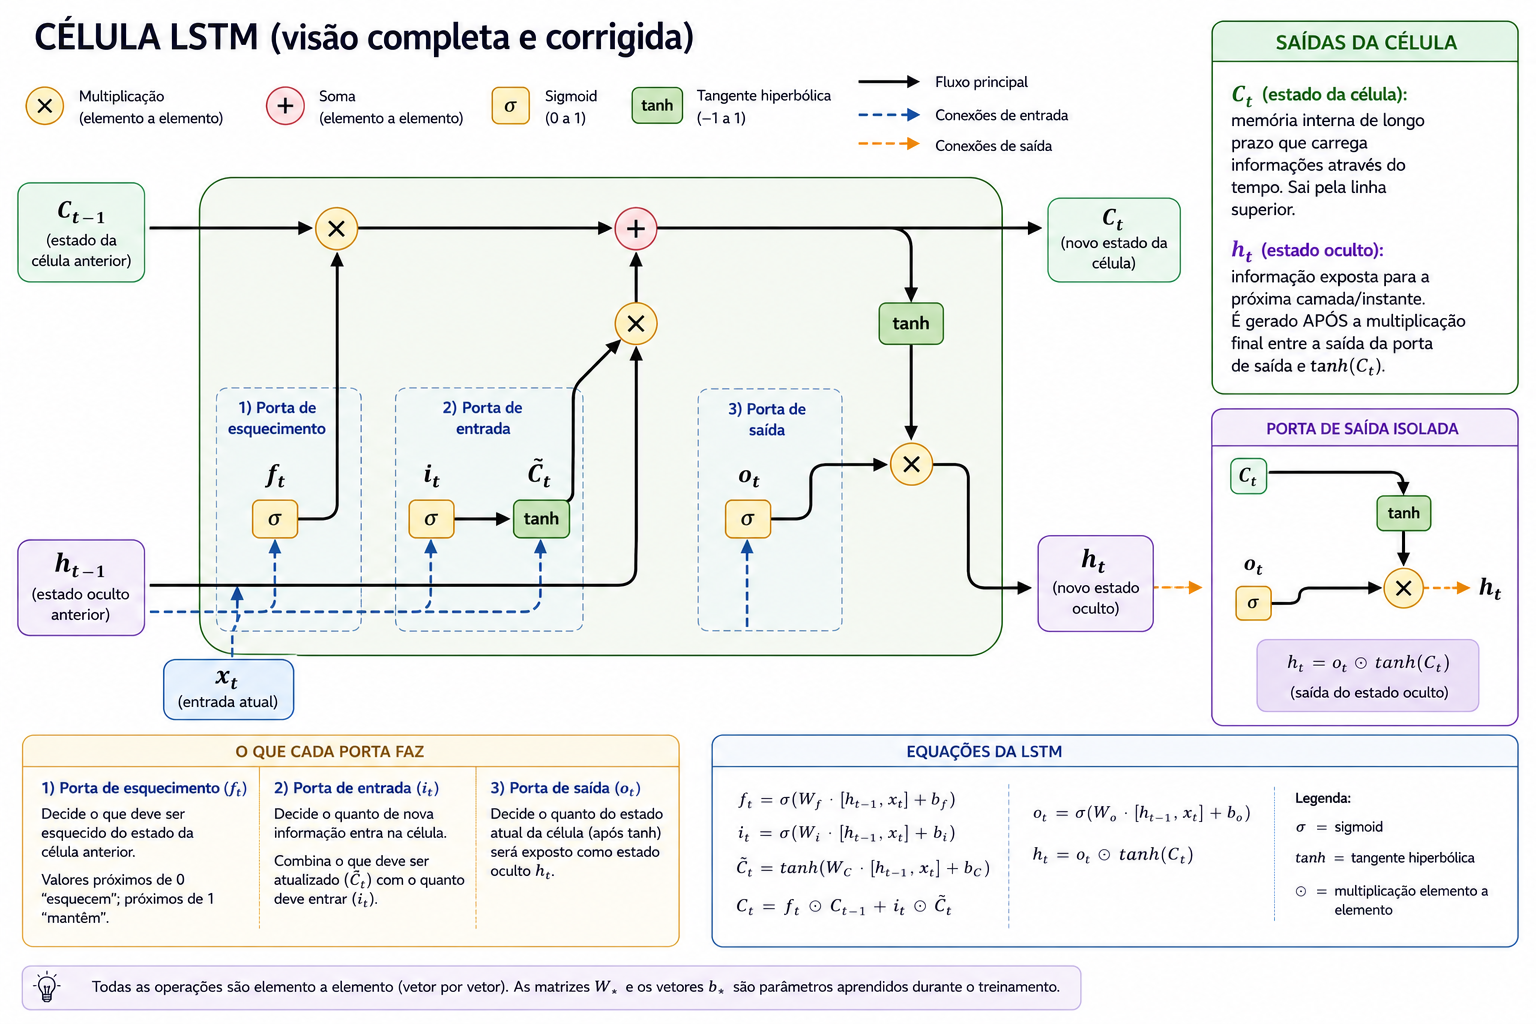

Fonte: Gerado com IA (ChatGPT).

Uma última porta final de saída (não mostrada acima) é definida como 
$$\hat{y}_t=\sum_t \left(W_y \cdot h_t +b_y\right).$$

* Retropropagação pelo tempo (BPTT)

  A retropropagação inicia, como sempre, pela derivada da função de perdas da saída da célula em respeito à própria saída. A derivada depende obviamente da função *Loss* escolhida.  temos então. inicialmente, $\frac{\partial L}{\partial \hat{y}}$.

  A derivada com respeito aos pesos são obtidas através do método das derivadas parciais (veja as equações de propagação direta na figura acima):

  $$\frac{\partial L}{\partial w_y}= \sum_t \frac{\partial L}{\partial \hat{y}_t} \circ \frac{\partial \hat{y}_t}{\partial W_y}=\sum_t\frac{\partial L}{\partial \hat{y}_t} \cdot h_t;$$
  $$\frac{\partial L}{\partial b_y}=\sum_t\frac{\partial L}{\partial \hat{y_t}},$$
onde o símbolo $\circ$ é usado para siginificar o produto de Hadamard, ou produto termo a termo.

  Agora, para os outros gradientes, precisaremos primeiro determinar os gradientes em relação ao estado oculto $h_t$ e ao estado da célula $C_t$. Entretanto, é importante notar que em uma LSTM , $h_t$ e $C_t$ influenciam o futuro por múltiplos caminhos simultaneamente. Com efeito, $h_t=o_t \circ tanh(C_t)$ e ao mesmo é utilizado em  $h_{t+1}$. Portanto, podemos escrever que

  $$\frac{\partial L}{\partial h_t}=\frac{\partial L}{\partial h_t}+\frac{\partial L_{next}}{\partial h_t}$$
  onde a primeira derivada no lado direito é o gradiente da função *Loss* em relação ao estado presente e a segunda é o gradiente  da função *Loss* no instante $t+1$ em relação à ${h_t}$. Assim,
  $$\frac{\partial L}{\partial h_t}=\frac{\partial L}{\partial \hat{y}_t}\cdot W_y+\frac{\partial L_{next}}{\partial h_t}$$

Seja $z_t$ a concatenação do estado oculto na saída do passo anterior e da entrada no passo atual, como mostrado nas expressões da figura acima, ou seja, $z_t=\begin{bmatrix}h_{t-1} \\ x_t\end{bmatrix}$. $z_t$ está presente nas definições de $f_t,\;i_t,\;\tilde{c}_t\;\text{e}\;o_t$. Daí que 
$$\frac{\partial L}{\partial z_t}=W_f\cdot\frac{\partial L}{\partial f_t}+W_i\cdot\frac{\partial L}{\partial i_t}+W_c\cdot\frac{\partial L}{\partial \tilde{c}_t}+W_o\cdot\frac{\partial L}{\partial o_t}=\begin{bmatrix}\frac{\partial L}{\partial h_{t-1}} \\ \frac{\partial L}{\partial x_t}\end{bmatrix}$$
e finalmente os primeiros termos deste vetor correspondem à $\frac{\partial L_{next}}{\partial h_t}$. 

Para o estado da célula, $C_t$, temos também que $C_{t+1}=f_{t+1}C_t+ i_{t+1}\tilde{C}_{t+1}$, de forma que além do estado oculto o estado da célula no instante $t+1$ também de pende do estado no instante $t$, e daí
$$\frac{\partial L}{\partial C_t}=\frac{\partial L}{\partial h_t}\circ\frac{\partial h_t}{\partial C_t}+\frac{\partial L_{next}}{\partial C_t},$$
onde $\frac{\partial L_{next}}{\partial C_t}=f_{t+1}\frac{\partial L}{\partial C_{t+1}}.$  Os outros gradientes podem ser agora obtidos com facilidade:
    


$$\frac{\partial L}{\partial W_o}=\sum_t\left(\frac{\partial L}{\partial h_t}\circ\frac{\partial h_t}{\partial o_t}\circ\frac{\partial o_t}{\partial W_o}\right)$$

$$\frac{\partial L}{\partial b_o}=\sum_t\left(\frac{\partial L}{\partial h_t}\circ\frac{\partial h_t}{\partial o_t}\right)$$

$$\frac{\partial L}{\partial W_f}=\sum_t\left(\frac{\partial L}{\partial C_t}\circ\frac{\partial C_t}{\partial f_t}\circ\frac{\partial f_t}{\partial W_f}\right)$$

$$\frac{\partial L}{\partial b_f}=\sum_t\left(\frac{\partial L}{\partial C_t}\circ\frac{\partial C_t}{\partial b_f}\right)$$

$$\frac{\partial L}{\partial W_i}=\sum_t\left(\frac{\partial L}{\partial C_t}\circ\frac{\partial C_t}{\partial i_t}\circ\frac{\partial i_t}{\partial W_i}\right)$$

$$\frac{\partial L}{\partial b_i}=\sum_t\left(\frac{\partial L}{\partial C_t}\circ\frac{\partial C_t}{\partial i_t}\right)$$

$$\frac{\partial L}{\partial W_c}=\sum_t\left(\frac{\partial L}{\partial C_t}\circ\frac{\partial C_t}{\partial \tilde{C}_t}\circ\frac{\partial \tilde{C}_t}{\partial W_c}\right)$$

$$\frac{\partial L}{\partial b_c}=\sum_t\left(\frac{\partial L}{\partial C_t}\circ\frac{\partial C_t}{\partial \tilde{C}_t}\right)$$



Como exemplo inicial, implementaremos o processo de *feedforward/backpropagation* em pytorch usando diferenciação automática com dados simples de entrada. Serão simuladas duas etapas temporais, a *backpropagation* e a atualização dos pesos. 

In [106]:
import torch

torch.manual_seed(0)

# ==========================================
# ENTRADAS
# ==========================================

x1 = torch.tensor([[0.5]])
x2 = torch.tensor([[0.8]])
x3 = torch.tensor([[0.7]])

target = torch.tensor([[0.4]])

#-------learning rate----------
lr=0.1

# ==========================================
# ESTADOS INICIAIS
# ==========================================

h0 = torch.zeros((1,1))
c0 = torch.zeros((1,1))

# ==========================================
# PESOS (MANUAIS)
# requires_grad=True
# ==========================================

Wf = torch.tensor([[0.7, 0.2]], requires_grad=True)
Wi = torch.tensor([[0.5, 0.1]], requires_grad=True)
Wo = torch.tensor([[0.9, 0.3]], requires_grad=True)
Wc = torch.tensor([[0.6, 0.2]], requires_grad=True)

bf = torch.tensor([[0.1]], requires_grad=True)
bi = torch.tensor([[0.1]], requires_grad=True)
bo = torch.tensor([[0.1]], requires_grad=True)
bc = torch.tensor([[0.1]], requires_grad=True)

# ==========================================
# FUNÇÕES AUXILIARES
# ==========================================

sigmoid = torch.sigmoid
tanh = torch.tanh

# ==========================================
# ETAPA TEMPORAL 1
# ==========================================

print("\n======== TEMPO 1 ========")

x_concat1=torch.cat((x1,h0))

f1 = sigmoid(Wf @ x_concat1+ bf)
i1 = sigmoid(Wi @ x_concat1+ bi)
o1 = sigmoid( Wo@ x_concat1 + bo)

c_til1 = tanh(Wc @ x_concat1+ bc)

c1 = f1 * c0 + i1 * c_til1

h1 = o1 * tanh(c1)

print("f1 =", f1.item())
print("i1 =", i1.item())
print("o1 =", o1.item())
print("c_til1 =", c_til1.item())
print("c1 =", c1.item())
print("h1 =", h1.item())

# ==========================================
# ETAPA TEMPORAL 2
# ==========================================

print("\n======== TEMPO 2 ========")

x_concat2=torch.cat((x2,h1))

f2 = sigmoid(Wf  @ x_concat2+ bf)
i2 = sigmoid(Wi @ x_concat2+ bi)
o2 = sigmoid(Wo @ x_concat2 + bo)

c_til2 = tanh(Wc @ x_concat2 + bc)

c2 = f2 * c1 + i2 * c_til2

h2 = o2 * tanh(c2)

print("f2 =", f2.item())
print("i2 =", i2.item())
print("o2 =", o2.item())
print("c_til2 =", c_til2.item())
print("c2 =", c2.item())
print("h2 =", h2.item())



# ==========================================
# LOSS
# ==========================================

loss = (h2 - target)**2

print("\nLOSS =", loss.item())

# ==========================================
# BACKWARD 
# ==========================================

print("\n======== BACKWARD  ========")

loss.backward(retain_graph=True)

print("Gradiente Wf =", Wf.grad)
print("Gradiente Wi =", Wi.grad)
print("Gradiente Wo =", Wo.grad)
print("Gradiente Wc =", Wc.grad)
print("Gradiente bf=",bf.grad)
print("Gradiente bi=",bi.grad)
print("Gradiente bo=",bo.grad)
print("Gradiente bc=",bc.grad)


# ==========================================
# tualização dos Pesos para o SGD 
# ==========================================

print("\n=====Atualização dos Pesos para o SGD======")

Wf=Wf-lr*Wf.grad
bf=bf-lr*bf.grad
Wi=Wi-lr*Wi.grad
bi=bi-lr*bi.grad
Wc=Wc-lr*Wc.grad
bc=bc-lr*bc.grad
Wo=Wo-lr*Wo.grad
bo=bo-lr*bo.grad

print("\nPesos Atualizados:")
print(f"W_f: {Wf}")
print(f"b_f: {bf}")
print(f"W_i: {Wi}")
print(f"b_i: {bi}")
print(f"W_c: {Wc}")
print(f"b_c: {bc}")
print(f"W_o: {Wo}")
print(f"b_o: {bo}")


======== TEMPO 1 ========
f1 = 0.6106392741203308
i1 = 0.5866175889968872
o1 = 0.6341356039047241
c_til1 = 0.3799489736557007
c1 = 0.22288474440574646
h1 = 0.13904428482055664

======== TEMPO 2 ========
f2 = 0.6654793620109558
i2 = 0.6257213354110718
o2 = 0.7030184864997864
c_til2 = 0.5425828695297241
c2 = 0.48783087730407715
h2 = 0.31811103224754333

LOSS = 0.006705803796648979

======== BACKWARD  ========
Gradiente Wf = tensor([[-0.0036, -0.0006]])
Gradiente Wi = tensor([[-0.0125, -0.0016]])
Gradiente Wo = tensor([[-0.0128, -0.0022]])
Gradiente Wc = tensor([[-0.0499, -0.0056]])
Gradiente bf= tensor([[-0.0045]])
Gradiente bi= tensor([[-0.0181]])
Gradiente bo= tensor([[-0.0162]])
Gradiente bc= tensor([[-0.0755]])

=====Atualização dos Pesos para o SGD======

Pesos Atualizados:
W_f: tensor([[0.7004, 0.2001]], grad_fn=<SubBackward0>)
b_f: tensor([[0.1005]], grad_fn=<SubBackward0>)
W_i: tensor([[0.5013, 0.1002]], grad_fn=<SubBackward0>)
b_i: tensor([[0.1018]], grad_fn=<SubBackward0>)
W_c

Como segundo exemplo com uma LSTM, usaremos uma versão modificada o programa numpy da RNN anterior aplicado em geração de caracteres, ou seja, transformado em uma LSTM, onde as equações acima para propagação direta e retropropagação são implementadas.  Os dados de entrada são os mesmos, para que o resultado podssa ser comparado com a RNN.

In [107]:
from tqdm import tqdm
import numpy as np

##### Data #####
data = """These are the voyages of the starship Enterprise Its five year mission 
        To explore strange new worlds
        to seek out new life and new civilizations, 
        To boldly go where no man has gone before."""

chars = sorted(list(set(data)))
char_to_index = {char: i for i, char in enumerate(chars)}
index_to_char = {i: char for i, char in enumerate(chars)}

chars_size=len(chars)

train_X, train_y = data[:-1], data[1:]

##### Helper Functions #####
def oneHotEncode(text):
    output = np.zeros((chars_size, 1))
    output[char_to_index[text]] = 1

    return output

# Xavier Normalized Initialization
def initWeights(input_size, output_size):
    return np.random.uniform(-1, 1, (output_size, input_size)) * np.sqrt(6 / (input_size + output_size))

##### Activation Functions #####
def sigmoid(input, derivative = False):
    if derivative:
        return input * (1 - input)
    
    return 1 / (1 + np.exp(-input))

def tanh(input, derivative = False):
    if derivative:
        return 1 - input ** 2
    
    return np.tanh(input)

def softmax(input):
    return np.exp(input) / np.sum(np.exp(input))

##### Long Short-Term Memory Network Class #####
class LSTM:
    def __init__(self, input_size, hidden_size, output_size, num_epochs, learning_rate):
        # Hyperparameters
        self.learning_rate = learning_rate
        self.hidden_size = hidden_size
        self.num_epochs = num_epochs

        # Forget Gate
        self.wf = initWeights(input_size, hidden_size)
        self.bf = np.zeros((hidden_size, 1))

        # Input Gate
        self.wi = initWeights(input_size, hidden_size)
        self.bi = np.zeros((hidden_size, 1))

        # Candidate Gate
        self.wc = initWeights(input_size, hidden_size)
        self.bc = np.zeros((hidden_size, 1))

        # Output Gate
        self.wo = initWeights(input_size, hidden_size)
        self.bo = np.zeros((hidden_size, 1))

        # Final Gate
        self.wy = initWeights(hidden_size, output_size)
        self.by = np.zeros((output_size, 1))

    # Reset Network Memory
    def reset(self):
        self.concat_inputs = {}

        self.hidden_states = {-1:np.zeros((self.hidden_size, 1))}
        self.cell_states = {-1:np.zeros((self.hidden_size, 1))}

        self.activation_outputs = {}
        self.candidate_gates = {}
        self.output_gates = {}
        self.forget_gates = {}
        self.input_gates = {}
        self.outputs = {}

    # Forward Propogation
    def forward(self, inputs):
        self.reset()

        outputs = []
        for q in range(len(inputs)):
            self.concat_inputs[q] = np.concatenate((self.hidden_states[q - 1], inputs[q]))

            self.forget_gates[q] = sigmoid(np.dot(self.wf, self.concat_inputs[q]) + self.bf)
            self.input_gates[q] = sigmoid(np.dot(self.wi, self.concat_inputs[q]) + self.bi)
            self.candidate_gates[q] = tanh(np.dot(self.wc, self.concat_inputs[q]) + self.bc)
            self.output_gates[q] = sigmoid(np.dot(self.wo, self.concat_inputs[q]) + self.bo)

            self.cell_states[q] = self.forget_gates[q] * self.cell_states[q - 1] + self.input_gates[q] * self.candidate_gates[q]
            self.hidden_states[q] = self.output_gates[q] * tanh(self.cell_states[q])

            outputs += [np.dot(self.wy, self.hidden_states[q]) + self.by]

        return outputs

    # Backward Propagation
    def backward(self, dL_dy, inputs):
        d_wf, d_bf = 0, 0
        d_wi, d_bi = 0, 0
        d_wc, d_bc = 0, 0
        d_wo, d_bo = 0, 0
        d_wy, d_by = 0, 0

        dh_next, dc_next = np.zeros_like(self.hidden_states[0]), np.zeros_like(self.cell_states[0])
        for q in reversed(range(len(inputs))):
            d_y = dL_dy[q]

            # Final Gate Weights and Biases Errors
            d_wy += np.dot(d_y, self.hidden_states[q].T)
            d_by += d_y

            # Hidden State Error
            d_ht = np.dot(self.wy.T, d_y) + dh_next

            # Output Gate Weights and Biases Errors
            d_o = tanh(self.cell_states[q]) * d_ht *sigmoid(self.output_gates[q], derivative = True)
            d_wo += np.dot(d_o, inputs[q].T)
            d_bo += d_o

            # Cell State Error
            d_ct = tanh(tanh(self.cell_states[q]), derivative = True) * self.output_gates[q] * d_ht + dc_next

            # Forget Gate Weights and Biases Errors
            d_f = d_ct * self.cell_states[q - 1] * sigmoid(self.forget_gates[q], derivative = True)
            d_wf += np.dot(d_f, inputs[q].T)
            d_bf += d_f

            # Input Gate Weights and Biases Errors
            d_i = d_ct * self.candidate_gates[q] * sigmoid(self.input_gates[q], derivative = True)
            d_wi += np.dot(d_i, inputs[q].T)
            d_bi += d_i
            
            # Candidate Gate Weights and Biases Errors
            d_c = d_ct * self.input_gates[q] * tanh(self.candidate_gates[q], derivative = True)
            d_wc += np.dot(d_c, inputs[q].T)
            d_bc += d_c

            # Concatenated Input Error (Sum of Error at Each Gate!)
            d_z = np.dot(self.wf.T, d_f) + np.dot(self.wi.T, d_i) + np.dot(self.wc.T, d_c) + np.dot(self.wo.T, d_o)

            # Error of Hidden State and Cell State at Next Time Step
            dh_next = d_z[:self.hidden_size, :]
            dc_next = self.forget_gates[q] * d_ct

        for d_ in (d_wf, d_bf, d_wi, d_bi, d_wc, d_bc, d_wo, d_bo, d_wy, d_by):
            np.clip(d_, -1, 1, out = d_)

        self.wf -= d_wf * self.learning_rate
        self.bf -= d_bf * self.learning_rate

        self.wi -= d_wi * self.learning_rate
        self.bi -= d_bi * self.learning_rate

        self.wc -= d_wc * self.learning_rate
        self.bc -= d_bc * self.learning_rate

        self.wo -= d_wo * self.learning_rate
        self.bo -= d_bo * self.learning_rate

        self.wy -= d_wy * self.learning_rate
        self.by -= d_by * self.learning_rate

    # Train
    def train(self, inputs, labels):
        inputs = [oneHotEncode(input) for input in inputs]

        for _ in tqdm(range(self.num_epochs)):
            predictions = self.forward(inputs)

            dL_dy = []
            for q in range(len(predictions)):
                dL_dy += [softmax(predictions[q])]
                dL_dy[-1][char_to_index[labels[q]]] -= 1

            self.backward(dL_dy, self.concat_inputs)
    
    # Test       
    def forward_step(self, x, h_prev, c_prev):
    
            concat = np.concatenate((h_prev, x))
        
            f = sigmoid(np.dot(self.wf, concat) + self.bf)
        
            i = sigmoid(np.dot(self.wi, concat) + self.bi)
        
            c_bar = tanh(np.dot(self.wc, concat) + self.bc)
        
            o = sigmoid(np.dot(self.wo, concat) + self.bo)
        
            c = f * c_prev + i * c_bar
        
            h = o * tanh(c)
        
            y = np.dot(self.wy, h) + self.by
    
            return y, h, c
    
    def Generate(self, seed, length=200):

        # Estado inicial
        h = np.zeros((self.hidden_size, 1))
        c = np.zeros((self.hidden_size, 1))
    
        generated_text = seed
    
        # Alimenta a seed
        for char in seed[:-1]:
    
            x = oneHotEncode(char)
    
            _, h, c = self.forward_step(x, h, c)
    
        current_char = seed[-1]
    
        # Geração autoregressiva
        for _ in range(length):
    
            x = oneHotEncode(current_char)
    
            y, h, c = self.forward_step(x, h, c)
    
            probs = softmax(y.reshape(-1))
    
            idx = np.random.choice(range(chars_size), p=probs)
    
            current_char = index_to_char[idx]
    
            generated_text += current_char
    
        return generated_text
        
# Initialize Network
hidden_size = 25


In [108]:
lstm = LSTM(input_size = chars_size + hidden_size, hidden_size = hidden_size, 
            output_size = chars_size, num_epochs = 1_000, learning_rate = 0.05)

In [109]:
##### Training #####
lstm.train(train_X, train_y)

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:16<00:00, 60.45it/s]


In [110]:
##### Testing #####
print("\n"+lstm.Generate("These ", length=len(data)))


These are the voyages of the starship Enterprise Its five year mission 
        To explore strange new worlds
        to seek out new life and new civilizations, 
        To boldly go where no man has gone before.eno ma


Como último exemplo, usaremos a base de dados PJME_hourly.csv em uma LSTM implementada em Keras/Tensorflow para fazer uma previsão de consumo elétrico. Este conjunto de dados são os dados de consumo de energia por hora e por dia da PJM Interconnection LLC (PJM), uma organização regional de transmissão (RTO) nos Estados Unidos que supervisiona o sistema de transmissão de energia elétrica na região leste. O conjunto de dados abrange o período de 2002 a 2018 e contém 145.336 registros horários e 6.057 registros diários. O conjunto de dados está disponível publicamente em 

https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption?select=PJME_hourly.csv

In [111]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense,Input

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

* Inicialmente o pandas lê o arquivo CSV e cria um dataframe.
* O pandas converte a coluna *Datetime*, que inicialmente é composta por *strings* de texto, em objetos de data/hora que possam ser reconhecidos como valores reais. Por exemplo, '2002-01-01 01:00'é convertido em Timestamp('2002-01-01 01:00:00'). Isto é necessário porque séries temporais precisam de valores reais para todo tipo de processamento posterior.
* Estabelece a coluna *Datetime* como índice temporal da base de dados.
* O pandas reorganiza os dados para frequência horária (resample('h')), garantindo que a sequência de dados seja regular, com espaçamento temporal constante  e sem valores nulos. mean() agrega valores de múltiplos registros dentro da mesma e substitui pela média. ffill() preenche os valores criados em resample('h') com os últimos valores válidos anteriores. Em séries temporais como esta os valores consecutivos costumam ser correlacionados, e manter o último valor quendo uma nova amostra é criada preserva a continuidade temporal. 

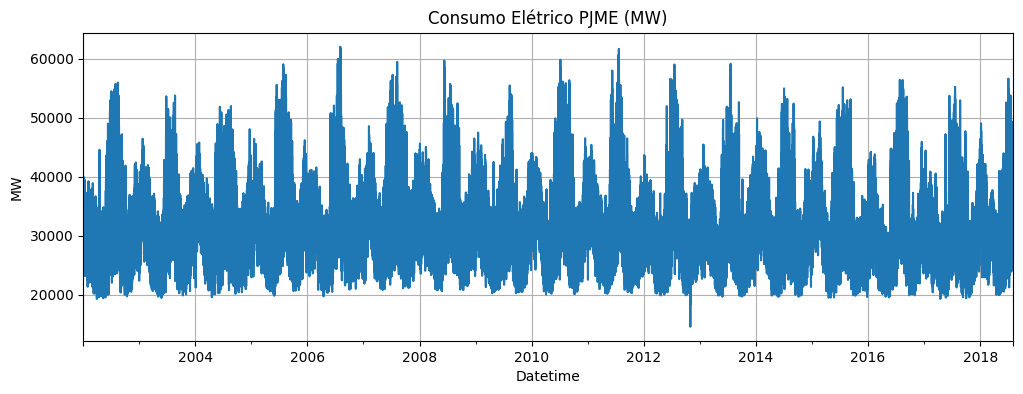

In [113]:
# Carregar dados públicos de consumo horário PJME
df = pd.read_csv('PJME_hourly.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])  # converte string para datetime
df = df.set_index('Datetime')                   # define como índice
df = df.resample('h').mean().ffill()  # Garantir frequência horária e sem valores nulos

# Visualização dos dados
df.plot(figsize=(12, 4), title='Consumo Elétrico PJME (MW)', legend=False)
plt.ylabel("MW")
plt.grid(True)
plt.show()

* Valores muito grandes na base de dados podem causar explosão de gradientes, treinamento instável e saturação das funções de ativação sigmoide ou tanh.  Por isso, MinMaxScaler() transforma os dados em um intervalo como [0,1]. Para isso ele aplica $x_{norm}=\frac{x-x_{min}}{x_{max}-x_{min}}$.
* A rede LSTM, assim com as RNNs, não processam a série temporal inteira de uma vez, mas por sequências de tamanho fixo, onde ela aprende para cada sequência a prever os valores futuros. Neste caso são formadas sequências de 24 horas e previstas as próximas 6 horas.
* Após create_sequences(), cada elemento de X contém uma sequência de 24 hrs, e cada elemento de y contém as 6 horas futuras correspondentes ao mesmo elemento de X. Importante: X[0,:] conterá uma janela de 0 à 23hrs, e y[0,:] conterá as próximas 6 horas, ou seja, de 24$\rightarrow$ 29 horas. Por sua vez, X[1,:] contém uma janela 1$\rightarrow$24 horas, e y[1,:] contém 25$\rightarrow$ 30 horas. A cada intervalo a janela "escorrega" apenas uma hora. 

In [114]:
# Normalização dos dados
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# 3. Função para criar janelas
def create_sequences(data, window_size=24, forecast_horizon=6):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data[i:i+window_size]) # Cria o *array* de sequências de 24 horas
        y.append(data[i+window_size:i+window_size+forecast_horizon]) # o label(alvo) são as próximas 6 horas. 
    return np.array(X), np.array(y)

# Parâmetros
window_size = 24   # últimas 24 horas
forecast_horizon = 6  # prever as próximas 6 horas

X, y = create_sequences(scaled_data, window_size, forecast_horizon)

# Dividir em treino e teste
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [115]:
# Definir modelo LSTM simples
model = Sequential()
model.add(Input(shape=(window_size, 1)))
model.add(LSTM(64))
model.add(Dense(forecast_horizon))
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,286 (67.52 KB)

 Trainable params: 17,286 (67.52 KB)

 Non-trainable params: 0 (0.00 B)

In [116]:
# Treinar modelo
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1) #10% para validação dos dados

Epoch 1/10
3271/3271 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 0.0089 - val_loss: 0.0028
Epoch 2/10
3271/3271 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 3/10
3271/3271 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.0010 - val_loss: 0.0015
Epoch 4/10
3271/3271 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 8.9495e-04 - val_loss: 0.0010
Epoch 5/10
3271/3271 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 8.1035e-04 - val_loss: 8.6536e-04
Epoch 6/10
3271/3271 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 7.4540e-04 - val_loss: 8.0460e-04
Epoch 7/10
3271/3271 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 6.8750e-04 - val_loss: 7.4746e-04
Epoch 8/10
3271/3271 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 6.2897e-04 - val_loss: 7.0799e-04
Epoch 9/10
3271/3271 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 5.6588e-04 - val_loss: 6.9399e-04
Epoch 10/10
3271/3271 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 5.1924e-04 - val_loss: 6.8109e-04


909/909 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Horizonte 1h - RMSE: 439.18 MW
Horizonte 2h - RMSE: 802.51 MW
Horizonte 3h - RMSE: 1109.19 MW
Horizonte 4h - RMSE: 1416.32 MW
Horizonte 5h - RMSE: 1585.56 MW
Horizonte 6h - RMSE: 1820.59 MW


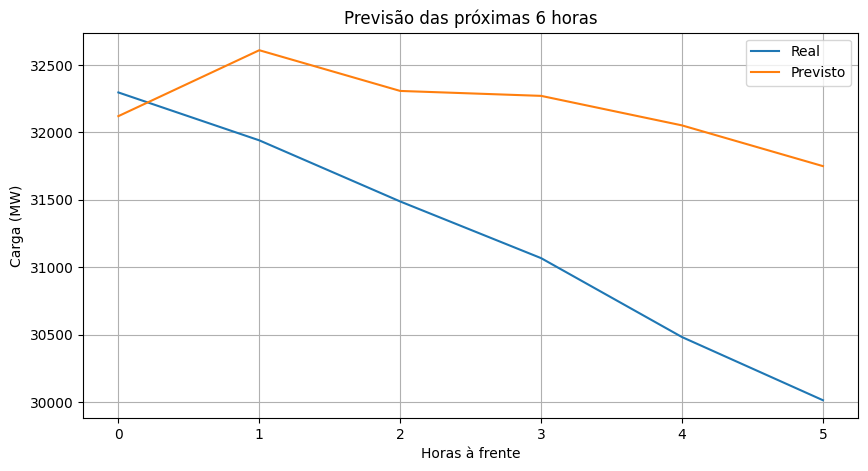

In [117]:
# Previsões
y_pred = model.predict(X_test)

# 8. Inverter normalização: Converte osdados de um tensor 3D para um tensor 2D de forma 
# que o inverse_tranformam() possa inverter a normalização e depois restaura o formato original dos dados. 
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(y_pred.shape)

# 9. Avaliação por horizonte
for h in range(forecast_horizon):
    rmse = np.sqrt(mean_squared_error(y_test_inv[:, h], y_pred_inv[:, h]))#Erro qudrático médio
    mae = mean_absolute_error(y_test_inv[:, h], y_pred_inv[:, h])# Erro absoluto médio
    print(f'Horizonte {h+1}h - RMSE: {rmse:.2f} MW')

# 10. Visualização para 1 exemplo
plt.figure(figsize=(10, 5))
plt.plot(range(6), y_test_inv[24], label='Real')
plt.plot(range(6), y_pred_inv[24], label='Previsto')
plt.xlabel('Horas à frente')
plt.ylabel('Carga (MW)')
plt.title('Previsão das próximas 6 horas')
plt.legend()
plt.grid(True)
plt.show()

Variação de Hiperparâmetros para Modelos de Redes Neurais Recorrentes

    window_size (tamanho da janela de tempo, por ex 12, 24 ou 48 hrs;

    Unidades de Neurônios na camada LSTM (64, no exemplo acima);

    forecast_horizon, alcance da previsão em número de horas;

    Dropout (dropout e recurrent_dropout, ver abaixo em overfitting);

    batch_size, ou tamanho do lote;

    Overfitting Em modelagem matemática, overfitting é "a produção de uma análise que corresponde muito próxima ou exatamente a um conjunto específico de dados e, portanto, pode não se ajustar a dados adicionais ou prever observações futuras de forma confiável". Um modelo com overfitting é um modelo matemático que contém mais parâmetros do que pode ser justificado pelos dados.

    Underfitting O underfitting ocorre quando um modelo matemático não consegue capturar adequadamente a estrutura subjacente dos dados. Um modelo com underfitting é um modelo em que alguns parâmetros ou termos que apareceriam em um modelo especificado corretamente estão ausentes.

    A regularização de dropout (remoção aleatória de dados do conjunto de treinamento) também pode melhorar a robustez e, portanto, reduzir o overfitting ao remover probabilisticamente entradas para uma camada.


## Word Embeddings

Redes neurais não compreendem palavras, caracteres ou texto, mas números. Por este fato, *tokens* (carcteres ou palavras em um texto) são representados por vetores numéricos, como é o caso da representação *One Hot*. Neste tipo de representação, cada *token* é representado por um vetor ortogonal aos vetores representando os outros *tokens*. Qualquer relação, ou correlação entre diferentes palavras, por exemplo, é completamente igonorada. 

Por outro lado, *word embeddings* são representações numéricas de palavra, que capturam informações semânticas e sintáticas. Palavras com significado similar são próximas no espaço vetorial no qual elas são representadas. Esta forma de codificação tem  um papel importante no Processamento de Linguagem Natural (PLN).

Um dos algoritmos mais populares para encapsulamento de *tokens* em *word embedding* é o Word2Vec, para o qual existe vários modelos de grandes conjuntos de palavras pré treinados. Um deles é o modelo Google News com aproximadamente 1,5GB de tamanho.  Vamos carregar este modelo e fazer alguns testes:

In [118]:
from gensim.models import KeyedVectors

C:\Users\Avell\Desktop\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [119]:
# Carrega o modelo pré-treinado Word2Vec model
model_WV = KeyedVectors.load_word2vec_format(
    'GoogleNews-vectors-negative300.bin', 
    binary=True, 
    limit=500000  # Load first 500k words (optional, for faster loading)
)

FileNotFoundError: [Errno 2] No such file or directory: 'GoogleNews-vectors-negative300.bin'

In [ ]:
# Checagem de similaridade entre palavras:
print(model_WV.similarity("king", "queen")) 

In [ ]:
 print(model_WV.most_similar("happy"))  

Em Processamento de Linguagem Natural, um dos mais famosos exemplos usados para ilustrar o poder de representação de termos similares por vetores próximos em um espaço vetorial é descrito pela associação seguinte:  

King +Woman-Man = Queen.

Vamos testar este exemplo com o modelo Google News. 

In [ ]:
vector=model_WV["king"] - model_WV["man"] + model_WV["woman"]
print(model_WV.similar_by_vector(vector))

Como pode ser visto, a palavra mais similar é *King*, e *queen* vem em segundo lugar. Portanto, a palavra original deve ser artificialmente excluída do resultado para confirmar a expectativa do exemplo. 

Vamos testar este conjunto pré-treinado em uma rede LSTM para fazer a análise de sentimentos com a base de dados IMDB *movie review dataset*. 

In [ ]:
# Importação de bibliotecas
import numpy as np
from tensorflow import  random
from tensorflow.keras.datasets import imdb
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Input, LSTM, Dropout,GRU
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
np.random.seed(42)
random.set_seed(42)

# Carrega o IMDB dataset ( 10,000 mais frequentes palavras)
vocab_size = 10000  
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)
 
# data shape
print(f"Train sequences: {len(x_train)}, Test sequences: {len(x_test)}")
print(f"Example sequence (first 10 words): {x_train[0][:10]}")

# Pad sequences um comprimento fixo 
max_seq_length = 200
max_dim_xy=len(x_train)
x_train_padded = pad_sequences(x_train[0:max_dim_xy], maxlen=max_seq_length, padding='post', truncating='post')
x_test_padded = pad_sequences(x_test, maxlen=max_seq_length, padding='post', truncating='post')
 
print(f"Padded sequence shape: {x_train_padded.shape}")  # (25000, 200)

In [ ]:
# Dicionário palavras:índices
word_index = imdb.get_word_index()  # Dict: {word: index}
# Ajuste de índices, pois Keras reserva os índices 0 para padding, 1 para start e  2 para unknown. 
word_index = {k: (v + 3) for k, v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2  # Unknown
word_index["<UNUSED>"] = 3

In [ ]:
embedding_dim = model_WV.vector_size  # 300

In [ ]:
# Inicializa a matriz de  embedding matrix com valores randômicos
embedding_matrix = np.random.randn(
    vocab_size,
    embedding_dim
) * 0.01 

In [ ]:
# Preenche a matriz com  com embeddings pré-treinados
oov_count = 0  # números de palavras ausentes do vocabulário
for word, idx in word_index.items():
    if idx >= vocab_size:
        continue
    if word in model_WV:
        embedding_matrix[idx] = model_WV[word]
    else:       
        oov_count+=1
 
print(f"OOV words: {oov_count}/{vocab_size} ({oov_count/vocab_size:.2%})")

In [ ]:
# Cria o modelo LSTM

# camada Embedding
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,   
    weights=[embedding_matrix],
    trainable=False,  # congela os pesos do embedding pré-treinados
    mask_zero=True  # Ignora tokens de  padding (<PAD>)
)

model = Sequential([
    Input(shape=(max_seq_length,)),
    embedding_layer,
    LSTM(units=128, return_sequences=False),
    Dropout(0.4),  # Regularização para prevenir Overfitting
    Dense(units=1, activation='sigmoid')
])
model.summary()

In [ ]:
# Compila o  modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Salva o melhor modelo
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)

# Treino:
history = model.fit(
    x_train_padded, y_train[0:max_dim_xy],
    epochs=10,
    batch_size=32,
    validation_split=0.2,  # Use 20% dos dados de treino para validação
    callbacks=[checkpoint]
)

In [ ]:
# Teste com o melhor modelo:
model.load_weights('best_model.keras')
test_loss, test_acc = model.evaluate(x_test_padded, y_test)
print(f"\n Test accuracy: {test_acc:.4f}")

In [ ]:
# Fine Tuning

# Descongelamento da camada Embedding (Liberação para treino) e nova compilação
embedding_layer.trainable = True
 
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # Menor LR para  lenta alteração dos vetores de pesos
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

In [ ]:
# Novo treino
history_refine = model.fit(
    x_train_padded, y_train[0:max_dim_xy],
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint]
)

In [ ]:
# teste com melhor modelo
model.load_weights('best_model.keras')
test_loss, test_acc = model.evaluate(x_test_padded, y_test)
print(f"\n Test accuracy: {test_acc:.4f}")

O *Fine Tuning* aumenta levemente a acurácia neste exemplo. Isto se deve à alguns possíveis fatores:
* o Google News Word2Vec já é muito bom;
* o IMDB possui apenas 25 mil reviews;
* estão sendo usadas apenas 10 mil palavras do vocabulário.
  
Nessas condições, o ganho do fine-tuning costuma ser pequeno, às vezes inexistente.

De forma a verificar o benefício resultante do uso de *embeddings* pré-treinados, foi realizado um experimento com 3 modelos diferentes: 

* A rede com Word2Vec;
* A rede com *embedding* aleatório, mas com todos os pesos do *embedding* livres para serem treinados, e
*  A rede acima com os pesos do *embedding* congelados.

A rede usada tem apenas 32 células LSTM para reduzir  *overfitting* e esforço computacional, e as medidas foram calculadas para 500, 1000, 2000, 5000, 10000 e 25000 avaliações da base IMDB. Os resultados podem ser consultados na tabela abaixo, onde vemos que o uso de Word2Vec leva quase sempre à uma maior acurácia, embora com uma diferença de aproximadamente 2-5% apenas em relação à rede com embedding aleatório com pesos treináveis. Isto pode ser facilmente explicável se levarmos em consideração o número de pesos treináveis em cada caso. A rede com *embedding* aleatório treina 72 vezes o número de pesos da rede com Word2Vec, com um esforço computacional muito maior. Daí, principalmente com 25.000 *reviews* a própria rede aprende *embeddings* bastante bons. Já na comparação com a rede aleatória com pesos congelados, onde as duas possuem o mesmo número de pesos treináveis, a diferença é muito maior, entre 12-20 %, com a maior discrepância com baixos números de avaliações, insuficientes para treinar os pesos da rede. 




\begin{vmatrix}
\text{Num. Aval.}& \text{Word2Vec} & \text{\textit{Embedding} aleatório treinável}& \text{\textit{Embedding} aleatório congelado}\\
500 & \text{75,46}\% & \text{70,56}\% &\text{55,12}\%\\
1000 & \text{73,85}\% & \text{70,92}\% &\text{56,91}\%\\
2000 & \text{77,5}\% & \text{75,71}\% &\text{67,41}\%\\
5000 & \text{79,78}\% & \text{77,74}\% &\text{69,43}\%\\
10000 & \text{84,09}\% & \text{80,84}\% &\text{72,75}\%\\
25000 & \text{86,72}\% & \text{85,14}\% &\text{74,04}\%\\
 &  & \text{ Num. de pesos treináveis - Memória utilizada}&\\
 & \text{42657-166,63 kB}& \text{3042652-11,61 MB}&\text{42657-166,63kB}
\end{vmatrix}

## Estado da Arte: O *Transformer* (GPT-2,GPT-3,GPT-4, ChatGPT, Gemini, Grok, BERT, etc.)

O Transformer é uma família de arquiteturas de redes neurais artificiais baseadas no mecanismo de *multi-head attention*, no qual o texto é convertido em representações numéricas chamadas *tokens*.  Em cada camada, cada *token* é então contextualizado dentro do escopo da janela de contexto com outros *tokens*  por meio de um mecanismo de atenção *multi-head paralelo*, permitindo que o sinal para *tokens* relevantes seja amplificado e tokens menos importantes sejam diminuídos. A arquitetura foi proposta no artigo "Attention Is All You Need" por pesquisadores da Google.  

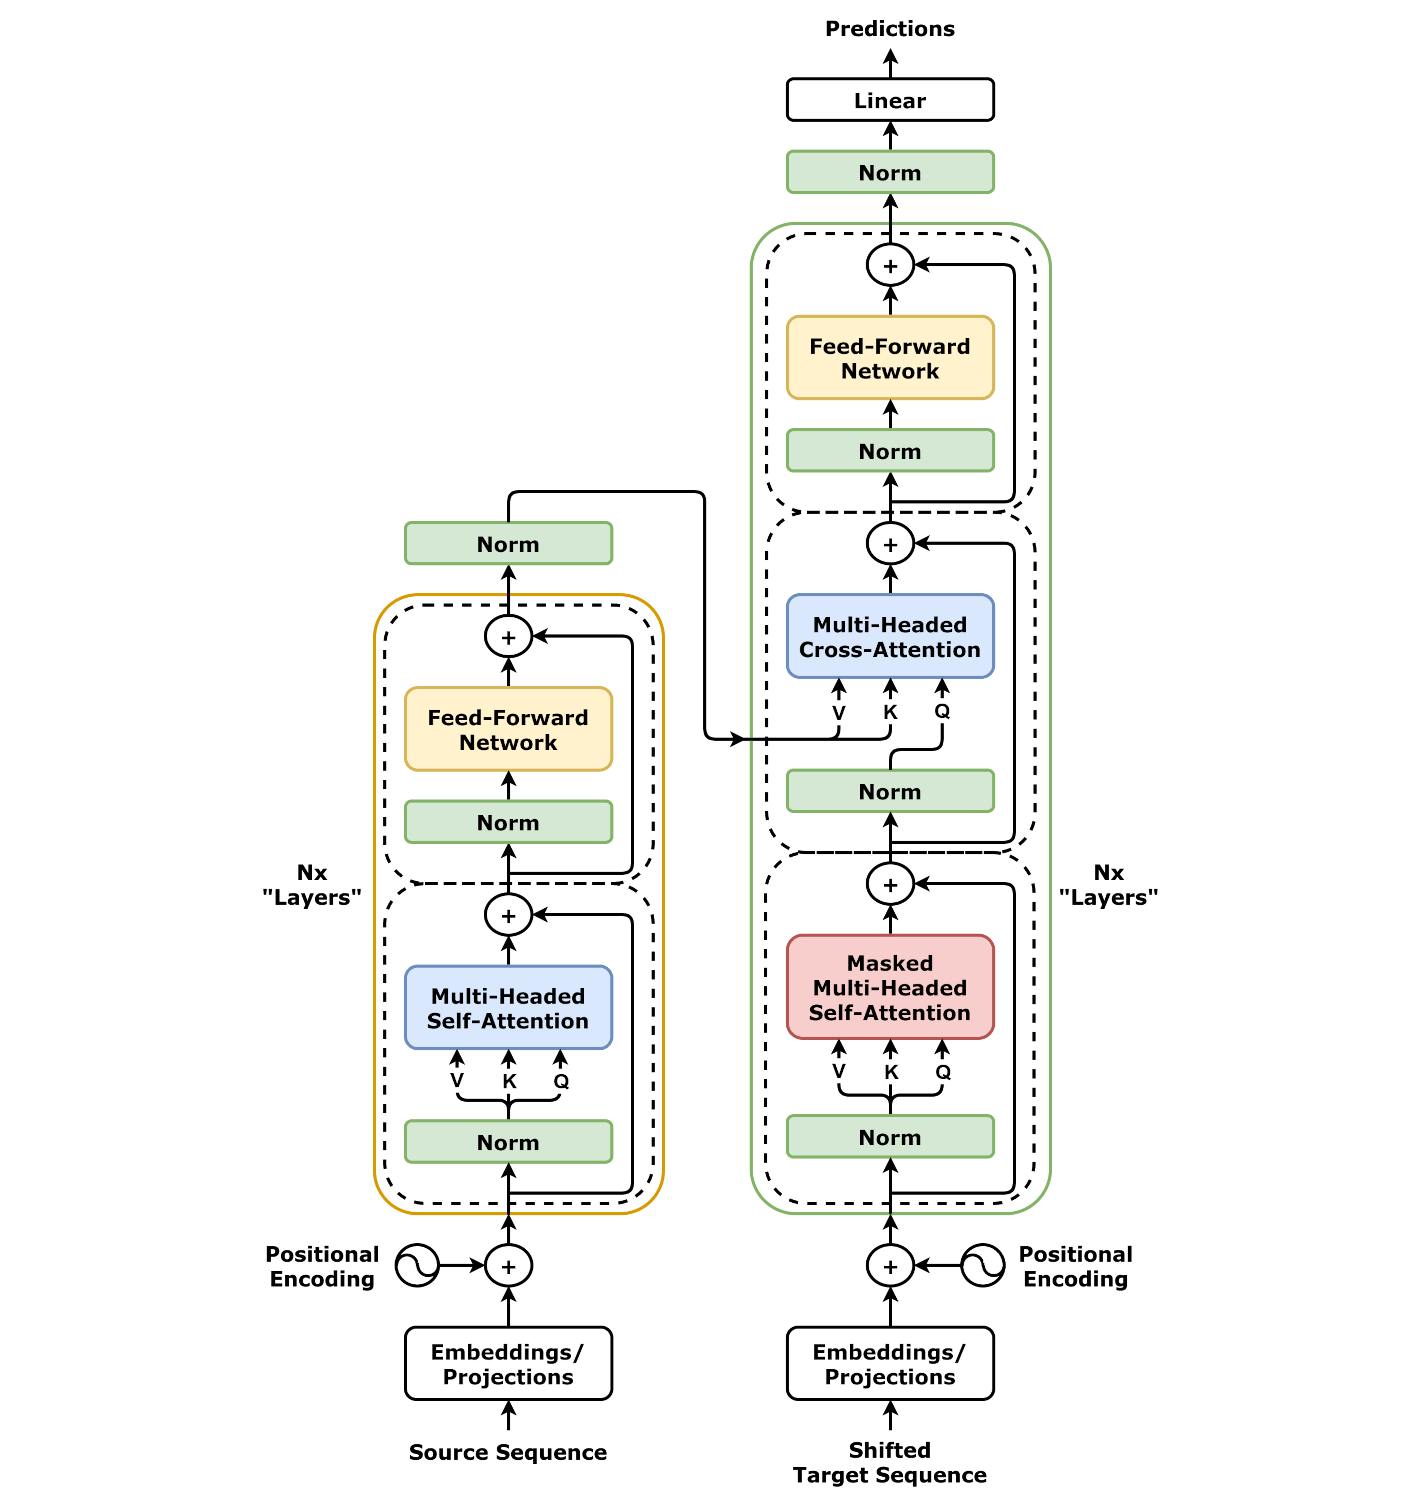

Fonte:By dvgodoy - https://github.com/dvgodoy/dl-visuals/?tab=readme-ov-file, CC BY 4.0, https://commons.wikimedia.org/w/index.php?curid=151216016


 Normalmente uma rede *Transformer* possui como componentes primários:

* Tokenização: Mapeamento dos caracteres do texto de entrada em valores inteiros.
* *Word Embedding*
* *Positional Encoding*: A codificação posicional é uma representação vetorial de tamanho fixo das posições relativas dos *tokens* dentro de uma sequência: ela fornece ao modelo *Transformer* informações sobre onde as palavras estão na sequência de entrada. Note que em redes RNNs esta camada é desnecessária porque os *tokens* entram na rede de forma sequencial, enquanto em um *transformer* eles entram simultaneamente.
* *Encoder-Decoder*: O modelo original do *Transformer* utilizava e ainda utiliza  frequentemente uma arquitetura codificador-decodificador. O codificador consiste em camadas de codificação que processam todos os *tokens* de entrada simultaneamente, uma camada após a outra, enquanto o decodificador consiste em camadas de decodificação que processam iterativamente a saída do codificador e os tokens de saída do decodificador até o momento, como ilustrado na figura acima.
  
* Atenção: O coração da rede, como será visto em mais detalhes abaixo.
* *Masking Scores in Attention Layer* : Na modelagem de linguagem, cada *token* deve considerar apenas os tokens anteriores na sequência, e não os posteriores. Isso impede que o modelo tente prever tokens futuros ao calcular o token atual.
  
* *Feed-Forward*: Como pode ser visto na figura, o codificador consiste em um mecanismo de atenção *multi-Head* seguido de uma rede *feed-forward* padrão que tem o objetivo de refinar os pesos calculados na camada anterior. Em um codificador/decodificador a sequência de camadas *Multi-head Attention* e *Feed-Forward* é repetida um certo número de vezes, sendo que no artigo "Attention is All You Need", os pesquisadores utilizaram 6 codificadores no bloco de codificação e o mesmo número de decodificadores no bloco de decodificação, sendo todos os blocos de codificadores e decodificadores idênticos.

### Positional Encoding 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def Positional_Encoding(max_len, embed_dim):
    position = np.arange(max_len)[:, np.newaxis]
    w_freq = np.exp(np.arange(0, embed_dim, 2) * -(np.log(10000.0) / embed_dim))
    
    pe = np.zeros((max_len, embed_dim))
    pe[:, 0::2] = np.sin(position * w_freq)
    pe[:, 1::2] = np.cos(position * w_freq)
    
    return pe

In [ ]:
max_len=5000
embed_dim=384
pe=Positional_Encoding(max_len,embed_dim)

pe=pe[0:100,0:200]

plt.figure(figsize=(8, 6))
plt.imshow(pe, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Sinusoidal Positional Encoding')
plt.xlabel('Dimension')
plt.ylabel('Position')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
dimensions = [0, 80]
for d in dimensions:
    plt.plot(pe[:, d], label=f'Dim {d}')
plt.legend()
plt.title('Sinusoidal Positional Encoding for Specific Dimensions')
plt.xlabel('Position')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

### Auto-Atenção

Quando o Transformer analisa uma palavra, ele cria 3 Matrizes:

    Query (Q): O que é procurado?
    Key (K): O que é oferecido?
    Value (V): Qual informação é entregue?

Exemplo: Assuma uma sentença de 3 tokens, como em "Eu prefiro amargo". Então, o comprimento da sequência é 3. Considere que o tamanho do embedding é 4, ou seja, o tokenizer e a camada embedding geram 3 vetores de dimensão 1x4, que podem ser agrupados em uma matriz 3X4. Por exemplo, 

In [ ]:
import numpy as np
x1 = [1, 0, 1, 0]
x2 = [0, 1, 0, 1]
x3 = [1, 1, 0, 0]
X=np.vstack((x1,x2,x3))

In [ ]:
print(X)

veja que $X \in \mathbb{R}^{3x4}$, 

onde cada linha representa um *token* e as colunas representam o *embedding*. 

Considere agora que Q, K e V possuem dois valores  por *token*. Para formação destes vetores precisamos de matrizes de pesos $W_q,\;W_k\;e\;W_v$, que serão treinados pela rede, com dimensões 4x2:

In [ ]:
wq=np.array([[1,0],[0,1],[1,0],[0,1]])
wk=np.array([[0,1],[1,0],[0,1],[1,0]])
wv=np.array([[1,1],[0,1],[1,0],[0,1]])

Desta forma, as matrizes Q, K e V são obtidas com o produto interno entre *X* e as matrizes de pesos, como mostrado na figura no final deste exemplo:

In [ ]:
Q=np.dot(X,wq)
K=np.dot(X,wk)
V=np.dot(X,wv)
print(Q)
print(K)
print(V)

Cálculo das pontuações de atenção (*Scores*): $S=Q\cdot K^T$.

In [ ]:
S=np.dot(Q,K.T)
print(S)

Observe as matrizes Q e K. Cada linha de Q corresponde a um *token* específico, assim com cada linha de K. No cálculo de S, cada *query* é comparado com cada *key*. Por exemplo, para o primeiro *token*, $Q_1=[2,0]$, o qual é comparado por produto interno com cada *key* de todos os *tokens*, resultando em 0, 4 e 2. Assim, a primeira linha de S contém os *scores* de atenção para o *token* 1. A matriz S é a matriz final de atenção. S[0][1]=4 significa que os dois *tokens* estão fortemente ligados semanticamente no texto de entrada. Dizendo de outra forma, isso diz o quanto o *token* 1 está interessado no *token* 2.

Os *scores* são escalonados pela raiz da dimensão dos vetores Q e K ($\sqrt{d_k}$), porque os produtos internos tendem a crescer demais com o crescimento destes vetores, causando problemas de estabilidade numérica. Neste exenplo simples, $d_k$=2, então, em seguida aplicamos *Softmax*  às linhas de S escalonadas:

In [ ]:
S=S/np.sqrt(2)
expS=np.exp(S)
sum=expS.sum(axis=1)
softmax1=expS[0,:]/sum[0]
softmax2=expS[1,:]/sum[1]
softmax3=expS[2,:]/sum[2]
A=np.round(np.vstack((softmax1,softmax2,softmax3)),2)
print(A)

In [ ]:
T_prob=A.sum(axis=1)
print(T_prob)

Todas as probabilidades somam 1, como é esperado. Segundo os resultados acima, relativamete ao *token* 1, o *token1* recebe 5% de atenção, o *token* 2 recebe 77% e o *token* 3 19%, ou seja, o *token* 2 é de longe o mais relevante. Finalmente os pesos de atenção são usados para ponderar os elementos da matriz de Values, fornecendo a matriz de saída Z:

In [ ]:
Z=np.dot(A,V)
print(Z)

As ideias mostradas no exemplo acima são esquematizadas no fluxo abaixo:

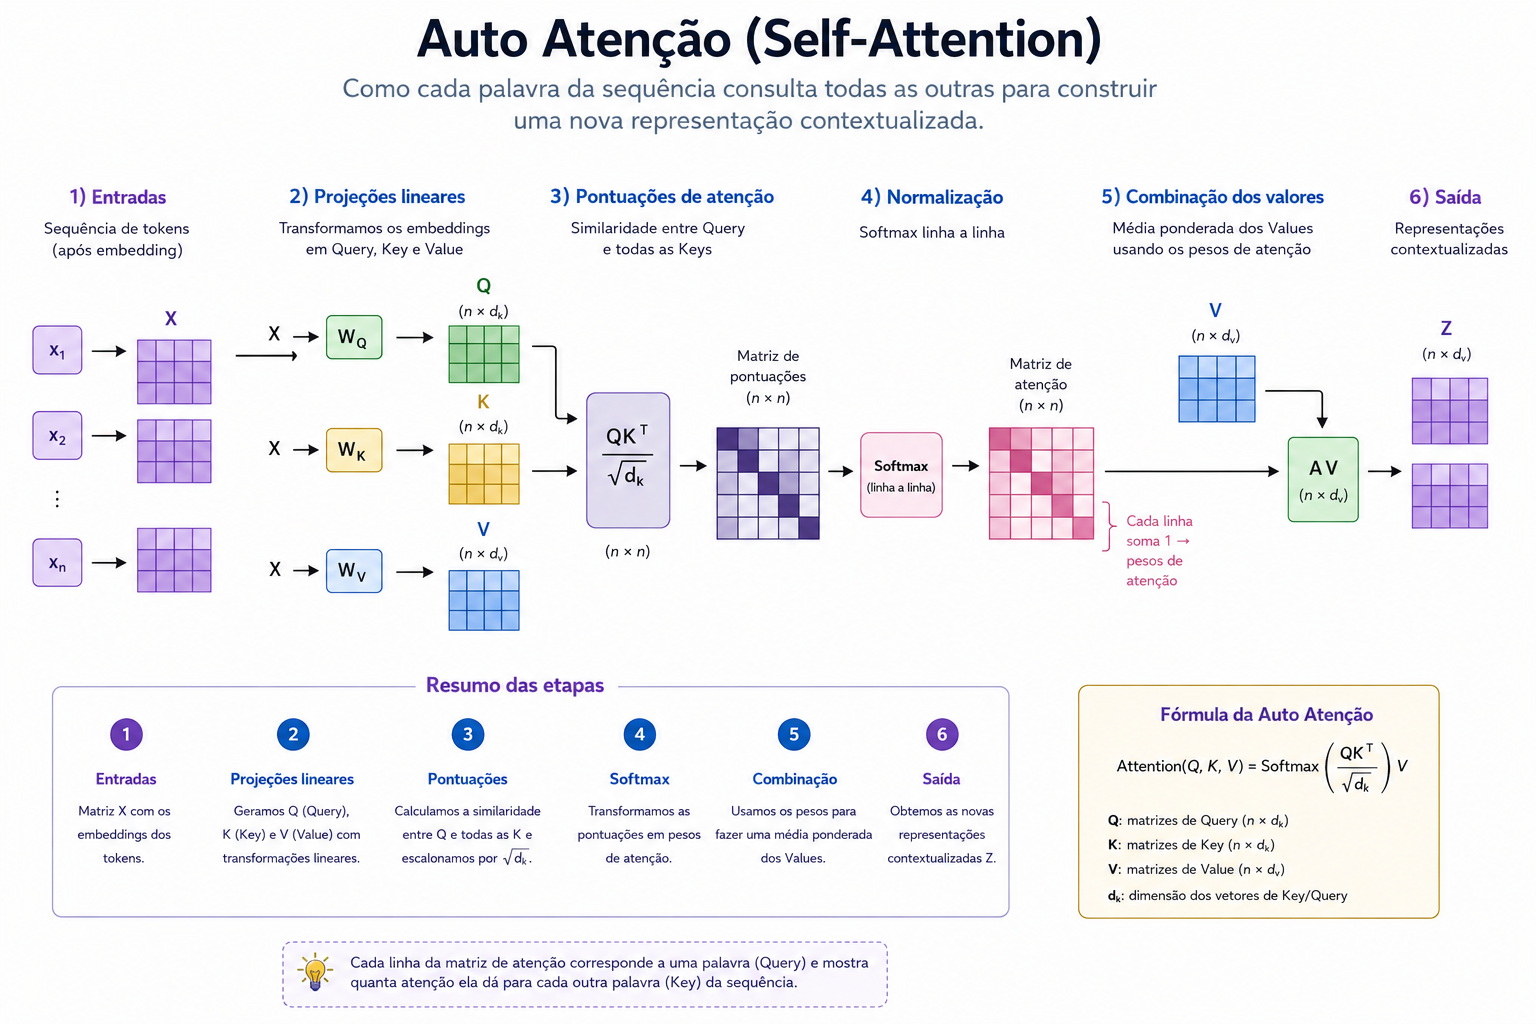

Fonte: Criado com ajuda de AI (ChatGPT).

Finalmente, podemos introduzir o conceito de *Multi-Head Attention*, no qual para N *heads* , cada uma tem suas matrizes $W_q,\;W_k\; e\;W_v$ de forma a calcular paralelamente suas submatrizes $A_1,\;A_2,\;\textellipsis$ simultaneamente, que serão concatenadas e multiplicadas com uma nova matriz de pesos treináveis $W_o$ como:

$$\text{MultiHead}\left(Q,K,V\right)=\text{Concat}\left(H_1,H_2,\textellipsis,H_N\right)\cdot W_o$$

A atenção simples aprende uma perspectiva da frase. A *Multi-Head Attention* permite que o Transformer observe várias perspectivas ao mesmo tempo e combine todas elas em uma representação mais rica.

In [ ]:
#Modelo GPT criado do zero usando apenas Python e PyTorch. 
#Fonte https://pub.towardsai.net/build-and-train-gpt-from-scratch-8ae985a8fc25

import matplotlib.pyplot as plt

import torch 
import torch.nn as nn
import torch.nn.functional as F
import math



def get_batch(split, batch_size, block_size):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    # generate a 1-dimensional tensor containing bath_size random integer numbers.
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

class SelfAttentionHead(nn.Module):
    """ one head of self-attention """

    def __init__(self, embed_dim, block_size, head_size, dropout=0.2):
        super().__init__()
        self.key = nn.Linear(embed_dim, head_size, bias=False)
        self.query = nn.Linear(embed_dim, head_size, bias=False)
        self.value = nn.Linear(embed_dim, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # input of size (batch, time-step, channels)
        # output of size (batch, time-step, head size)
        B,T,C = x.shape
        k = self.key(x)   # (B,T,hs)
        q = self.query(x) # (B,T,hs)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5 # (B, T, hs) @ (B, hs, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,hs)
        out = wei @ v # (B, T, T) @ (B, T, hs) -> (B, T, hs)
        return out
    

class MultiHeadSelfAttention(nn.Module):
    """ a stack of self-attention layers """

    def __init__(self, embed_dim, block_size, num_heads, head_size, dropout=0.2):
        super().__init__()
        self.heads = nn.ModuleList([SelfAttentionHead(embed_dim, block_size, head_size, dropout) for _ in range(num_heads)])
        self.projection = nn.Linear(num_heads*head_size, embed_dim)
        self.dropout = nn.Dropout(dropout)


    def forward(self, x):
        # input of size (batch, time-step, channels)
        # output of size (batch, time-step, channels)
        head_out = [head(x) for head in self.heads] # a list of tensors of shape (B, T, hs)
        out = torch.cat(head_out, dim=-1) # concatenate along the feature dimension
        out = self.projection(out) # project back to the original feature dimension
        out = self.dropout(out)
        return out
    
# Position embeddings
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=5000):
        super().__init__()
        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * -(math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]
    
# Feed forward network
# hidden_dim is 4 times the embedding dimension as per the paper "Attention is all you need"

class FeedForward(nn.Module):
    def __init__(self, embed_dim, hidden_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)
    
# Putting it all together in a transformer block
# The transformer block is composed of a multi-head self-attention layer, followed by a feed-forward network.


    
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, block_size, num_heads, head_size, ff_hidden_dim, dropout=0.2):
        super().__init__()
        self.attention = MultiHeadSelfAttention(embed_dim, block_size, num_heads, head_size, dropout=dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ffn = FeedForward(embed_dim, ff_hidden_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # apply the self-attention mechanism
        att = self.attention(x) # shape (B, T, C)
        # add skip connection and apply layer normalization
        x = x + self.norm1(att)  
        # apply the feed-forward network
        ffn = self.ffn(x)  # shape (B, T, C)
        # add skip connection and apply layer normalization
        x = x + self.norm2(ffn)
        return x
    
class GPTLanguageModel(nn.Module):
    def __init__(self, vocab_size,embed_dim, block_size, num_heads, head_size, ff_hidden_dim, num_layers, dropout=0.2):
        super().__init__()
        self.emd = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = PositionalEncoding(embed_dim)
        self.layers = nn.ModuleList([
            TransformerBlock(embed_dim, block_size, num_heads, head_size, ff_hidden_dim, dropout=dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        x = self.emd(x)
        x = self.pos_emb(x)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        x = self.head(x)
        return x




# read it in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# let's look at the first 1000 characters
print(text[:1000])

chars = sorted(list(set(text)))
vocab_size = len(chars)

# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# let's now encode the entire text dataset and store it into a torch.Tensor
data = torch.tensor(encode(text), dtype=torch.long)

# Let's now split up the data into train and validation sets
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# Model Initialization and Number of Parameters 

torch.manual_seed(1337)

# model hyperparameters
chars = sorted(list(set(text)))
vocab_size = len(chars)
embed_dim = 384
num_heads = 6
head_size = 64
ff_hidden_dim = 4*384
num_layers = 6
block_size = 256
dropout = 0.3

model = GPTLanguageModel(vocab_size, embed_dim, block_size, num_heads, head_size, ff_hidden_dim, num_layers, dropout=dropout)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

# Number of parameters in the model
num_params = sum(p.numel() for p in model.parameters())

print(f"Number of parameters in the model: {num_params}")

# Let's now train our transformer model
# we will use the cross-entropy loss and the Adam optimizer to train the model.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device {device}.")

# training parameters
lr = 3e-4
batch_size = 64
num_iterations = 3000
eval_iters = 200

# intiatizing loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

@torch.no_grad()
def estimate_loss(model, criterion, eval_iters, batch_size, block_size):
    model.eval()
    out = []
    losses = torch.zeros(2, eval_iters)

    @torch.no_grad()
    def evaluate(model, criterion, batch_size, block_size):
        model.eval()
        out = []
        with torch.no_grad():
            for split in ['train', 'val']:
                x, y = get_batch(split, batch_size, block_size)
                x, y = x.to(device), y.to(device)
                y_pred = model(x)
                loss = criterion(y_pred.view(-1, vocab_size), y.view(-1))
                out.append(loss.item())
        return out

    for i in range(eval_iters):
        losses[0, i], losses[1, i] = evaluate(model, criterion, batch_size, block_size)
    return losses.mean(dim=1).tolist()



# training function
def train(model, criterion, optimizer, num_iterations, batch_size, block_size):
    model.train()
    losses = []

    output_losses = []
    for i in range(num_iterations):
        x, y = get_batch('train', batch_size, block_size)
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(x)  # shape (B, T, vocab_size)
        loss = criterion(y_pred.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if i % eval_iters == 0:
            # mean training loss over the last 100 batches
            mean_train_loss = sum(losses[-eval_iters:]) / float(eval_iters)

            print(f'iteration {i}, mean training loss: {mean_train_loss:.2f}')

            train_loss, val_loss = estimate_loss(model, criterion, eval_iters, batch_size, block_size)
            output_losses.append((train_loss, val_loss))
            print(f'train loss: {train_loss:.2f}, val loss: {val_loss:.2f}')

    return output_losses

losses = train(model, criterion, optimizer, num_iterations, batch_size, block_size)    
    


train_loss, val_loss = zip(*losses)

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='train loss')
plt.plot(val_loss, label='val loss')
plt.xlabel('iterations')
plt.ylabel('loss')
plt.legend()
plt.show()


In [ ]:
# Geração de texto com o modelo treinado
@torch.no_grad()
def generate_text(model, input, max_new_tokens = 100, temperature = 1.0):
    model.eval()

    out = ''
    if isinstance(input, str):
        input = encode(input)
    input = torch.tensor(input, dtype=torch.long, device=device).unsqueeze(0)
    for _ in range(max_new_tokens):
        with torch.no_grad():
            input = input[:, -block_size:]
            y = model(input)  # shape (B, T, vocab_size)
            # take the logits at the final time-step and scale by the temperature
            y = y[0, -1, :] / temperature  # shape (vocab_size,)
            y = torch.softmax(y, dim=-1)
            next_token = torch.multinomial(y, 1)
            # if next_token == 0:
            #     break
            print(decode([next_token.item()]), end='', flush=True)
            out += decode([next_token.item()])
            input = torch.cat((input, next_token.unsqueeze(0)), dim=1)
    return out

generate_text(model, "The", max_new_tokens=1000, temperature=0.8)